## Executive Summary

In this study we have carried out an extensive data analysis of the Broker/Importer declaration amendments over the six year period 2018-2023. A small subset of categories/fields which are most frequently amended has been identified. In addition, the Brokers/Importers with highest tendencies (both by volume and rate) to make amendments to their declarations have been revealed. For the most prolific Brokers we have broken down their activity (both the total and resolved by the amendment category) into time periods with the aim of detecting unusual patterns and activity changes. Similarly, for the subset of the most commonly amended categories, we have broken down the contributions by the types of changes (i.e., the values before and after the change) and the key contributors (i.e., the Brokers which make the majority of the changes) over the time periods. A group of about half a dozen Brokers has emerged which features rather prominently in nearly all of the data insights evaluated in this analysis. 

While the results of this study reveal several distinct outliers in the activity of certain Brokers/Importers, there is no evidence so far that these have arisen due to non-compliant behaviours *per se*.
However, the *extent/volume* of the updates contributing to the amendments from a small group of large-scale Brokers did reveal a dramatic activity change via an enormous increase in the update volumes at certain time periods across a very limited subset of categories. These observations appear not only at oddds with their ordinary behaviour, but also the behavior of the majority of other Brokers/Importers. We believe that the activity of this small group merits further scrutiny through a series of targeted breakdowns of augmented (with the additional dimensions/features) data.

Finally, we have put the Brokers/Importers amendment dataset in the context of Import Industry Advice Notices by the Department. A preliminary analysis via hypothesis testing of the response to an import biosecurity policy announcement affecting a major trading partner indicates that some Brokers may have acted proactively (thus suggesting possible leaks prior to the Notice) and others reactively to this Notice in the months surrounding the announcement. For the majority of the Notices, however, due to their nature the statistical testing approach would be inappropriate because of the inadequate population sizes. The techniques of anomaly detection, via machine learning or otherwise, seem to be more suitable for the task.

## Background

Australia faces unique biosecurity challenges due to its geographical isolation and diverse ecosystems. Traditional methods of biosecurity management rely on rule-based systems and manual inspections, which may be inadequate in handling the complexity and scale of modern biosecurity challenges. Anomaly detection, including that which is powered by machine learning (ML) algorithms, has shown value in managing similar large, complex systems.

While not yet utilised in biosecurity management in Australia, anomaly detection could enhance the prevention, early detection, rapid response, and/or management of biosecurity risks.  Effective implementation requires high-quality data and close collaboration between biosecurity specialists, domain experts and data scientists to develop appropriate ML algorithms.

Anomaly detection systems could enhance the monitoring of imported goods and people entering the country, identifying potential biosecurity threats at ports and borders. Analysing transportation and trade data can help detect anomalies that may indicate attempts to circumvent biosecurity management. In this study, we focus on custom broker declarations. These declarations have been identified through a detailed intelligence assessment as an area of high non-compliant and manipulative behaviour. 
Non-compliant behaviour on the part of brokers can be classified into a number of categories, such as mis-declaring goods descriptions; mis-declaring supplier and/or importer details; inappropriately amending entries; transhipping, reexporting, and withdrawing entries; lodging multiple non-commercial consignments (i.e., each below a $1k threshold); bypassing rural tailgate inspections; avoidance of imported food inspections; fraudulent documentation etc.

Here, we focus on amendments made by brokers to entries in ICS. Brokers can make amendments as needed and the majority of these amendments are compliant with departmental requirements. Intelligence work has highlighted however that some brokers may be amending entries inappropriately in order to circumvent departmental controls. The extent and implications of this behaviour are not known. 
A preliminary work at the Department focused on identifying anomalies in the form of broker entries to country of origin of imported goods.
In this project, we build on this preliminary work, incorporating substantially more data records and more hitchhiker-targeted intervention measures. Our first step is to investigate the changes in importer/broker behaviour, namely the nature and scale, in response to new biosecurity measures over the past decade, subject to data availability. Specifically, we would consider the following new measures in-scope:

- introduction of new country risk lists for hitchhiker pests (e.g., the list of target-risk countries for host of Khapra Beetle, Biosecurity Determination, 2021)
- addition of new countries to existing country risk lists for hitchhiker pests (e.g., PRC was added to the Brown Marmorated Stink Bug to the Emerging Risk Country List in Feb 2022)
. 

The project aims to address the following questions: 
- Are there anomalies in broker amendments to country of origin associated with the announcement of a regulatory change?
- If so: what is the scale of the anomalous behaviour?  (i.e., what proportion of import records are altered over and above the usual background rate of change); 
- Is there evidence of patterns or drivers in the import records being changed in this situation? 
- Are certain brokers responsible?
- Are there patterns relating to particular countries of origin (changes to or from)?
- Do particular goods/commodities stand out for which anomalous amendments are being made? 
- What is the impact of the anomalous behaviour in terms of biosecurity threat?
- How many pest entries are likely to result from the anomalous behaviour, relative to the typical non-anomalous behaviour? 
- How many of these entries are likely to be hitchhiker pests?
- Are there additional anomalies that can be identified using a top-down exploratory approach of all amendments? (not necessarily relating to country of origin changes or specific biosecurity measure changes)

The aim of this preliminary/exploratory study is to identify the patterns of unusual behaviours Brokers/Importers may exhibit, which in part may arise due to attempt to circumvent the Department controls.

## Raw data 01/01/2018-31/12/2023
### (from a SQL query combining the AIMS.Entry, AIMS.Amendment and AIMS.RefClient tables from the T2_BIOSECURITY database)

The data has been exported as CSV file named Broker_and_amendments.csv (and gzip-compressed).
We read it into a pandas dataframe and take a small random sample of rows to inpsect:

In [3]:
df_ba = pd.read_csv("C:/Users/AB0175/OneDrive - Agriculture/PYTHON/DAFF/X_BRANO/Broker_and_amendments.csv.gz",
                    parse_dates=['Entry_Creation_date', 'Amendment_date', 'Amendment_message_date', 'Delete_date', 'Insert_date', 'Update_date', 'AIMS_Update_date'],
                    low_memory=False)

df_ba.sample(5)

,Entry_ID,Broker,Entry_Creation_date,Amendment_date,Amendment_message_date,Amended_field,Summary_amended_field,Before_amendment,After_amendment,Delete_date,Insert_date,Update_date,AIMS_Update_date
6741844,AEMGMKJAG,ROHLIG AUSTRALIA PTY LTD,2021-08-27 12:34:00,2021-08-27 12:37:00,2021-08-27 12:36:38,Insert LineAep.LocationCode,Insert LineAep.LocationCode,NaN,NaN,9999-12-31 23:59:59.9999999,2021-08-27 17:32:38.077678800,2021-08-27 17:32:38.077678800,2021-08-27 12:37:00
3715171,AEE94LNL7,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,2020-01-07 11:58:00,2020-04-28 08:51:00,2020-04-28 08:50:13,Delete LineQuantity.QuantityCode,Delete LineQuantity.QuantityCode,NO,NaN,9999-12-31 23:59:59.9999999,2021-05-13 17:31:38.494033600,2021-05-13 17:31:38.494033600,2020-04-28 08:51:00
4319878,AEHNN7J9E,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,2020-09-15 17:05:00,2020-09-15 17:31:00,2020-09-15 17:30:20,Delete LineProfile.Answer,Delete LineProfile.Answer,NaN,NaN,9999-12-31 23:59:59.9999999,2021-05-13 17:31:38.494033600,2021-05-13 17:31:38.494033600,2020-09-15 17:31:00
11923826,AE3T46FHE,COVENTRY CLEARANCES PTY. LTD.,2023-10-26 12:38:00,2023-10-27 12:23:00,2023-10-27 12:22:30,Insert LineCountry.CountryCode,Insert LineCountry.CountryCode,NaN,TH,9999-12-31 23:59:59.9999999,2023-10-27 14:28:13.704737500,2023-10-27 14:28:13.704737500,2023-10-27 12:23:00
14262925,AEHXMHT7C,SCHENKER AUSTRALIA PTY LTD,2020-10-07 11:55:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT


From here on we continue with the dataset by removing the replicated 7.1 million rows, which leaves us with 8.6 million unique records.

In [5]:
df_ba.drop(df_ba.index[df_ba.duplicated()], axis=0, inplace=True)
df_ba.shape[0]

8624002

Evident from the "count" row above, there are 8.6 million records, but only 5.2 million of those have amendments.

Note also that there the count of unique datetimes is a lot lower, only 1.2 million for the "Entry_Creation_date", and for the amended rows it is well below 1 million .

We note that the "Insert_date" and "Update_date" columns display identical summary values.
Oddly, both show only 968 unique datetimes, the most frequent of which was the the very first value 2021-05-13 17:31:38. 
The suspiciously low count of their unique values, as well as the fact that the first values (mid May 2021) is 3.6 years behind the date range start,
strongly suggests the both of their values have probably been system generated values over a relatively small number of cycles,
rather than reflecting the actual datetimes when the amendments took place.

The statistics of the datetime features as numeric values:

The number of distinct Brokers/Importers (17k) seems large, but it turns out less than 800 of these made any amendments over the 6 year range period: 

In [6]:
df_ba.loc[df_ba['Amendment_date'].notna(), 'Broker'].nunique()

799

Here is the list of all values/categories of the "Summary amended field", together with their frequencies (in the descending order over the latter, on a logarithmic scale, due to the frequency disparity):

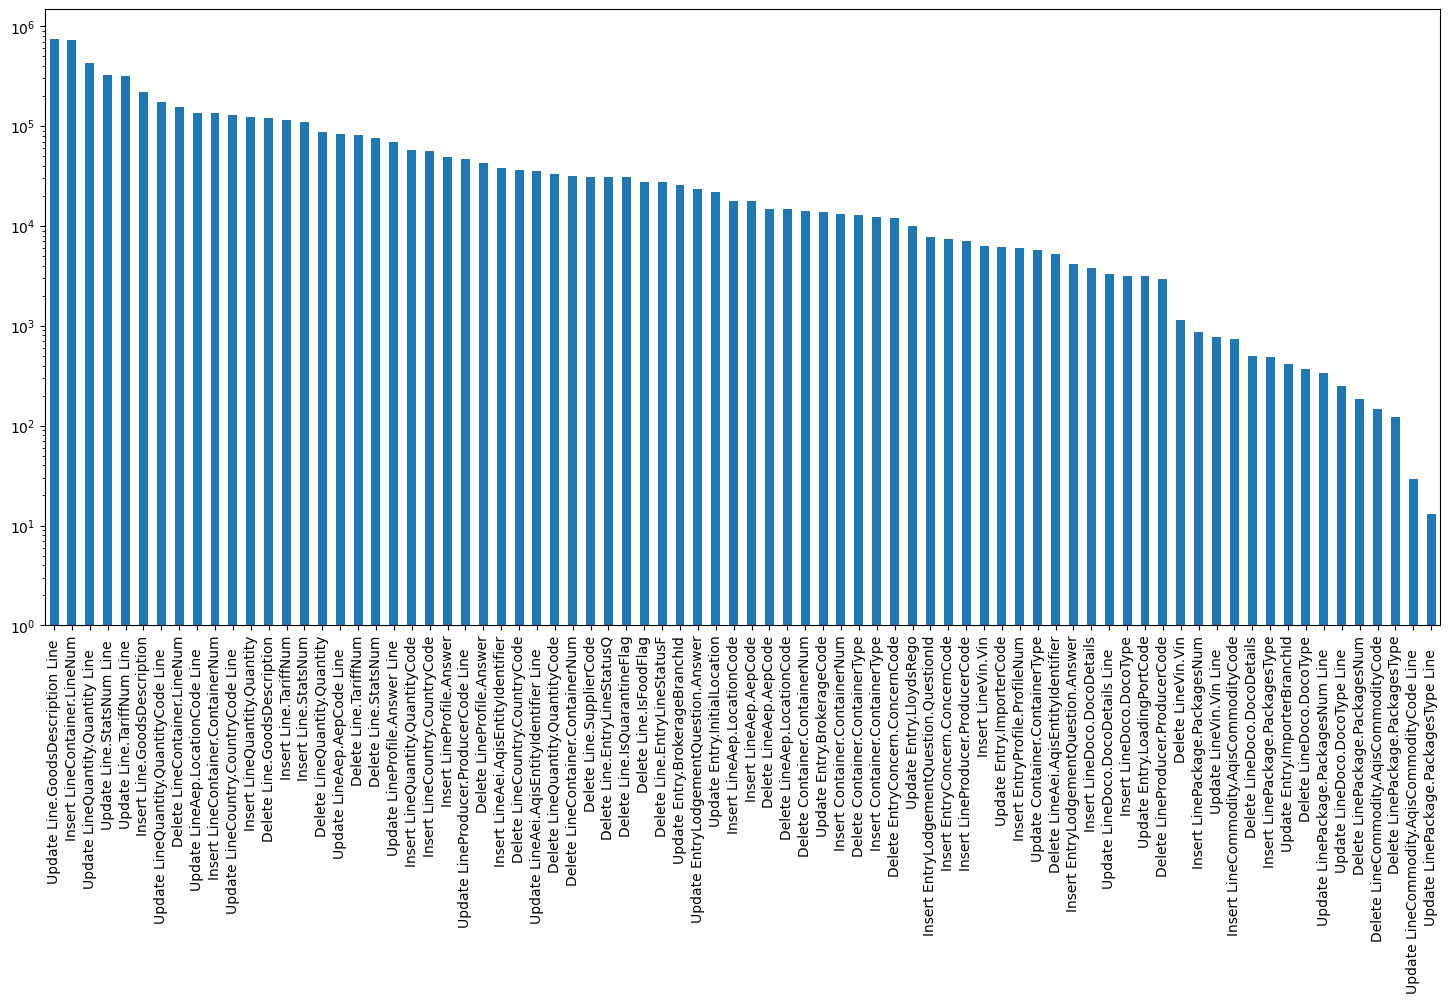

In [7]:
plt.figure(figsize=(18, 8))
df_ba['Summary_amended_field'].value_counts().plot(kind="bar", log=True)
plt.xticks(rotation = 90);

The first word in each of the 78 categories is either "Update", "Insert", or "Delete". It makes sense to ignore it and work with only about half (i.e., 37) of the distinct categories:

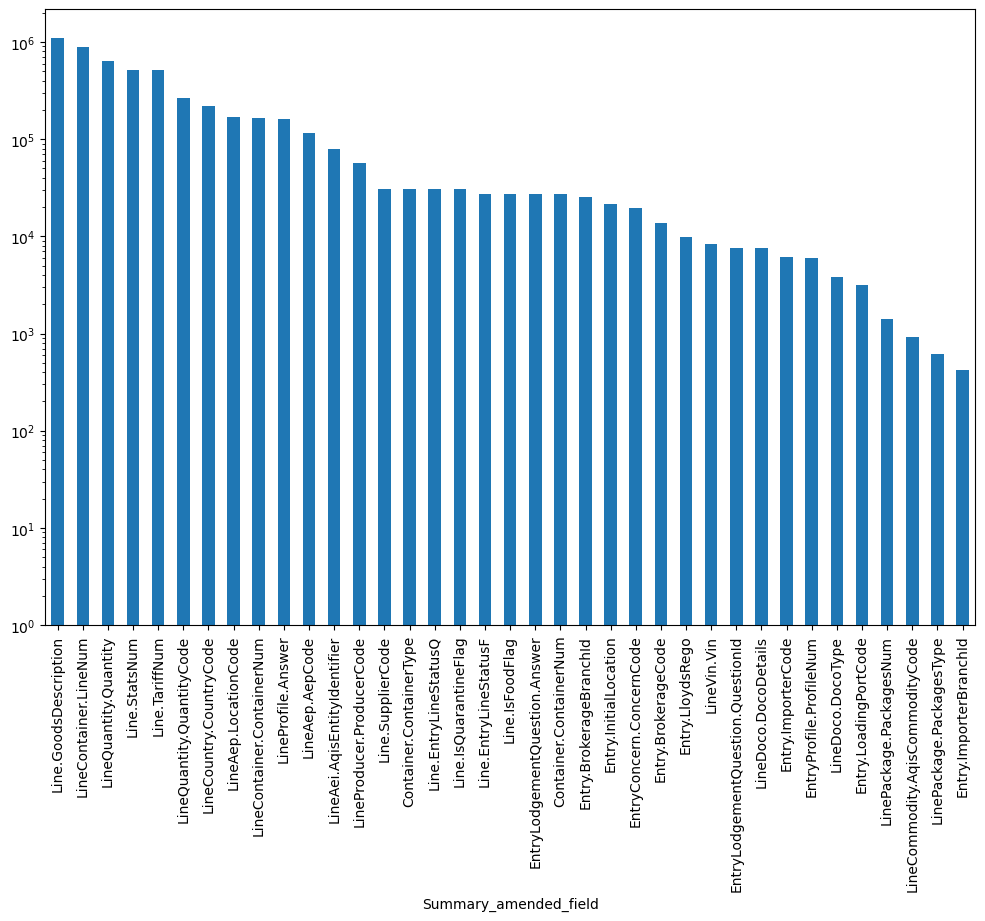

In [8]:
plt.figure(figsize=(12, 8))
df_ba.groupby([df_ba['Summary_amended_field'].str.split().apply(lambda x: x[1] if isinstance(x, list) else x)], dropna=True)['Summary_amended_field'].count().sort_values(ascending=False).plot(kind="bar", log=True)
plt.xticks(rotation = 90);

## Relations (and correlations) between the features

Here we investigate the relatioships beween the features in the dataset.

We start with the "Broker" and the their amendmend vs total (amended and unamended) records over time.
After this part is complete we can dispense with the unamended records.

### Broker amend activity

The following cell shows the list of amendment making Brokers/Importers and counts of their unamended Entries (*"Unamended_count"*), the number of distinct amended Entries (*"Distinct_EntryID_amends"*), and the total number of updates of their Entries (*"Total_updates"*).
In addition, the ratio of amended-vs-unamended Entries (*"amend_ratio"*) and the average number of updares per Entry (*"Avg_updates_per_EntryID"*) are provided:

In [9]:
amd_brokers = df_ba.loc[df_ba['Amendment_date'].notna(), 'Broker'].unique().tolist()

df_BrAmYN = df_ba.query("Broker in @amd_brokers").groupby(['Broker', df_ba['Amendment_date'].notna()])\
            .agg({'Entry_ID': [lambda x: x.nunique(), lambda x: x.count()]}).unstack().fillna(0).astype("int")

df_BrAmYN.columns = ['Unamended_count', 'Distinct_EntryID_amends', 'Unamended_count_2', 'Total_updates']
df_BrAmYN.drop(columns='Unamended_count_2', inplace=True)
df_BrAmYN = df_BrAmYN.assign(amend_ratio = round(df_BrAmYN['Distinct_EntryID_amends'] / df_BrAmYN['Unamended_count'], 2))
df_BrAmYN = df_BrAmYN.assign(Avg_updates_per_EntryID = round(df_BrAmYN['Total_updates'] / df_BrAmYN['Distinct_EntryID_amends'], 1))
df_BrAmYN.replace([np.inf, -np.inf], np.nan, inplace=True)

df_BrAmYN.sort_values(by=['amend_ratio', 'Avg_updates_per_EntryID'], ascending=[False, False])

,Unamended_count,Distinct_EntryID_amends,Total_updates,amend_ratio,Avg_updates_per_EntryID
Broker,,,,,
FINDEX (AUST) PTY LTD,28,657,10160,23.46,15.5
DEPARTMENT OF HOME AFFAIRS,6,32,145,5.33,4.5
AMPOL AUSTRALIA PETROLEUM PTY LTD,1,3,4,3.00,1.3
WORLD CUSTOMS CONSULTANTS PTY LTD,33,94,761,2.85,8.1
BLUE WATER SHIPPING PTY LTD,499,1110,6123,2.22,5.5
...,...,...,...,...,...
R.D LAMBORN & L LIU,0,1,1,NaN,1.0
RAPID CLAMPS PTY LTD,0,1,1,NaN,1.0
SHAYLA WAYAN RAMSAY,0,1,1,NaN,1.0


The total counts (i.e.,by volume) may not necessarily be the indicators of Brokers' amendment propensity.
Perhaps the fractions of the amended records relative to all records could be better indicators.
We engineer two new features in this table *"pct_amended_dist"* and *"pct_updated_tot"* which show the percentage of distincts Entries amended and the total percentage of all Entry updates.

In [10]:
df_BrAmYN = df_BrAmYN.assign(pct_amended_dist=np.round(df_BrAmYN['Distinct_EntryID_amends'] / (df_BrAmYN['Unamended_count'] + df_BrAmYN['Distinct_EntryID_amends']) * 100.0, 1))
df_BrAmYN = df_BrAmYN.assign(pct_updated_tot=np.round(df_BrAmYN['Total_updates'] / (df_BrAmYN['Unamended_count'] + df_BrAmYN['Total_updates']) * 100.0, 1))
df_BrAmYN.sort_values(by=['Distinct_EntryID_amends', 'pct_amended_dist'], axis=0, ascending=[False, False], inplace=True)
df_BrAmYN

,Unamended_count,Distinct_EntryID_amends,Total_updates,amend_ratio,Avg_updates_per_EntryID,pct_amended_dist,pct_updated_tot
Broker,,,,,,,
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,155544,13588,739161,0.09,54.4,8.0,82.6
GEODIS AUSTRALIA PTY LTD,124601,11692,710137,0.09,60.7,8.6,85.1
KUEHNE & NAGEL PTY LTD,82190,8477,421555,0.10,49.7,9.3,83.7
MAINFREIGHT AIR & OCEAN PTY LTD,115774,7049,72778,0.06,10.3,5.7,38.6
C.H. ROBINSON WORLDWIDE (AU) PTY LTD,97965,6666,83302,0.07,12.5,6.4,46.0
...,...,...,...,...,...,...,...
GLOBAL CONSOLIDATION SERVICES PTY LTD,574,1,1,0.00,1.0,0.2,0.2
CMA CGM GROUP AGENCIES (AUSTRALIA) PTY LTD,740,1,1,0.00,1.0,0.1,0.1
GLOBELINK INTERNATIONAL PTY. LIMITED,775,1,1,0.00,1.0,0.1,0.1


The Brokers/Importers with a high amendment propensity can be identified with bright coloured markers in the left panel plot below, mainly in the lower part of it, i.e., with lower *"Unamended_count"* values, and towards
the right hand size, i.e., with higher *"Distinct_EntryID_amends"*.

The plot in thr right panel, similarly, identifies with bright coloured markers the Brokers/Importers with a high extent of amendments, i.e., with large *"Total_updates"* values

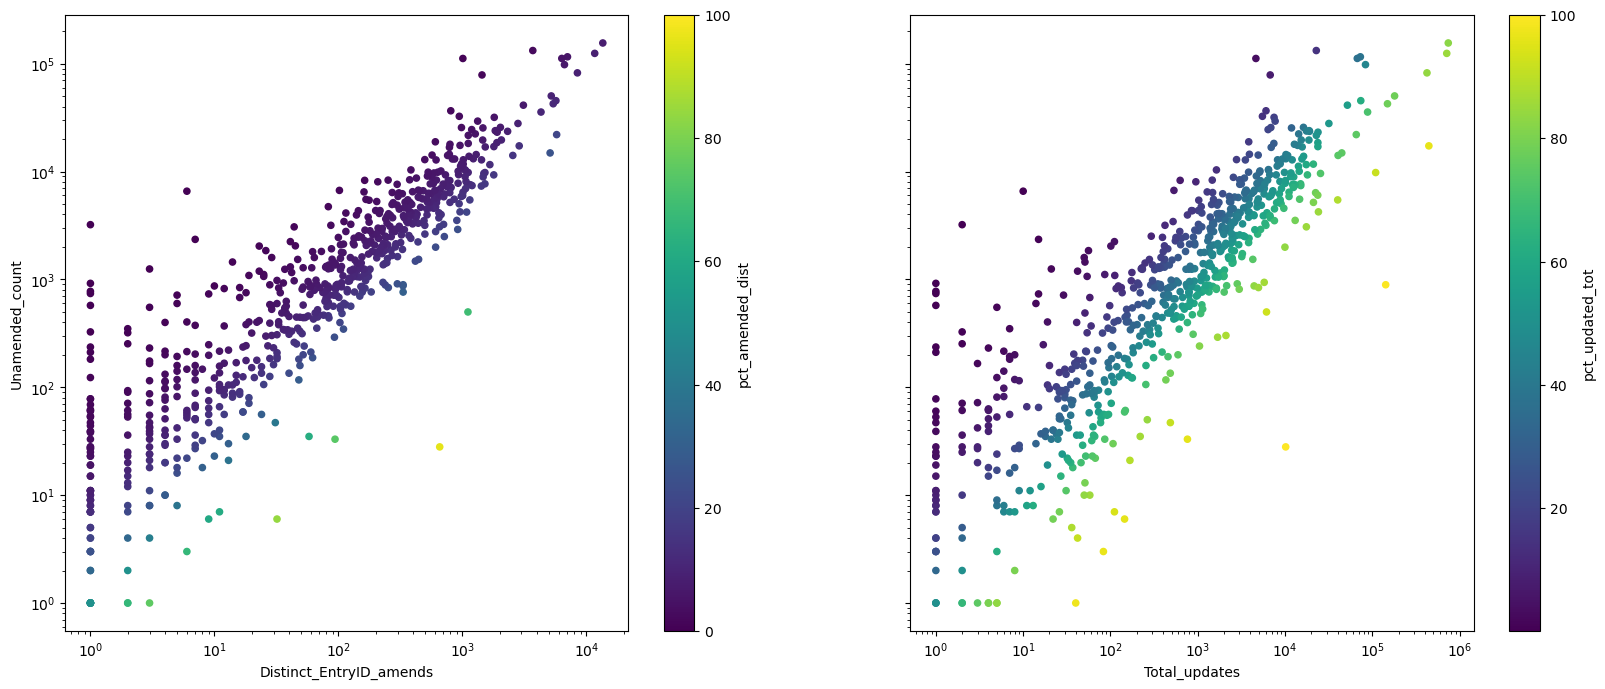

In [11]:
_, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(20, 8))
axes[0].set_yscale('log')
axes[0].set_xscale('log')
df_BrAmYN.plot(x='Distinct_EntryID_amends', y='Unamended_count', kind="scatter", ax=axes[0], c='pct_amended_dist')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
df_BrAmYN.plot(x='Total_updates', y='Unamended_count', kind="scatter", ax=axes[1], c='pct_updated_tot');

An alternative view is shown below: the Brokers/Importers with high amendment rates are represented by the markers on the right hand side in the plots below.
The darker the shades of the marker - the bigger the volume of Broker amends.

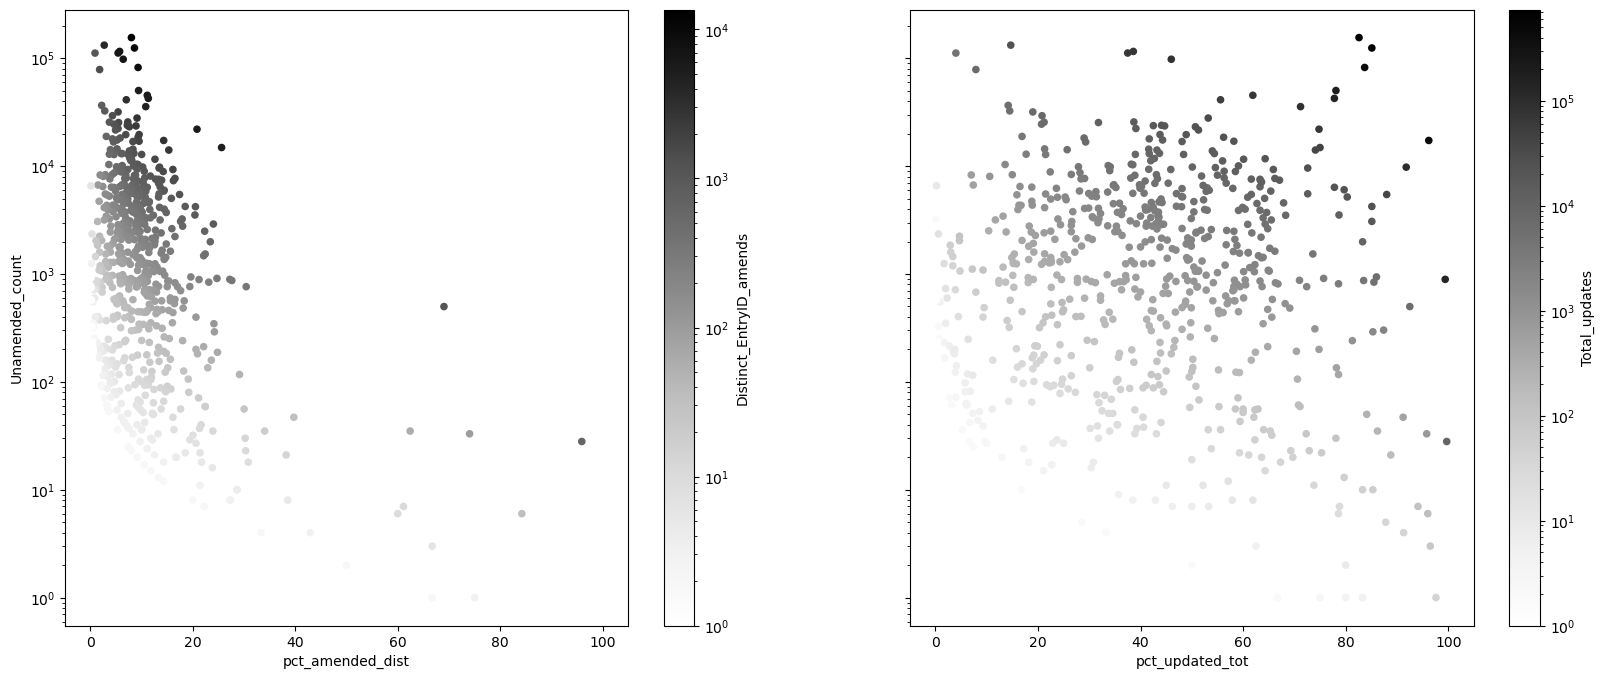

In [12]:
import matplotlib
# needed for logarithmic scale color via LogNorm()

_, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(20, 8))
df_BrAmYN.plot(x='pct_amended_dist', y='Unamended_count', kind="scatter", ax=axes[0], c='Distinct_EntryID_amends', norm=matplotlib.colors.LogNorm())
axes[0].set_yscale('log')
df_BrAmYN.plot(x='pct_updated_tot', y='Unamended_count', kind="scatter", ax=axes[1], c='Total_updates', norm=matplotlib.colors.LogNorm());
axes[1].set_yscale('log')

Now we add a new column *"Amended_EntryID_count"* which is equal to *"Distinct_EntryID_amends"* values for the Broker amended records and to *"Unamended_count"* values for the Broker unamended records:

In [13]:
df_ba['Amended_EntryID_count'] = df_ba.groupby(['Broker', df_ba['Amendment_date'].notna()])['Entry_ID'].transform("nunique")

Now that we have exploited the ~3 million of unamended records to engineer the new feature *"Amendmed_EntryID_count"*, we can drop these records from further consideration (and the dataframe), which
leaves us with +5M rows:

In [14]:
df_ba.dropna(subset=['Amendment_date', 'Amendment_message_date', 'Insert_date', 'Update_date', 'Amended_field', 'Summary_amended_field', 'Before_amendment', 'After_amendment'], how="all", inplace=True)
df_ba.shape[0]

5235442

Next we look at the number of amendments for each Entry_ID, which gives us a new feature termed *"EntryID_amendment_count"*:

In [15]:
df_ba['EntryID_amendment_count'] = df_ba.groupby('Entry_ID')['Amendment_date'].transform("nunique")

The values of *"EntryID_amendment_count"* are in the 1-14 range. The vast majority of Entries had only a single or two amendments.

The table below shows "*EntryID_amendment_count"* values and their frequencies:

In [16]:
df_ba['EntryID_amendment_count'].value_counts().to_frame()

,EntryID_amendment_count
1,3530104
2,1018734
3,353796
4,146486
5,93970
6,28190
7,25752
9,17657
8,14403
11,5569


There happens to be a sngle Entry_ID (AEFWME97G) which was amended at 14 different occassions (i.e, datetimes).

In fact, almost all of the EntryIDs that were amended 10+ times belong to the same Broker **"ROHLIG AUSTRALIA PTY LTD"**, namely:

- AEFWME97G with 14 amendments comprising 202 updates/insertions/deletions
- AC7GXLTM6 with 12 amendments comprising 208 updates/insertions/deletions
- AEKLCGKHX with 11 amendments comprising 282 updates/insertions/deletions
- AC7NAKHJM with 11 amendments comprising 244 updates/insertions/deletions
- AC79CLAGF with 10 amendments comprising 200 updates/insertions/deletions
- AEF7LHX49 with 10 amendments comprising 171 updates/insertions/deletions

Below is the list of the Entries and their Brokers which have the *"EntryID_amendment_count"* value of 8 and above:

In [17]:
for eac in df_ba['EntryID_amendment_count'].value_counts().tail().index:
    print(f"\nEntryID_amendment_count: {eac}")
    display(df_ba.loc[df_ba['EntryID_amendment_count'] == eac, ['Entry_ID', 'Broker']].value_counts().to_frame().rename(columns={0: 'EntryID_update_count'}))


EntryID_amendment_count: 8


,,EntryID_update_count
Entry_ID,Broker,
AEJ9LE3LN,KUEHNE & NAGEL PTY LTD,1880
AEF3LNMEC,ROHLIG AUSTRALIA PTY LTD,1787
AC4CYA7E3,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,1724
AEEKGMKAW,KUEHNE & NAGEL PTY LTD,1265
AEJ76YC46,KUEHNE & NAGEL PTY LTD,721
AC44X4PRR,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,702
AC4N4E4H7,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,645
AC4WFN7YL,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,607
AEYXE74M7,DSV AIR & SEA PTY LTD,554



EntryID_amendment_count: 11


,,EntryID_update_count
Entry_ID,Broker,
AEHHAL69A,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,2556
AEEKAP3YR,KUEHNE & NAGEL PTY LTD,1503
AC4MNRY6L,PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,984
AEKLCGKHX,ROHLIG AUSTRALIA PTY LTD,282
AC7NAKHJM,ROHLIG AUSTRALIA PTY LTD,244



EntryID_amendment_count: 10


,,EntryID_update_count
Entry_ID,Broker,
AC79CLAGF,ROHLIG AUSTRALIA PTY LTD,200
AEF7LHX49,ROHLIG AUSTRALIA PTY LTD,171



EntryID_amendment_count: 12


,,EntryID_update_count
Entry_ID,Broker,
AC7GXLTM6,ROHLIG AUSTRALIA PTY LTD,208



EntryID_amendment_count: 14


,,EntryID_update_count
Entry_ID,Broker,
AEFWME97G,ROHLIG AUSTRALIA PTY LTD,202


The six frequently amended Rohlig's Entries had a dozen of their fields updated, but most frequently it was the LineQuantity.Quantity followed by Line.GoodsDescription:

In [18]:
rohligs_six = ["AEFWME97G", "AC7GXLTM6", "AEKLCGKHX", "AC7NAKHJM", "AC79CLAGF", "AEF7LHX49"]

df_ba.query('Entry_ID in @rohligs_six')['Summary_amended_field'].str.split().apply(lambda x: x[1]).value_counts().to_frame()

,Summary_amended_field
LineQuantity.Quantity,373
Line.GoodsDescription,283
Line.StatsNum,163
Line.TariffNum,163
LineCountry.CountryCode,138
LineQuantity.QuantityCode,111
Line.EntryLineStatusQ,15
Line.IsQuarantineFlag,15
Line.EntryLineStatusF,13
Line.IsFoodFlag,13


For the sake of convenience, we can introduced a new feature *"Reduced_amended_field"* to include only the important (reduced) part of the amended field, which can be from one of the 37 categories:

In [19]:
df_ba['Reduced_amended_field'] = df_ba.groupby('Entry_ID')['Summary_amended_field'].transform(lambda x: x.str.split()).apply(lambda x: x[1])
df_ba[['Reduced_amended_field']].describe()

,Reduced_amended_field
count,5235442
unique,37
top,Line.GoodsDescription
freq,1087948


### Broker vs Amended field

We continue the analysis by looking at the relationship of the *"Broker"* column and associated most frequent *"Reduced_amended_field"* values.

It may be more clear to present the data as a 799x37 contigency table between the two features, where the *"Broker"* values are the rows and reduced *"Reduced_amended_field"* values are the columns.

In [20]:
df_BrRaf = df_ba.drop_duplicates(['Entry_ID', 'Amendment_date', 'Summary_amended_field']).groupby(['Broker', 'Reduced_amended_field'])['Amendment_date'].count().unstack().fillna(0)

For clarity we restrict the data to the most prolific group (amendment-wise) of 31 Brokers/Importers:

In [21]:
top_field_amenders = df_BrRaf[df_BrRaf.sum(axis=1) > 7_500]
top_field_amenders

Reduced_amended_field,Container.ContainerNum,Container.ContainerType,Entry.BrokerageBranchId,Entry.BrokerageCode,Entry.ImporterBranchId,Entry.ImporterCode,Entry.InitialLocation,Entry.LloydsRego,Entry.LoadingPortCode,EntryConcern.ConcernCode,...,LineCountry.CountryCode,LineDoco.DocoDetails,LineDoco.DocoType,LinePackage.PackagesNum,LinePackage.PackagesType,LineProducer.ProducerCode,LineProfile.Answer,LineQuantity.Quantity,LineQuantity.QuantityCode,LineVin.Vin
Broker,,,,,,,,,,,,,,,,,,,,,
3D LOGISTICS PTY LTD,178.0,225.0,105.0,13.0,0.0,38.0,206.0,40.0,28.0,176.0,...,373.0,25.0,23.0,0.0,0.0,40.0,560.0,447.0,375.0,86.0
A. HARTRODT AUSTRALIA PTY LTD,82.0,115.0,39.0,0.0,0.0,16.0,196.0,45.0,20.0,165.0,...,527.0,5.0,4.0,0.0,0.0,82.0,781.0,755.0,537.0,9.0
A.C.N. 004 265 721 PTY LTD,255.0,303.0,88.0,74.0,0.0,41.0,273.0,66.0,11.0,231.0,...,465.0,29.0,24.0,0.0,0.0,22.0,496.0,555.0,450.0,5.0
BR INTERNATIONAL LOGISTICS PTY LTD,128.0,161.0,71.0,5.0,1.0,20.0,111.0,31.0,4.0,111.0,...,422.0,13.0,11.0,0.0,0.0,69.0,752.0,712.0,431.0,0.0
C.H. ROBINSON WORLDWIDE (AU) PTY LTD,796.0,854.0,605.0,82.0,0.0,79.0,651.0,159.0,38.0,502.0,...,1796.0,71.0,60.0,1.0,1.0,167.0,1395.0,2499.0,1508.0,35.0
CLEMENGER INTERNATIONAL FREIGHT PTY. LTD.,106.0,137.0,47.0,47.0,0.0,19.0,174.0,64.0,16.0,175.0,...,430.0,44.0,38.0,0.0,0.0,124.0,576.0,661.0,400.0,0.0
COMPLIANT CUSTOMS PTY LIMITED,297.0,360.0,3133.0,3129.0,1.0,74.0,292.0,129.0,10.0,244.0,...,1552.0,36.0,30.0,5.0,5.0,196.0,1415.0,2541.0,1775.0,22.0
COVENTRY CLEARANCES PTY. LTD.,77.0,82.0,47.0,47.0,0.0,7.0,46.0,43.0,15.0,46.0,...,931.0,0.0,0.0,0.0,0.0,3.0,585.0,1223.0,810.0,66.0
DHL EXPRESS (AUSTRALIA) PTY LTD,0.0,0.0,0.0,0.0,0.0,163.0,3.0,0.0,18.0,34.0,...,415.0,40.0,35.0,0.0,0.0,134.0,3408.0,646.0,462.0,0.0


The bar chart below shows the distinct field contributions to amendments for the group of 31 Broker:

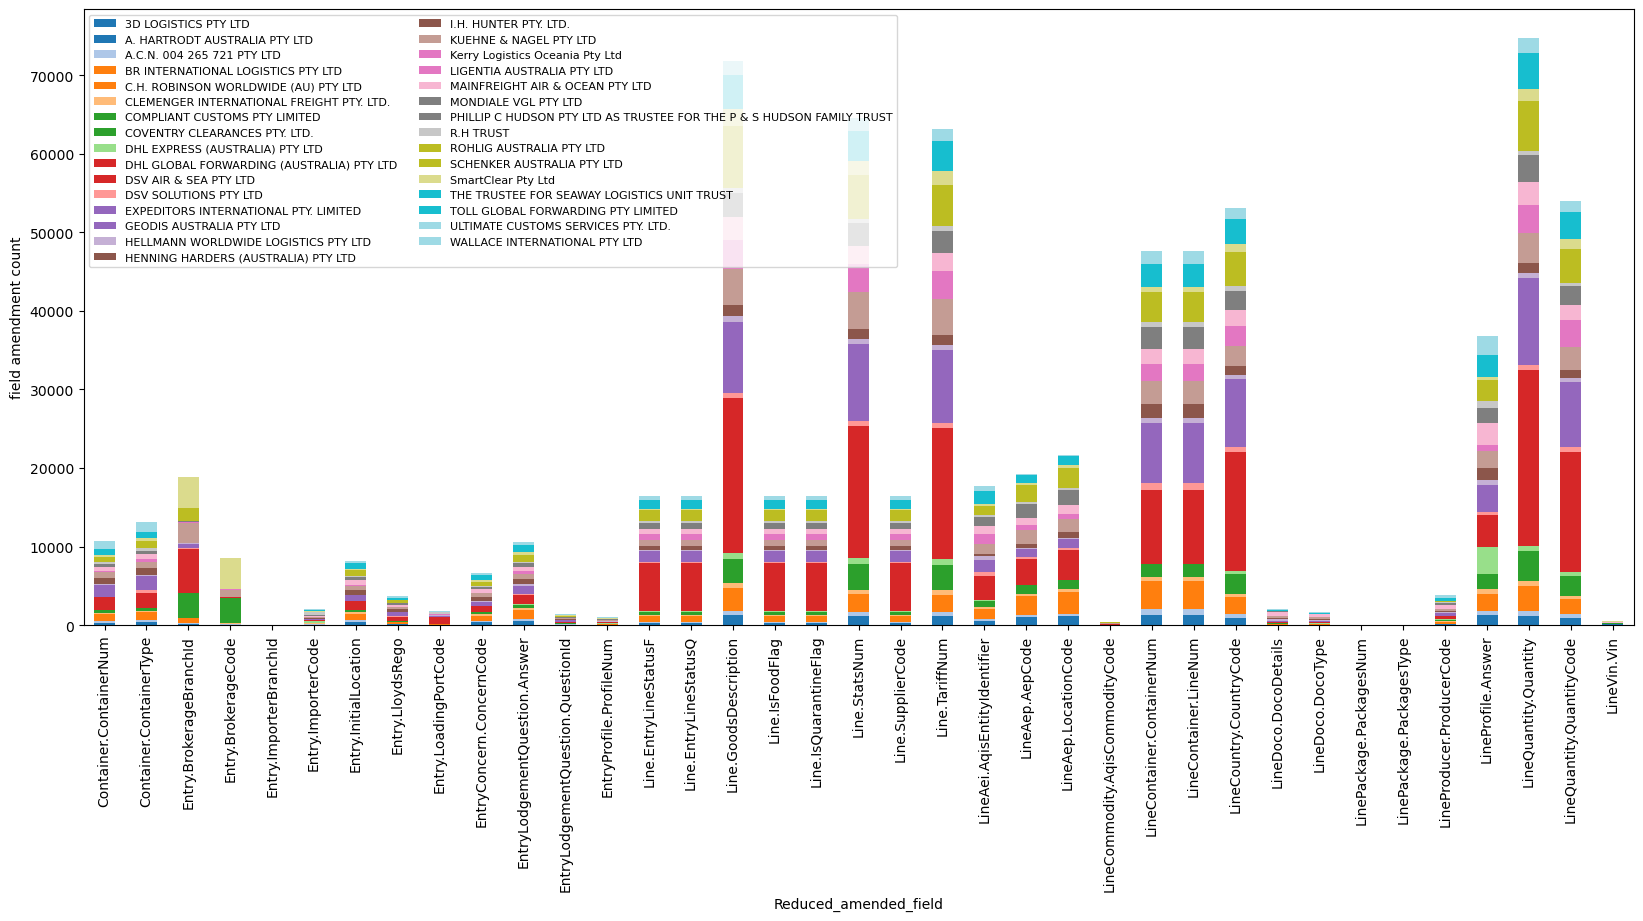

In [22]:
top_field_amenders.T.plot(kind="bar", stacked=True, figsize=(20, 8), colormap="tab20")
plt.ylabel("field amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=8, ncol=2);

Another criterion for selecting amendment-prolific Brokers is by looking at those who have amended a large volume of Entries. It produces another group of 30 Brokers:

In [23]:
top_EntryID_amenders = df_ba.query("Amended_EntryID_count > 1_530")['Broker'].unique().tolist()
len(top_EntryID_amenders)

30

Now we make a union of the two groups, with a total of 34 Brokers:

In [24]:
top_brokers = set(top_EntryID_amenders).union(set(top_field_amenders.index))
len(top_brokers)

34

The top 34 comprise only 4.2% of the 799 Brokers in the dataset, but they capture 73% of all records (i.e., updates):

In [25]:
round(df_ba.query("Broker in @top_brokers").shape[0] / df_ba.shape[0] * 100, 1)

73.0

For the majority of the top 34 the EntryID amendment rate has been in the 2.72-27.2% range. The only notable exception is __"PWC COMPLIANCE AUSTRALIA"__ with 100% amendment rate of their EntryIDs.

Also noteworthy is that __"PHILLIP C HUDSON PTY LTD"__, __"Kerry Logistics Oceania Pty Ltd"__, __"COVENTRY CLEARANCES PTY. LTD.__", __"KUEHNE & NAGEL PTY LTD"__, __"GEODIS AUSTRALIA PTY LTD"__,
and __"DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD"__
seemigly make very extensive amendments, manifested by the vary large *"Avg_updates_per_EntryID"* values (i.e., the average number of updates per amended Entry_ID) in the range 50-426:

In [26]:
df_BrAmYN.loc[df_BrAmYN.index.isin(top_brokers), ['pct_amended_dist', 'pct_updated_tot', 'amend_ratio', 'Avg_updates_per_EntryID']].sort_values(by='pct_amended_dist', ascending=False)

,pct_amended_dist,pct_updated_tot,amend_ratio,Avg_updates_per_EntryID
Broker,,,,
PWC COMPLIANCE SERVICES AUSTRALIA PTY LTD,100.0,100.0,NaN,3.5
PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST,27.2,99.4,0.37,426.3
SmartClear Pty Ltd,25.6,75.0,0.34,8.7
COMPLIANT CUSTOMS PTY LIMITED,20.8,74.8,0.26,11.3
LIGENTIA AUSTRALIA PTY LTD,17.4,88.0,0.21,34.8
ULTIMATE CUSTOMS SERVICES PTY. LTD.,16.1,65.9,0.19,10.0
I.H. HUNTER PTY. LTD.,15.3,74.1,0.18,15.8
Kerry Logistics Oceania Pty Ltd,14.3,96.2,0.17,154.1
COVENTRY CLEARANCES PTY. LTD.,13.5,91.8,0.16,71.6


It is interesting to observe the top Broker by their *percentage* contribution to each of the dozen most amended fields as the percentage of their total amendment activity.
This information is relevant because it reveals how "concentrated" (on certain fields) their activity is.

__"PHILLIP C HUDSON PTY LTD"__ features prominent as the highest-percentage-amender in almost half of those:

- LineProfile.Answer: DHL EXPRESS (AUSTRALIA) PTY LTD, 39.35%
- Entry.BrokerageBranchId:  PWC COMPLIANCE SERVICES AUSTRALIA PTY LTD, 37.55%
- Line.GoodsDescription, SCHENKER AUSTRALIA PTY LTD 14.54%
- LineQuantity.Quantity: PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST, 14.4%
- Line.StatsNum: PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST, 12.05%
- Line.TariffNum: PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST, 11.96%
- LineContainer.LineNum: INDEPENDENT CUSTOMS SERVICES AUSTRALIA PTY LTD, 11.97%
- LineQuantity.QuantityCode: PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST, 11.17%
- LineCountry.CountryCode: PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST, 10.96%
- LineAei.AqisEntityIdentifier: WOOLWORTHS GROUP LIMITED, 7.8%
- LineAep.AepCode: 3D LOGISTICS PTY LTD, 6.84%
- EntryConcern.ConcernCode: HENNING HARDERS (AUSTRALIA) PTY LTD, 3.6%

From the bar chart above it is evident that the most remarkable amendment activity takes place across the following seven (out of 37) categories:
Line.GoodsDescription, LineContainer.LineNum, LineQuantity.Quantity, Line.StatsNum, Line.TariffNum, LineQuantity.QuantityCode and LineCountry.CountryCode.
The Line.StatsNum and Line.TariffNum appear almost as mirror images of each other, though.

The top dozen categories/fields of interest:

In [27]:
top_katz = ('Line.GoodsDescription',
            'LineContainer.LineNum',
            'LineQuantity.Quantity',
            'LineQuantity.QuantityCode',
            'Line.StatsNum',
            'Line.TariffNum',
            'LineCountry.CountryCode',
            'LineAei.AqisEntityIdentifier',
            'LineAep.AepCode',
            'EntryConcern.ConcernCode',
            'LineProfile.Answer',
            'Entry.BrokerageBranchId')

Now we can extract the top 5 amendment making Brokers/Importers for each of the categories.
__"DHL GLOBAL FORWARDING"__, __"GEODIS AUSTRALIA"__, __"KUEHNE & NAGEL"__ and __"DSV AIR & SEA"__ feature prominent across the majority of the columns below:

In [28]:
suff = {0: "st", 1: "nd", 2: "rd"}

# for i in range(5):
    # for c in top_katz:
        # print(f"The {i+1}{suff.get(i, 'th')} biggest contributor to {c}: {df_BrRaf[c].sort_values().index[-i-1]}")
    # print()

top5_katz_df = pd.DataFrame(columns=["spot", *top_katz], index=range(5))

for c in top_katz:
    top5_katz_df[c] = df_BrRaf[c].sort_values().index[-5:].tolist()[::-1]

top5_katz_df['spot'] = [f"{i+1}{suff.get(i, 'th')}" for i in range(5)]
top5_katz_df

,spot,Line.GoodsDescription,LineContainer.LineNum,LineQuantity.Quantity,LineQuantity.QuantityCode,Line.StatsNum,Line.TariffNum,LineCountry.CountryCode,LineAei.AqisEntityIdentifier,LineAep.AepCode,EntryConcern.ConcernCode,LineProfile.Answer,Entry.BrokerageBranchId
0,1st,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,BLUE WATER SHIPPING PTY LTD,DHL EXPRESS (AUSTRALIA) PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD
1,2nd,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,GEODIS AUSTRALIA PTY LTD,TOLL GLOBAL FORWARDING PTY LIMITED,C.H. ROBINSON WORLDWIDE (AU) PTY LTD,C.H. ROBINSON WORLDWIDE (AU) PTY LTD,MAINFREIGHT AIR & OCEAN PTY LTD,SmartClear Pty Ltd
2,3rd,KUEHNE & NAGEL PTY LTD,DSV AIR & SEA PTY LTD,DSV AIR & SEA PTY LTD,DSV AIR & SEA PTY LTD,KUEHNE & NAGEL PTY LTD,KUEHNE & NAGEL PTY LTD,DSV AIR & SEA PTY LTD,KUEHNE & NAGEL PTY LTD,MONDIALE VGL PTY LTD,KUEHNE & NAGEL PTY LTD,DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,COMPLIANT CUSTOMS PTY LIMITED
3,4th,SCHENKER AUSTRALIA PTY LTD,KUEHNE & NAGEL PTY LTD,TOLL GLOBAL FORWARDING PTY LIMITED,KUEHNE & NAGEL PTY LTD,DSV AIR & SEA PTY LTD,DSV AIR & SEA PTY LTD,KUEHNE & NAGEL PTY LTD,Kerry Logistics Oceania Pty Ltd,KUEHNE & NAGEL PTY LTD,MAINFREIGHT AIR & OCEAN PTY LTD,GEODIS AUSTRALIA PTY LTD,KUEHNE & NAGEL PTY LTD
4,5th,DSV AIR & SEA PTY LTD,C.H. ROBINSON WORLDWIDE (AU) PTY LTD,KUEHNE & NAGEL PTY LTD,TOLL GLOBAL FORWARDING PTY LIMITED,TOLL GLOBAL FORWARDING PTY LIMITED,TOLL GLOBAL FORWARDING PTY LIMITED,TOLL GLOBAL FORWARDING PTY LIMITED,GEODIS AUSTRALIA PTY LTD,DSV AIR & SEA PTY LTD,GEODIS AUSTRALIA PTY LTD,KUEHNE & NAGEL PTY LTD,PWC COMPLIANCE SERVICES AUSTRALIA PTY LTD


The amendment volume timeseries for the top 34 Brokers/Importers:

C:\Users\AB0175\AppData\Local\Temp\ipykernel_13508\168973413.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Br['Broker'] = df_Br.Broker.astype("object", )


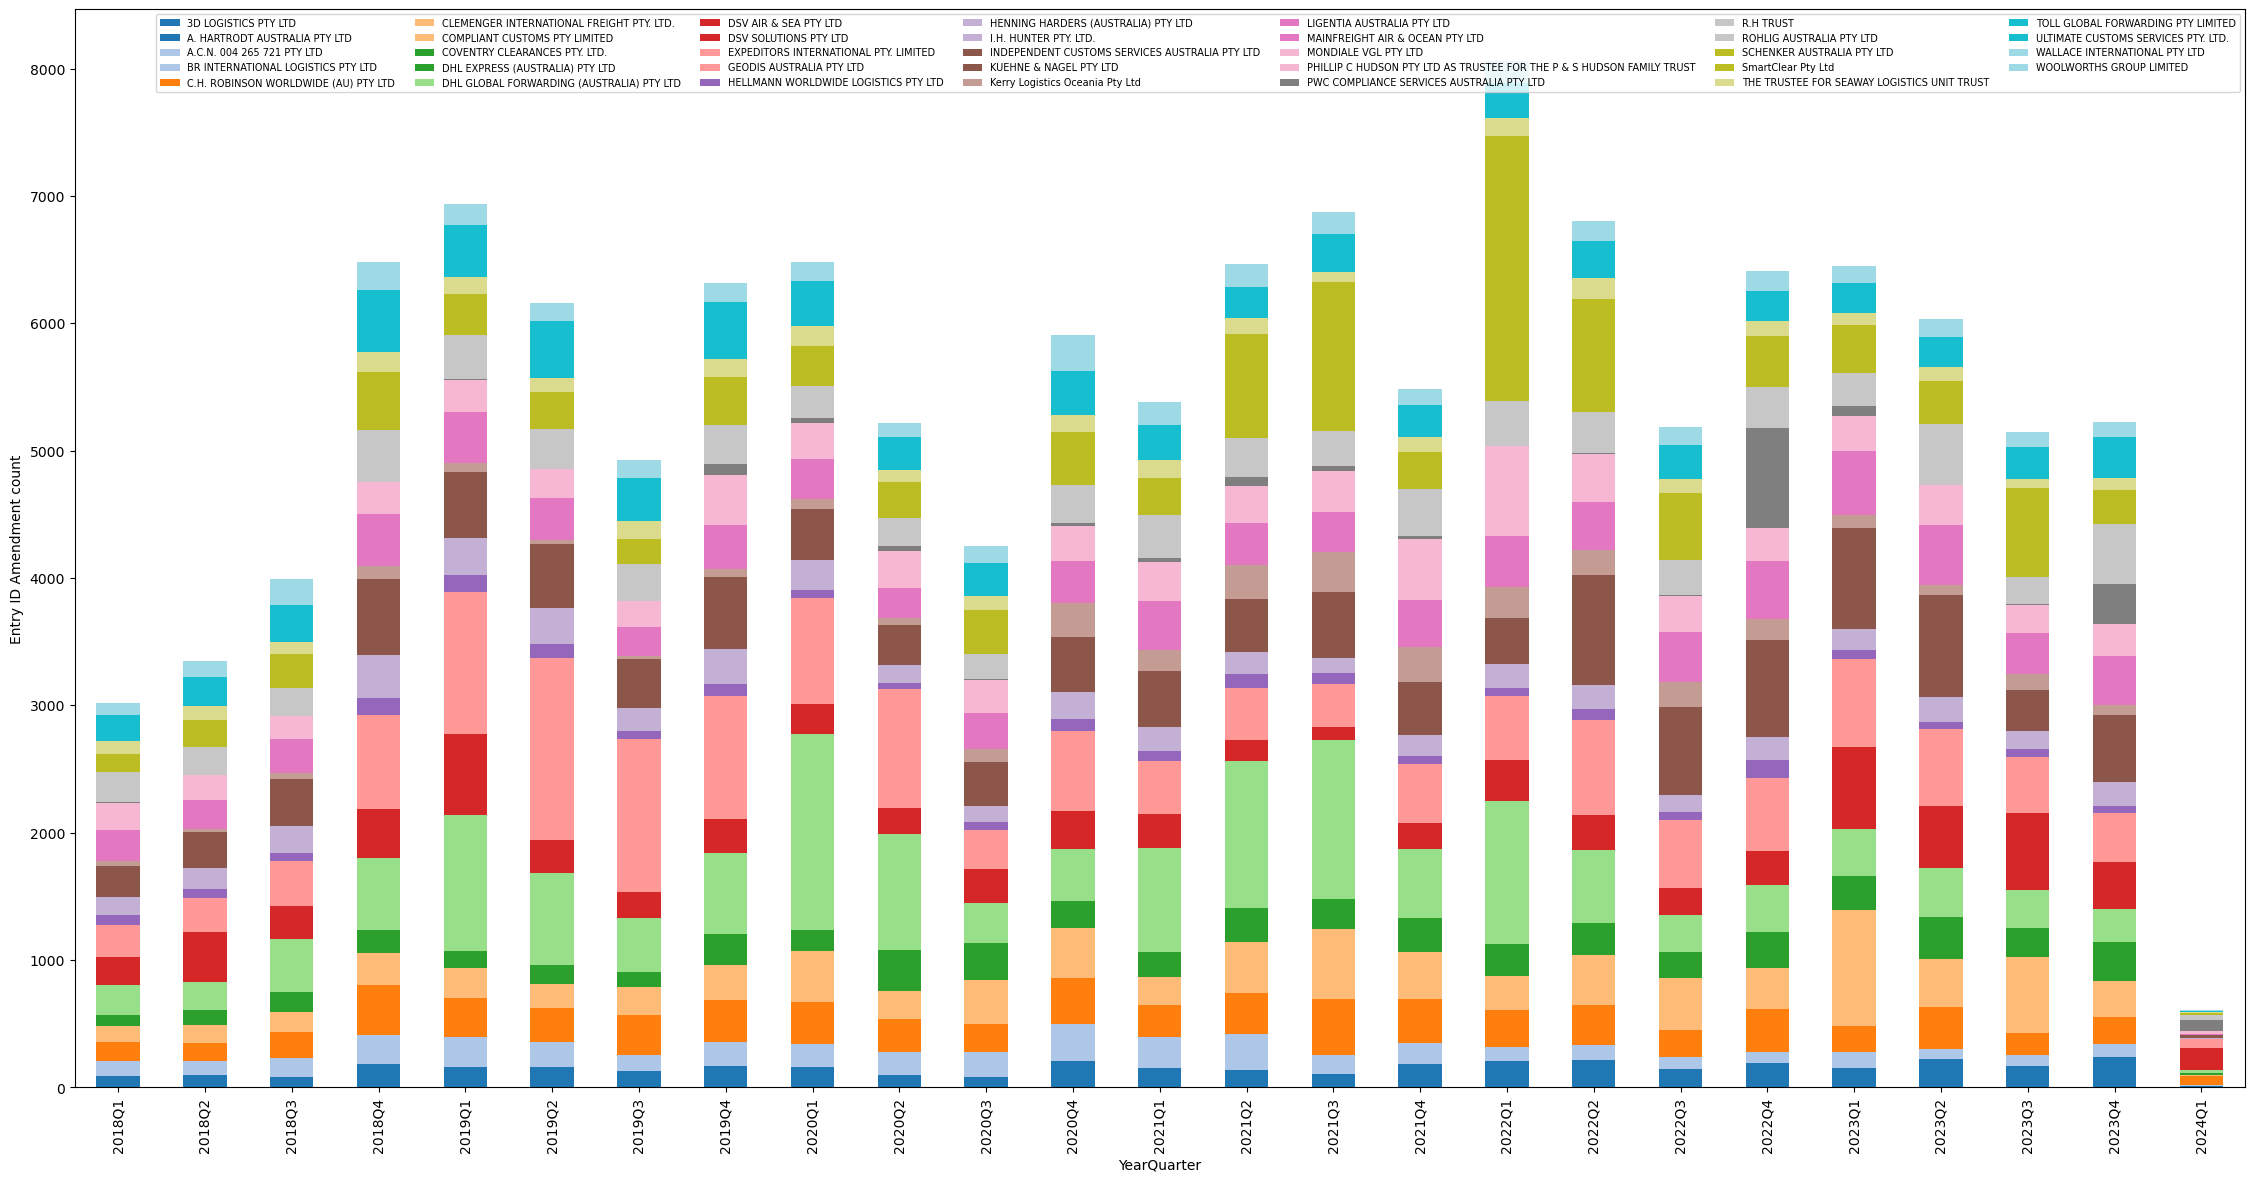

In [29]:
df_Br = df_ba[df_ba['Broker'].isin(top_brokers)]
df_Br['Broker'] = df_Br.Broker.astype("object", )
df_Br.groupby(['Broker', pd.to_datetime(df_Br['Amendment_date']).dt.to_period('Q')])['Entry_ID'].nunique().unstack().fillna(0).astype("int").T.plot(kind="bar", figsize=(28, 14), stacked=True, colormap="tab20")
plt.ylabel("Entry ID Amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc=None, fontsize=7, ncol=7);

It is evident that a small group of Brokers/Importers make the vast majority of contributions to the overall amendment volume at any time period.
Unfortunately, the legend with 34 Brokers is too difficult to read, so we need to split the chart into separate plots.

The 34 timeseries:

In [31]:
EID_am_counts = df_Br.groupby(['Broker', pd.to_datetime(df_Br['Amendment_date']).dt.to_period('Q')])['Entry_ID'].nunique().unstack().fillna(0)
mm_scaler = MinMaxScaler(feature_range=(0, 1))
eid_am_counts_scaled = mm_scaler.fit_transform(EID_am_counts.values.T)

# Create a DataFrame with the MinMaxNormalised counts:
mm_scaled_df = pd.DataFrame(data=eid_am_counts_scaled.T , index=EID_am_counts.index, columns=EID_am_counts.columns)
# Add a vertical offset to each line
for i in range(mm_scaled_df.shape[0]):
    mm_scaled_df.iloc[i, :] += i 

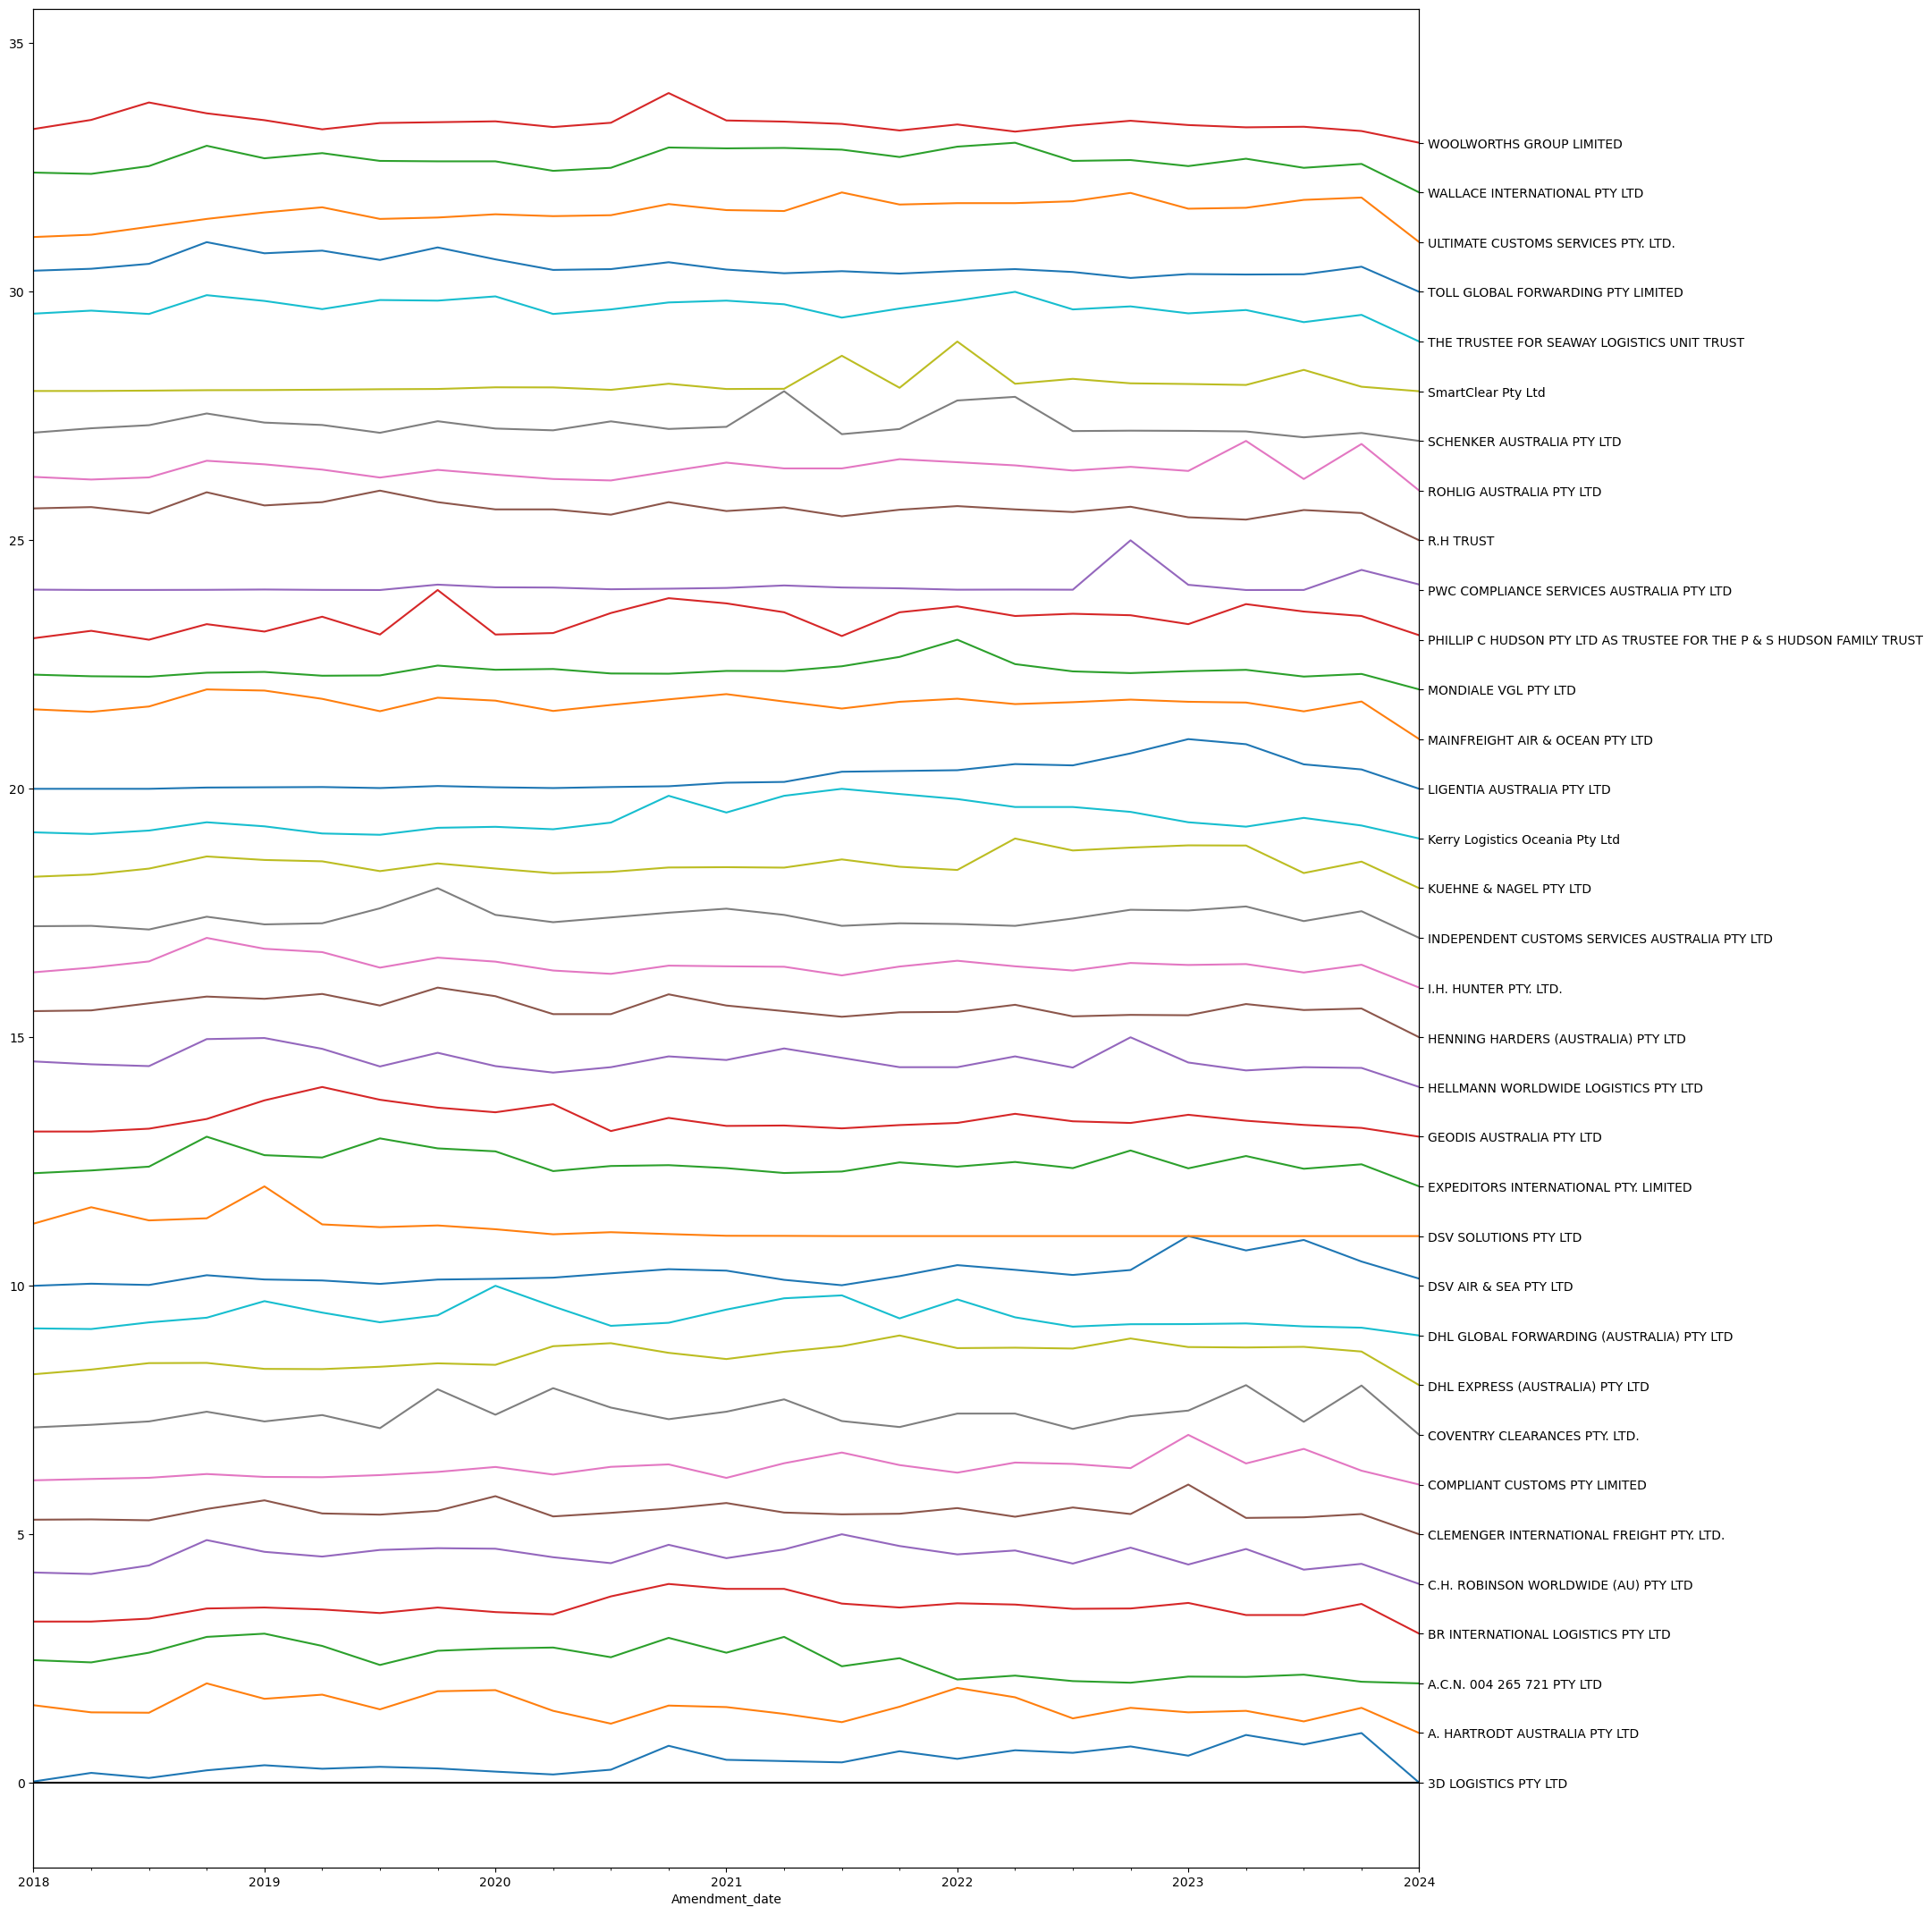

In [32]:
ax = mm_scaled_df.T.plot(figsize=(20, 27))

# Create a second y-axis
y2 = ax.twinx()
# Copy the y limits from the left axis
y2.set_ylim(ax.get_ylim())
# Set the right y-yick position
y2.set_yticks(list(range(mm_scaled_df.shape[0])))
# Set the right y-tick labels
y2.set_yticklabels(mm_scaled_df.index.to_list())
ax.axhline(y=0, color='k')
ax.get_legend().remove();

The bar chart above is also probably too "condensed" to discern anything unusual in the Broker amendment activity. Hence we break it down by each Broker/Importer, shown in the blue bar charts below.
In addition, we plot the timeseries of the field amendment counts for each of the dozen most commonly amended categories:

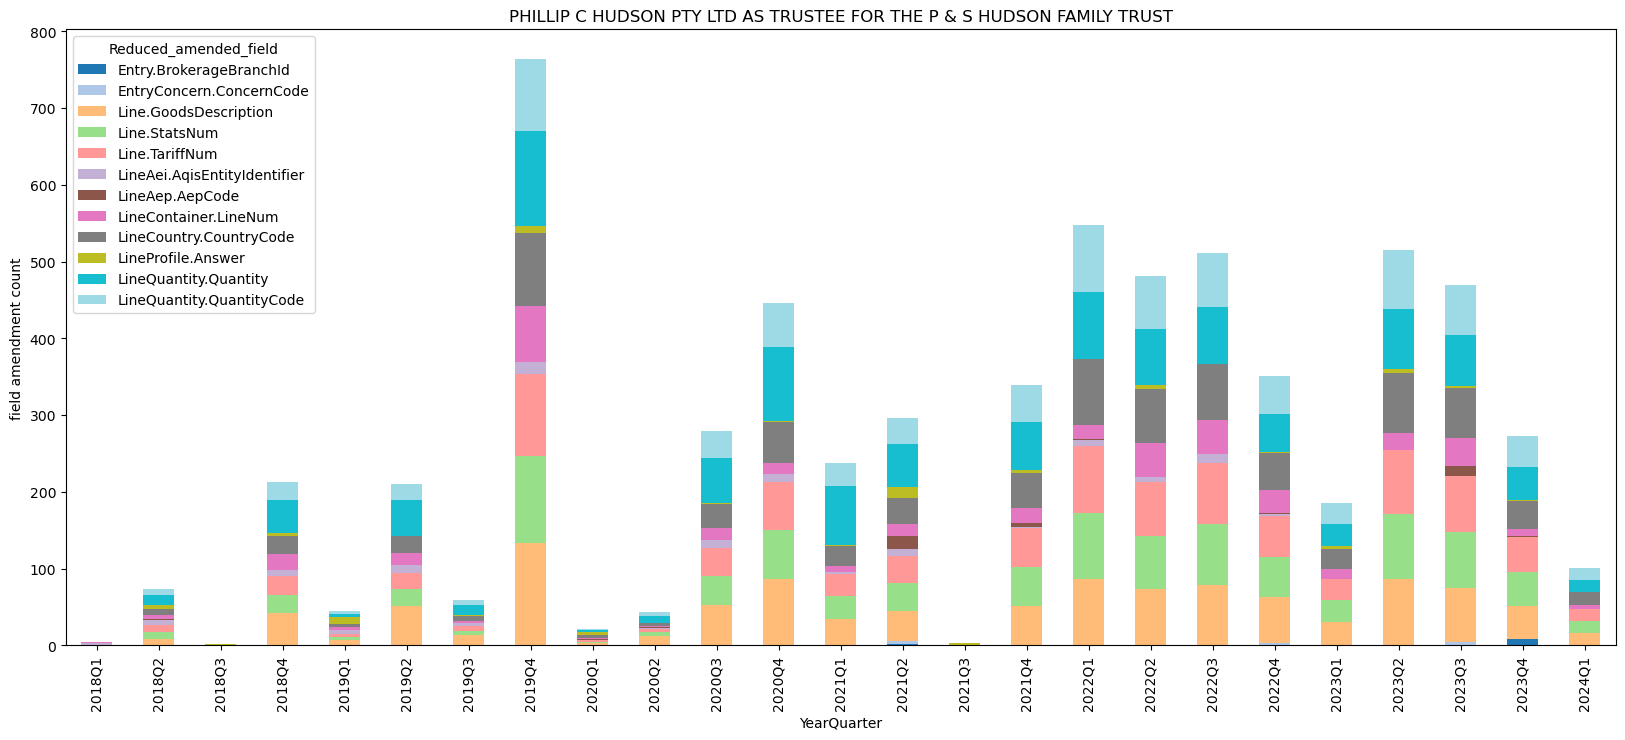

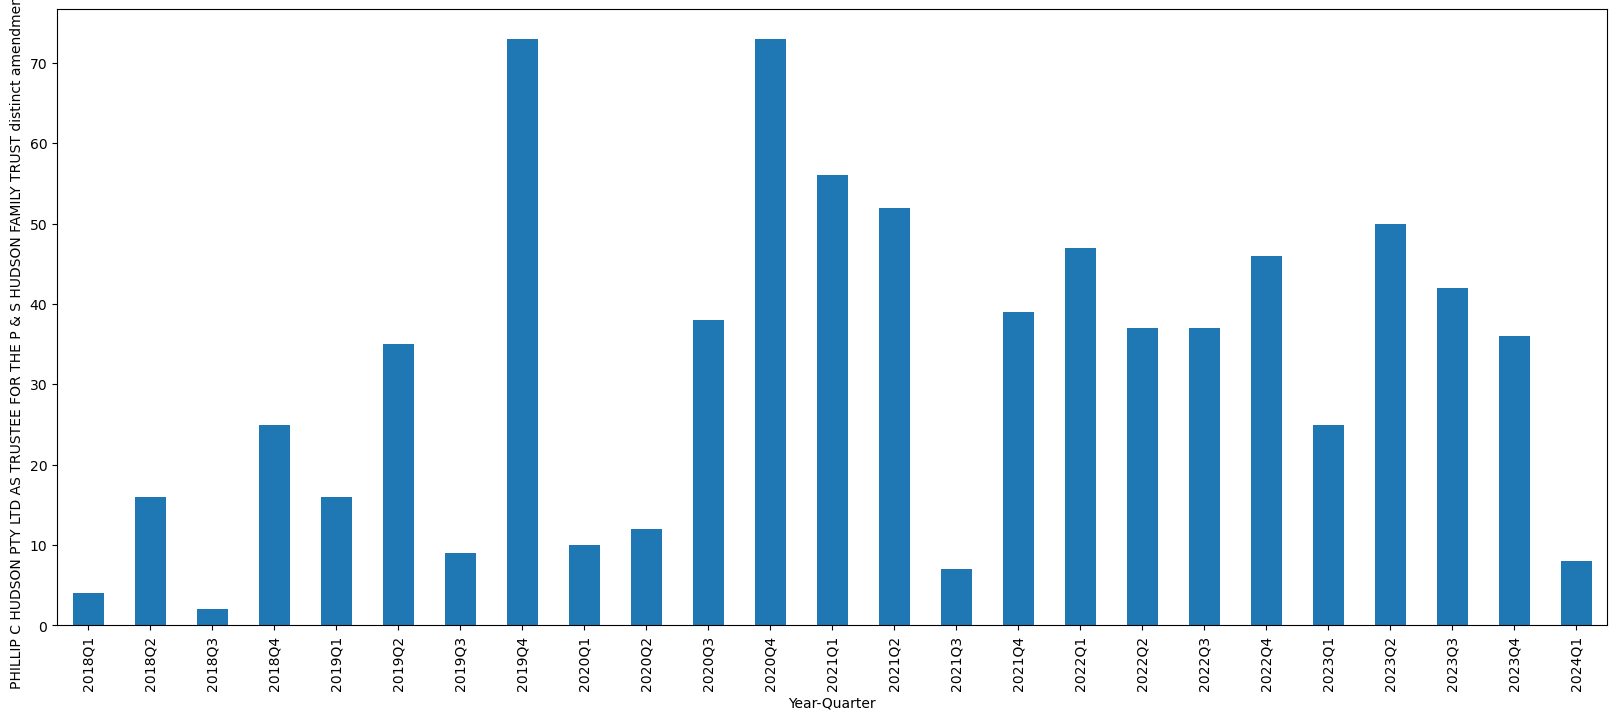

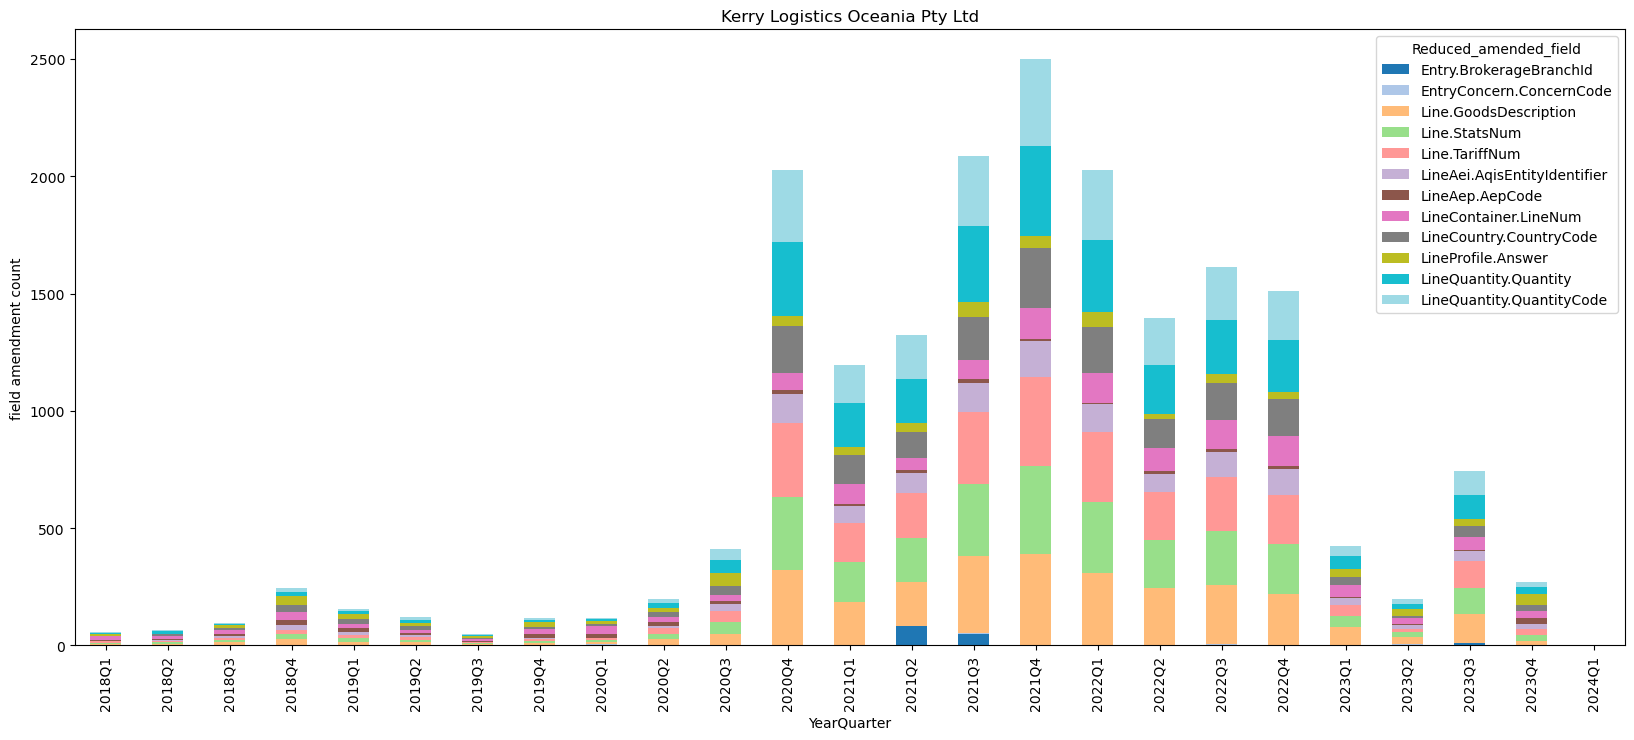

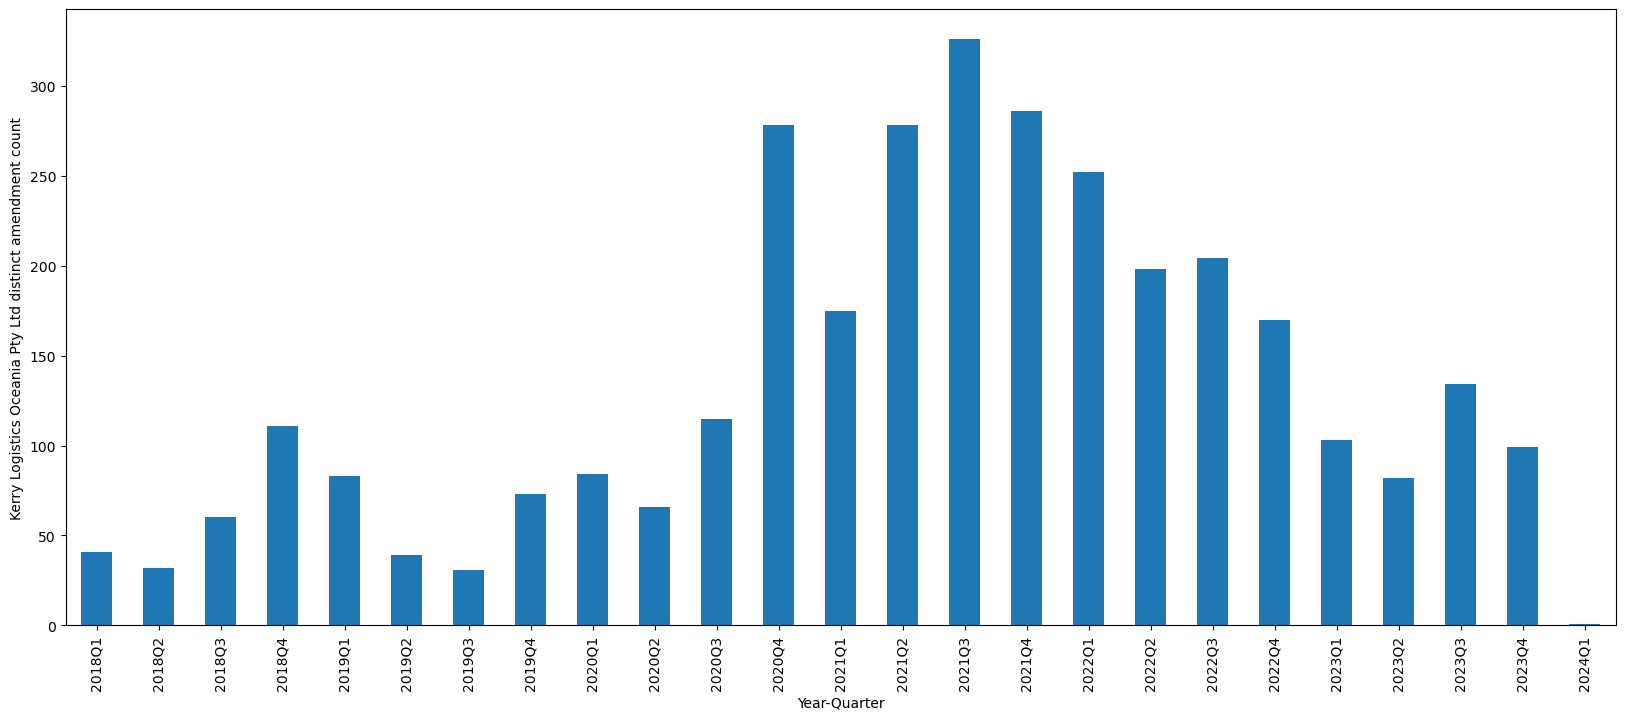

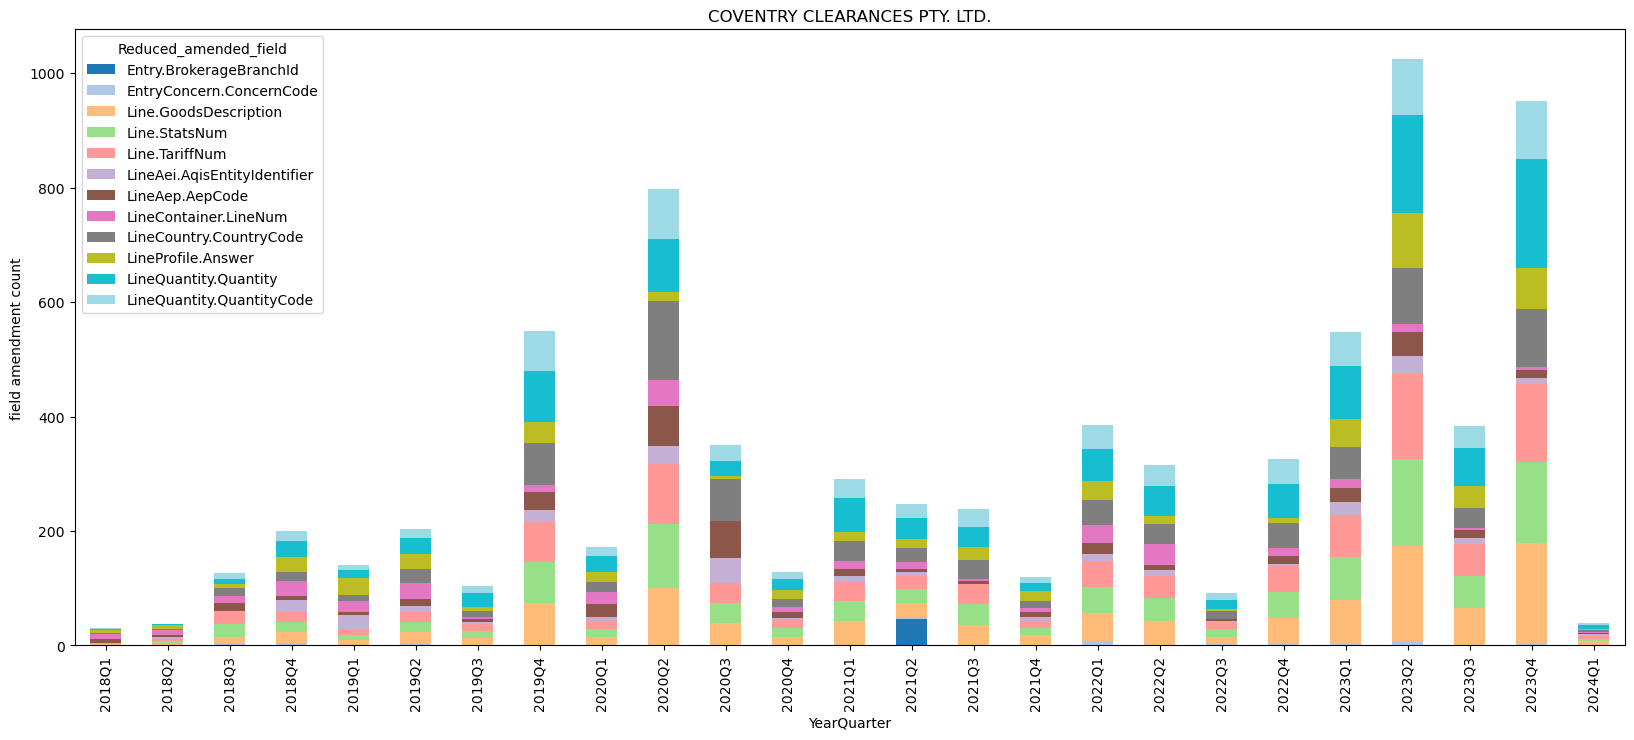

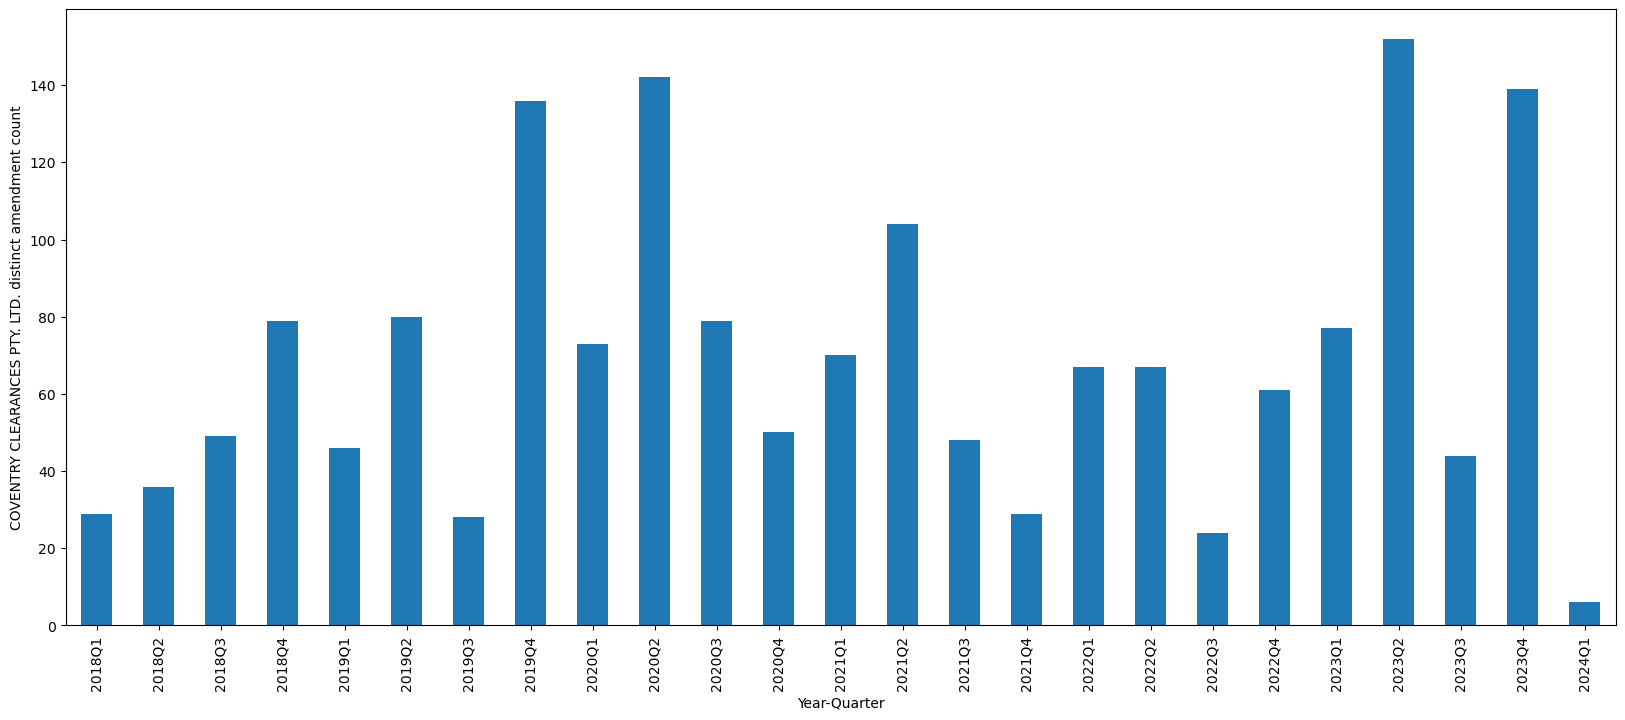

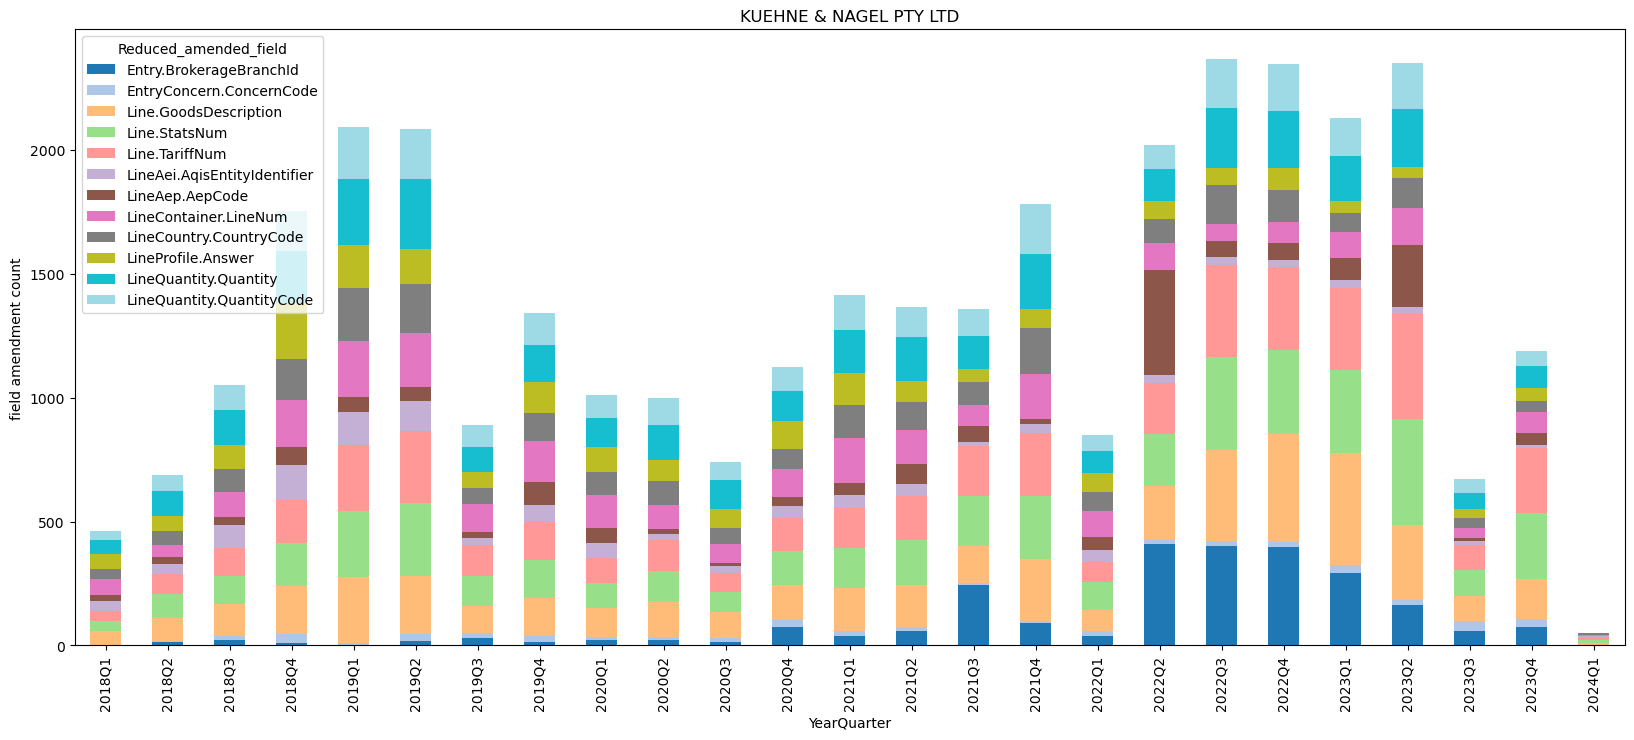

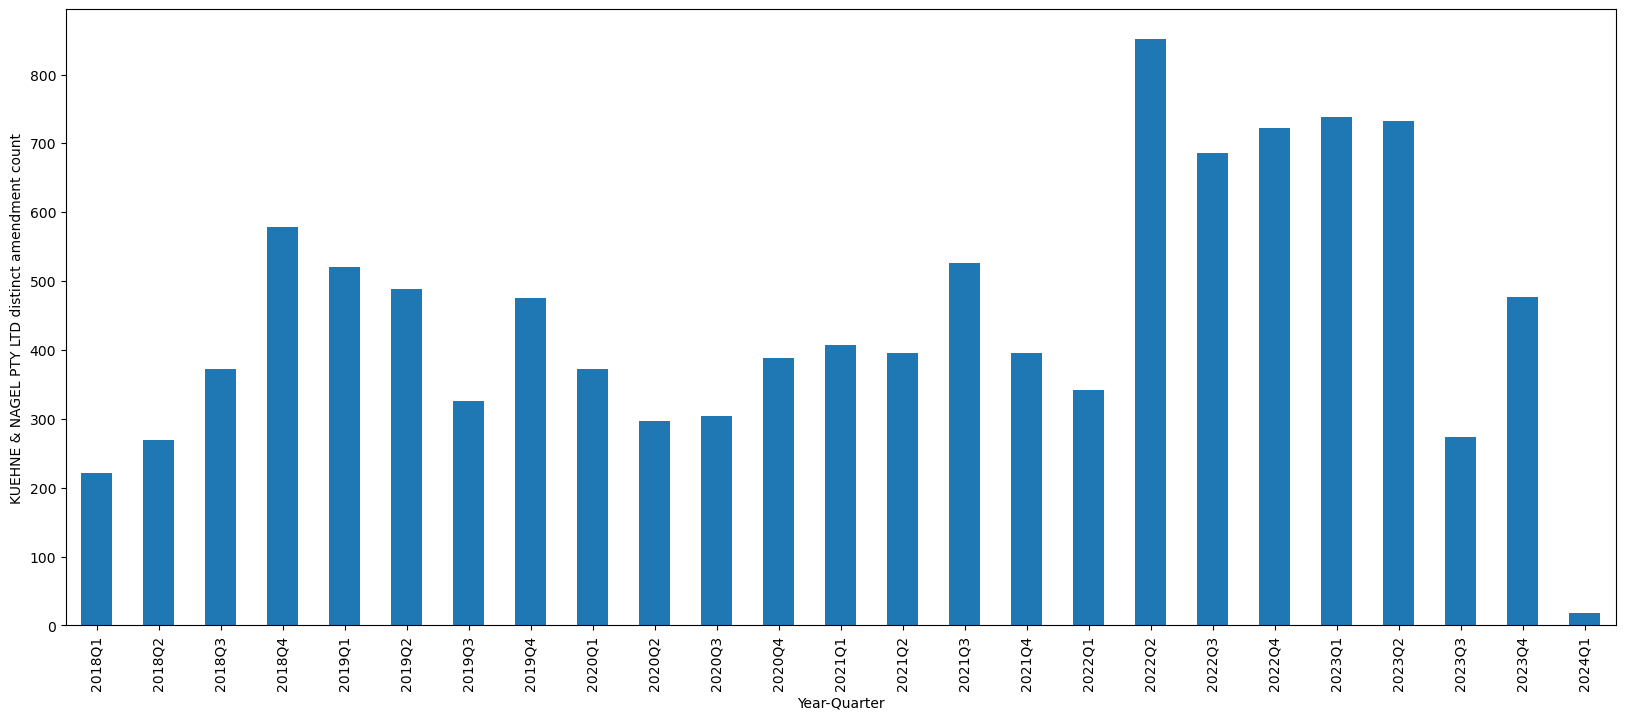

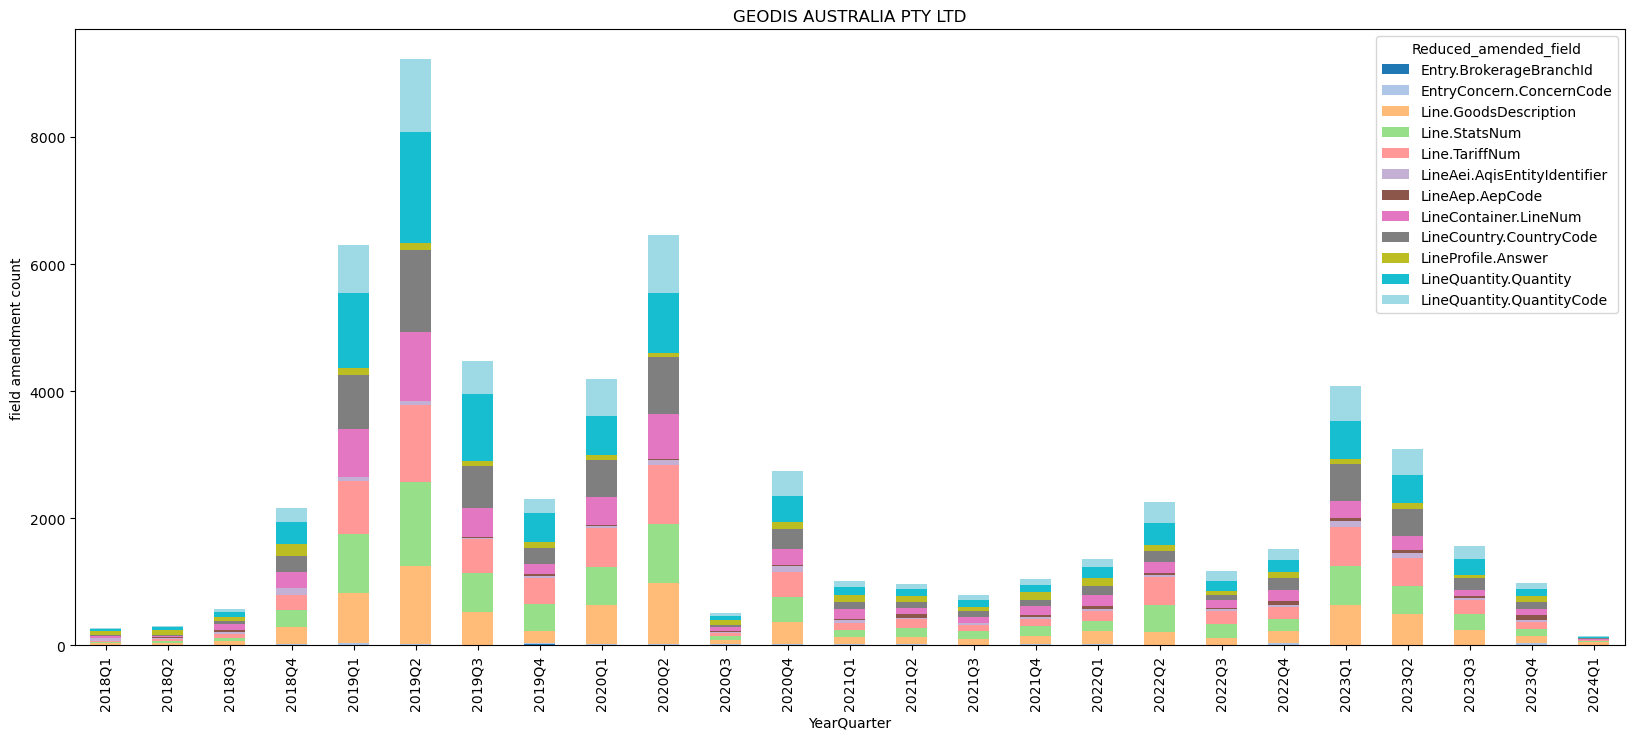

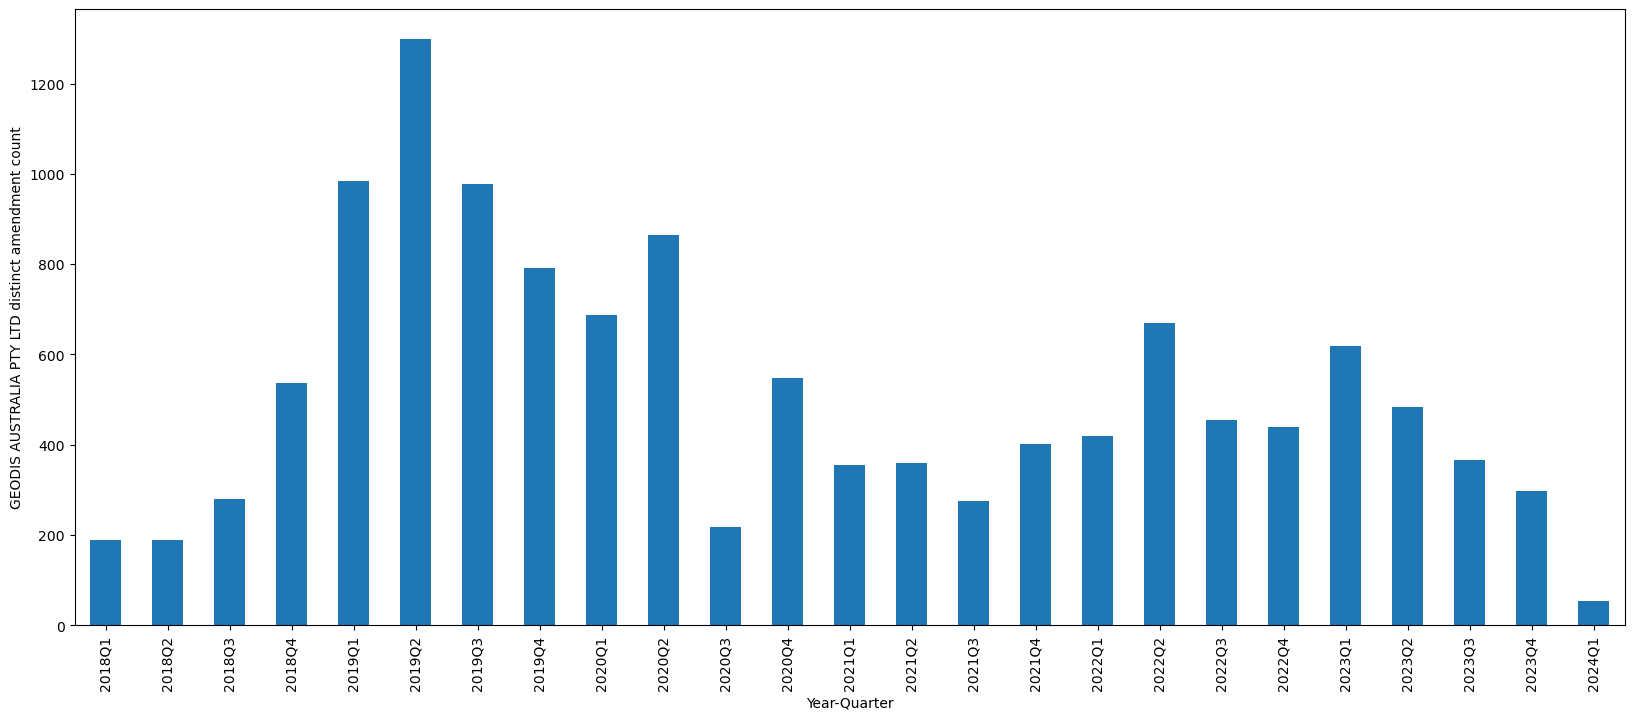

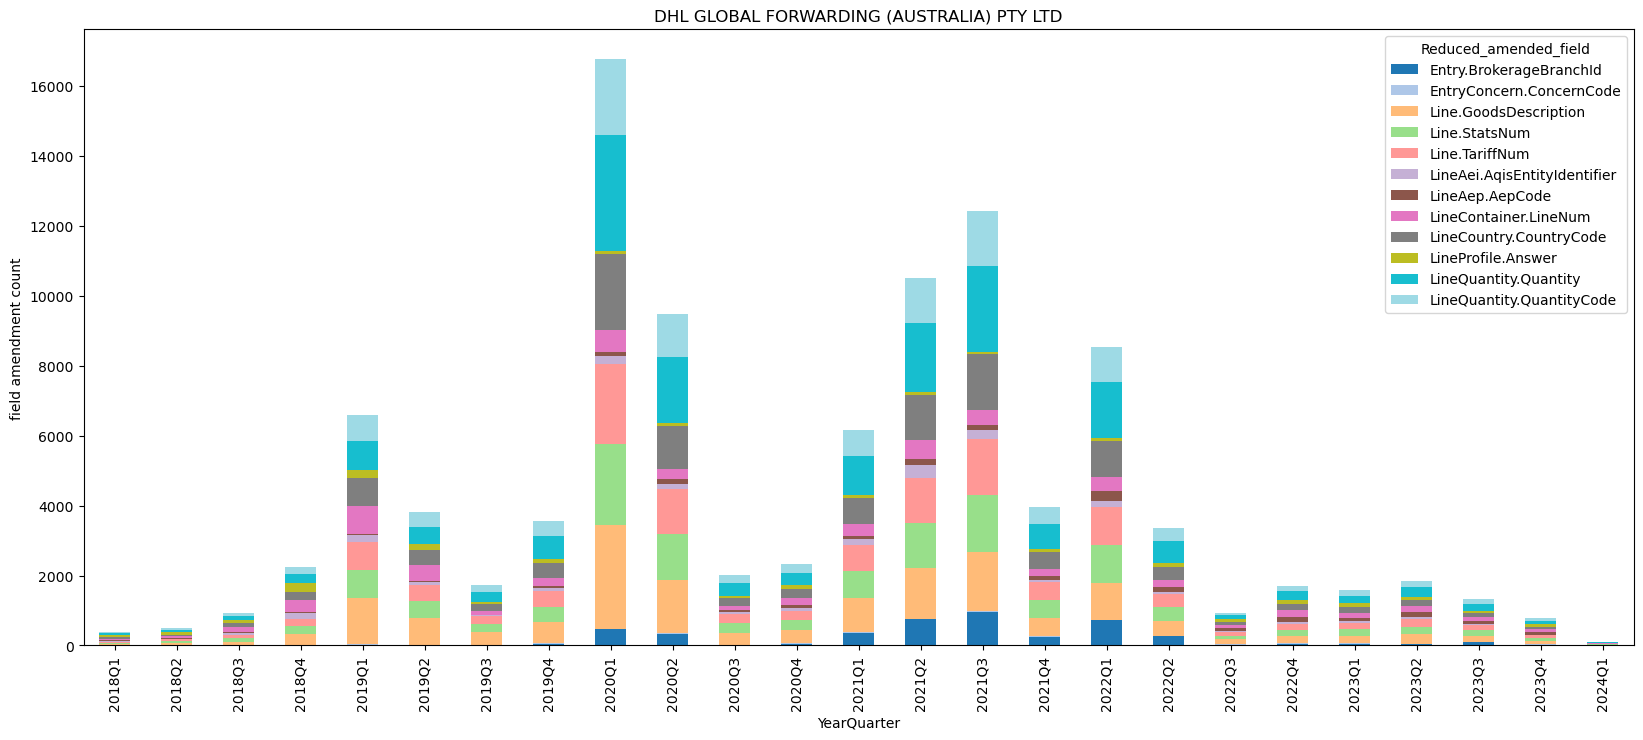

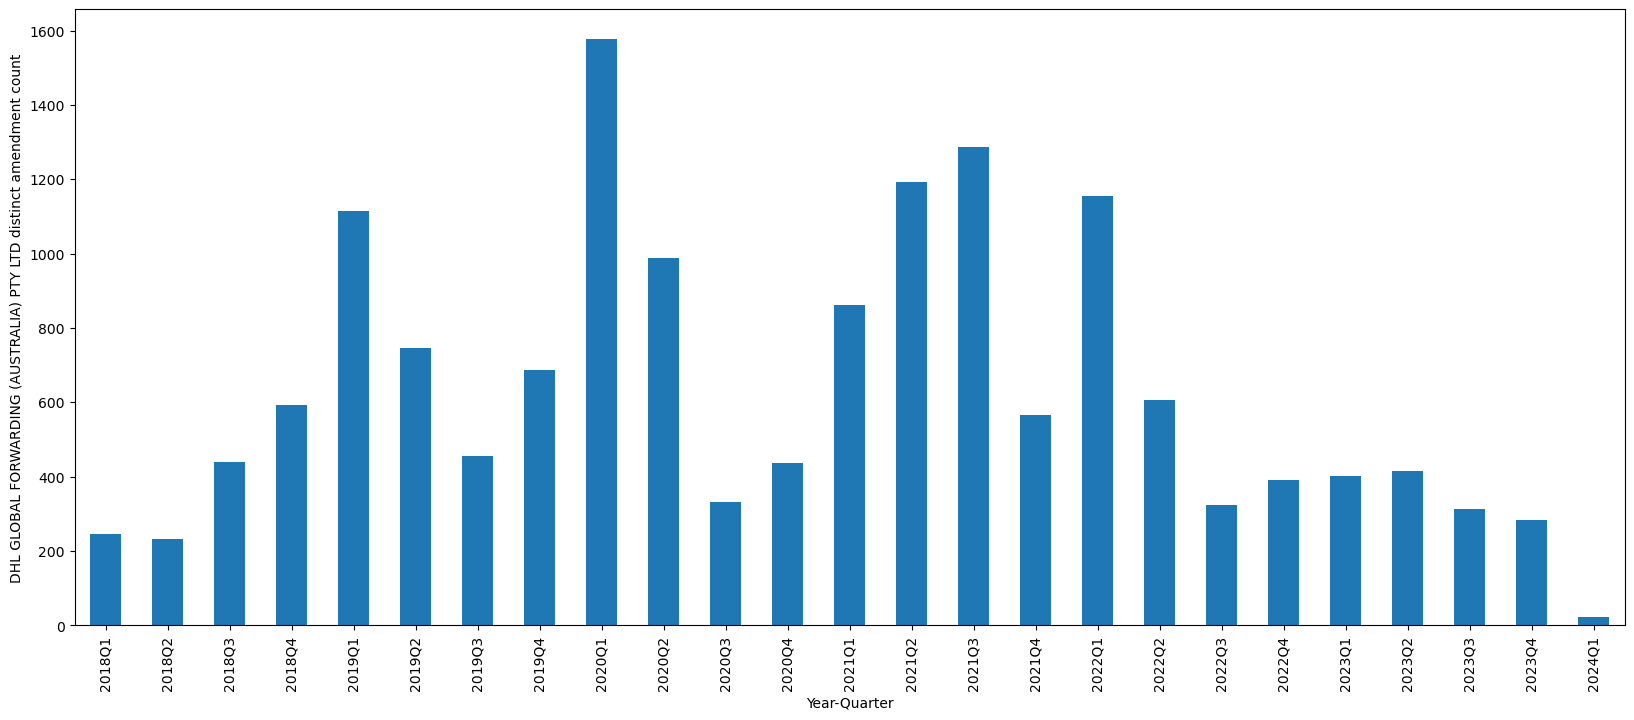

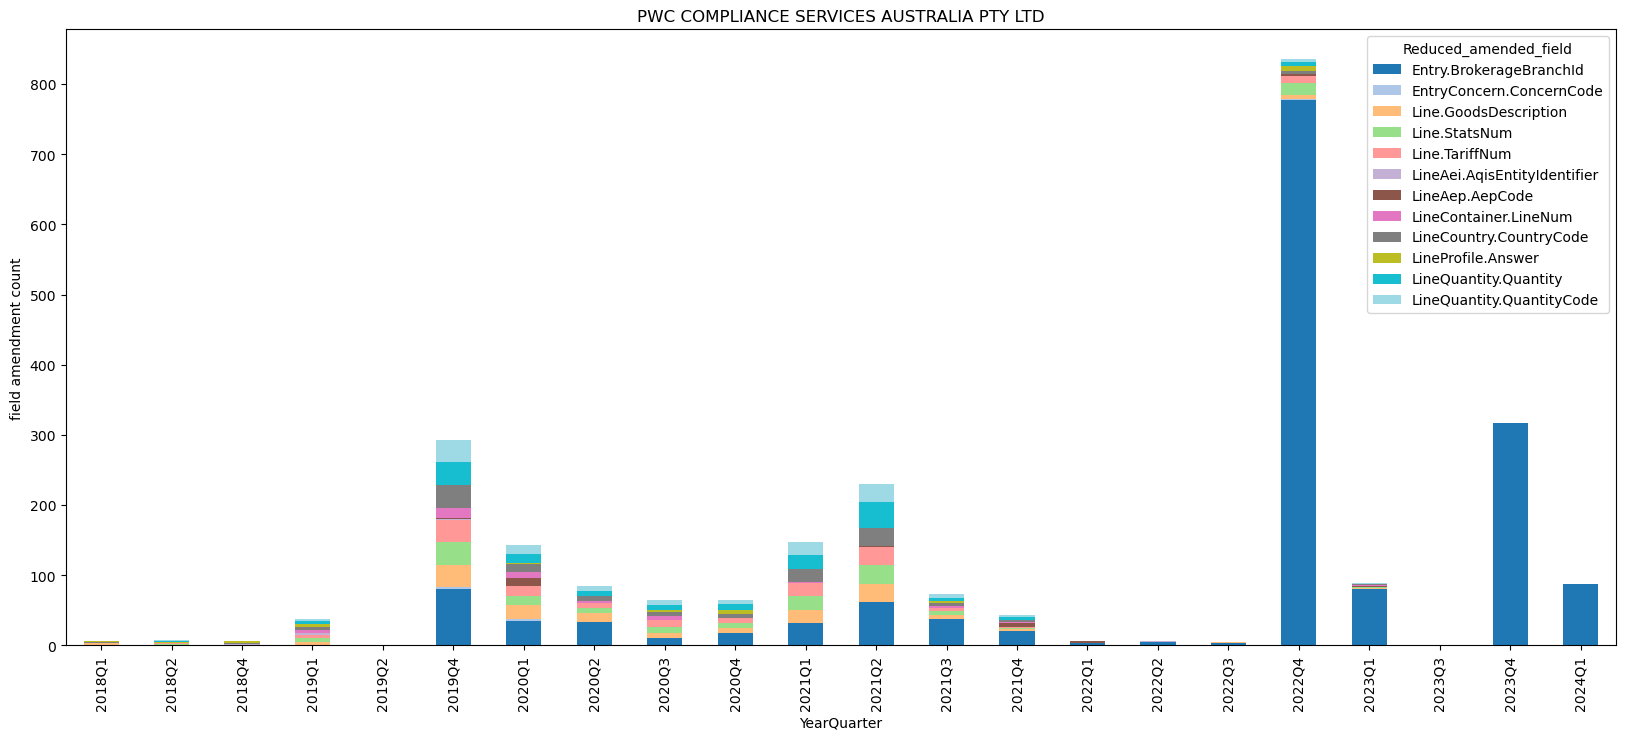

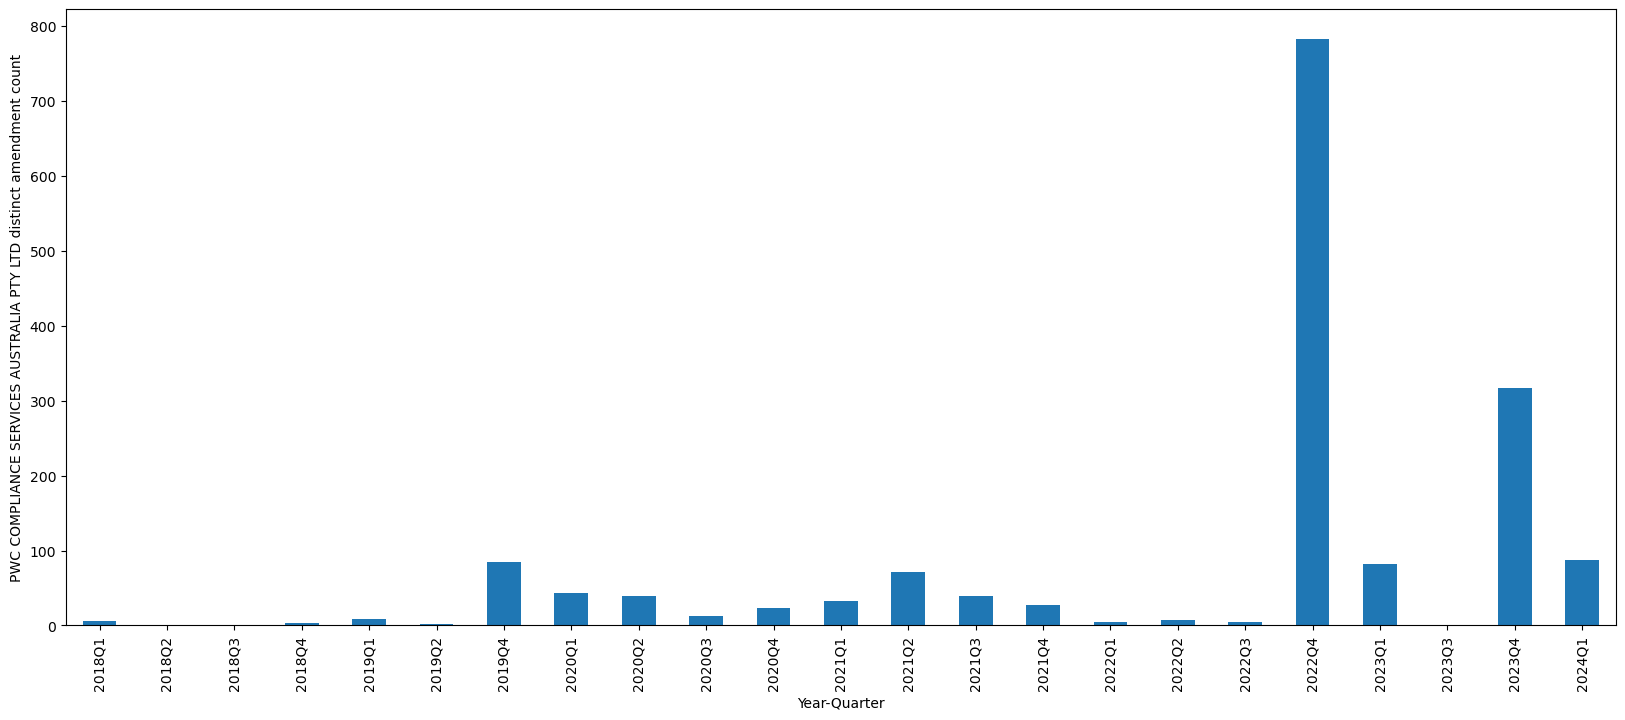

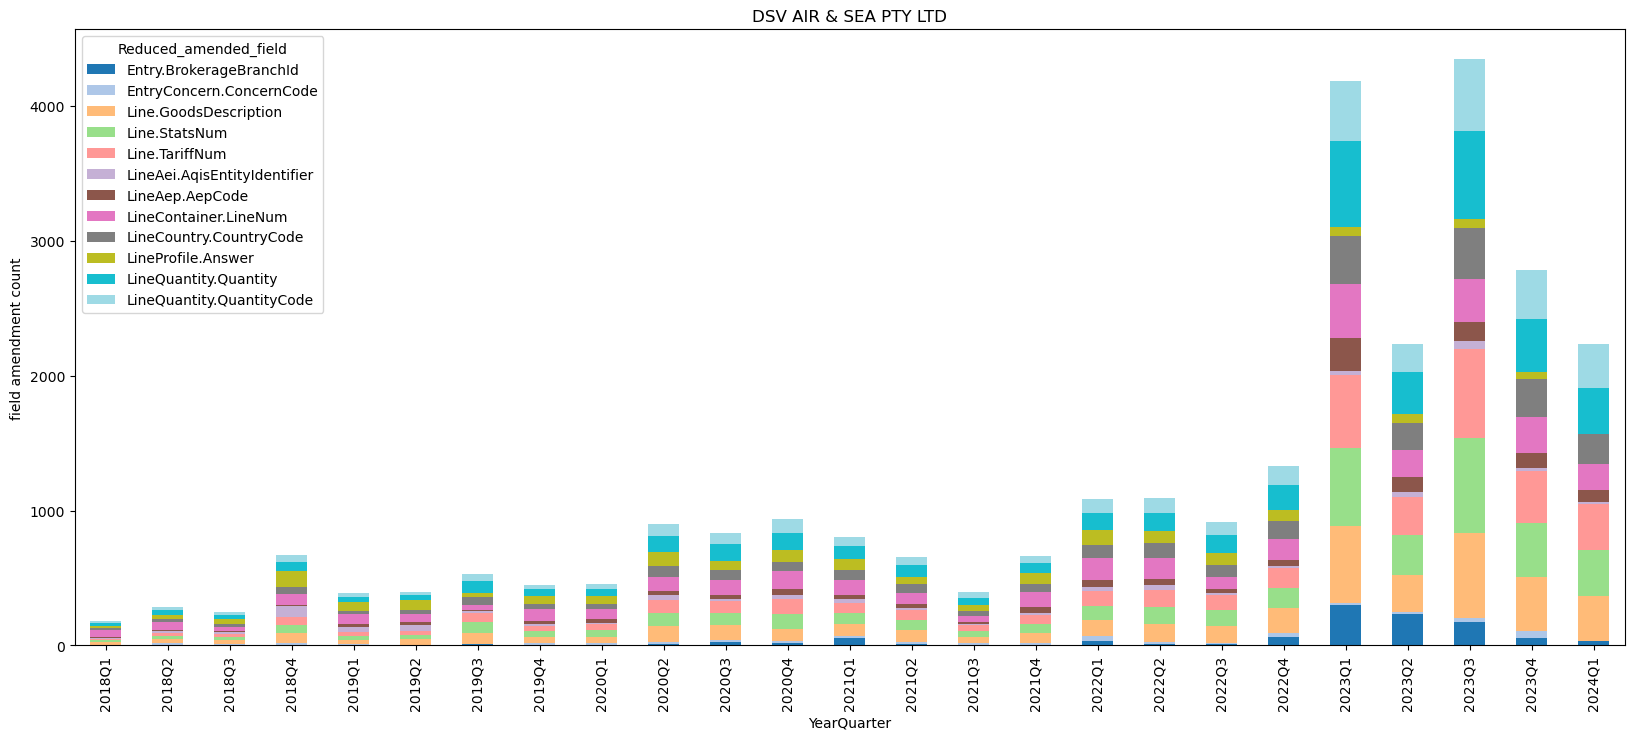

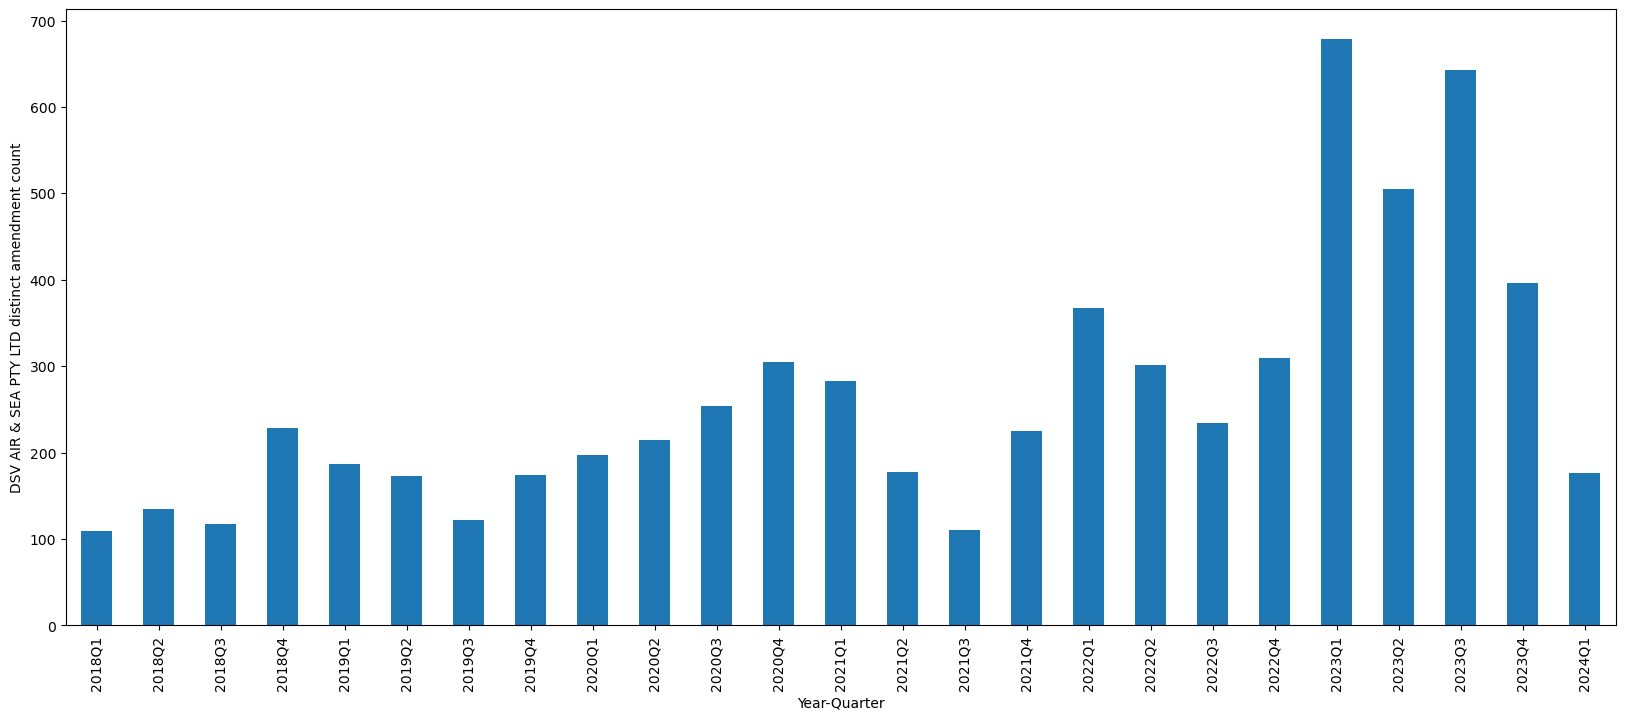

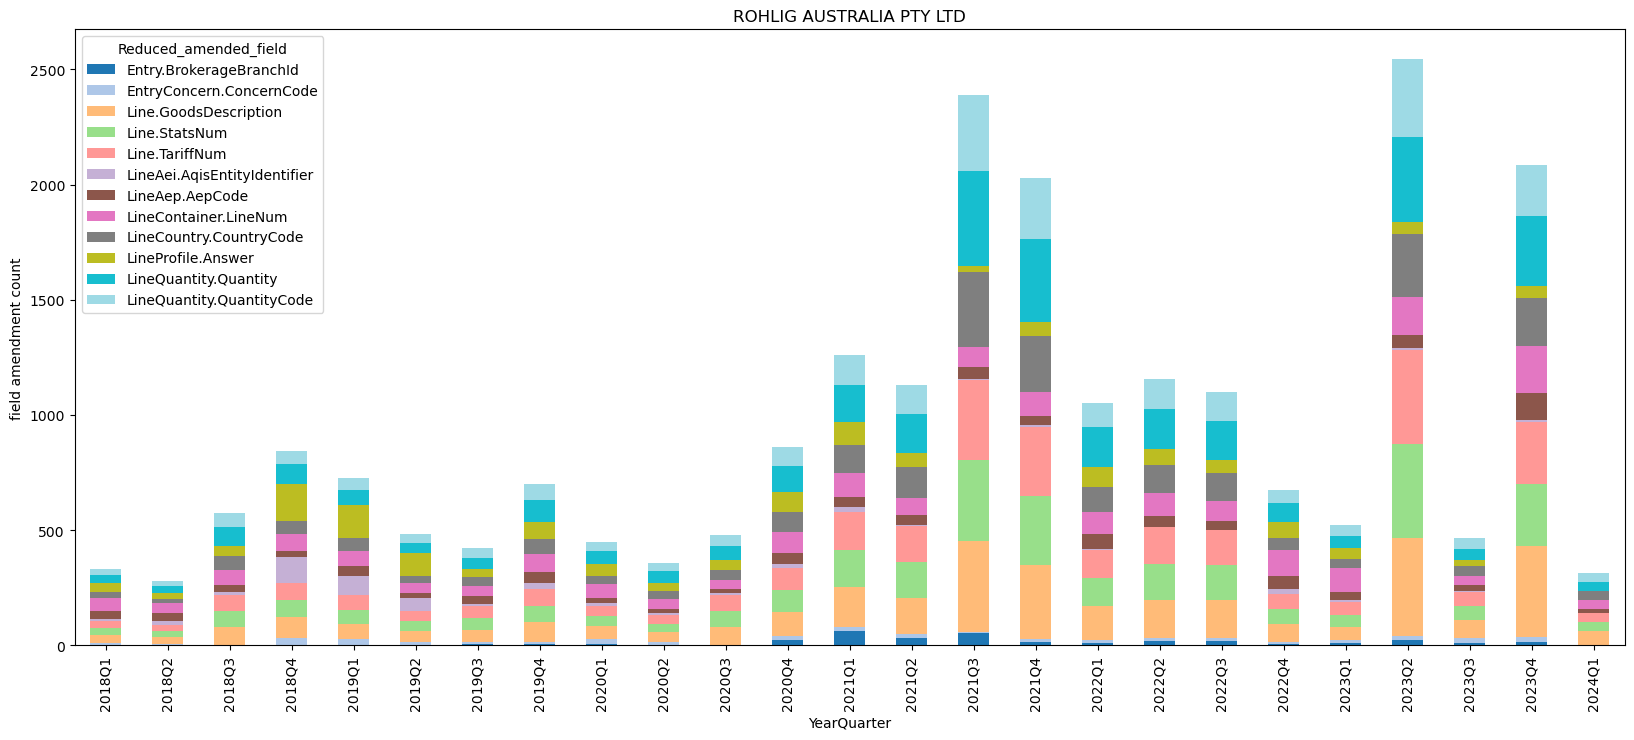

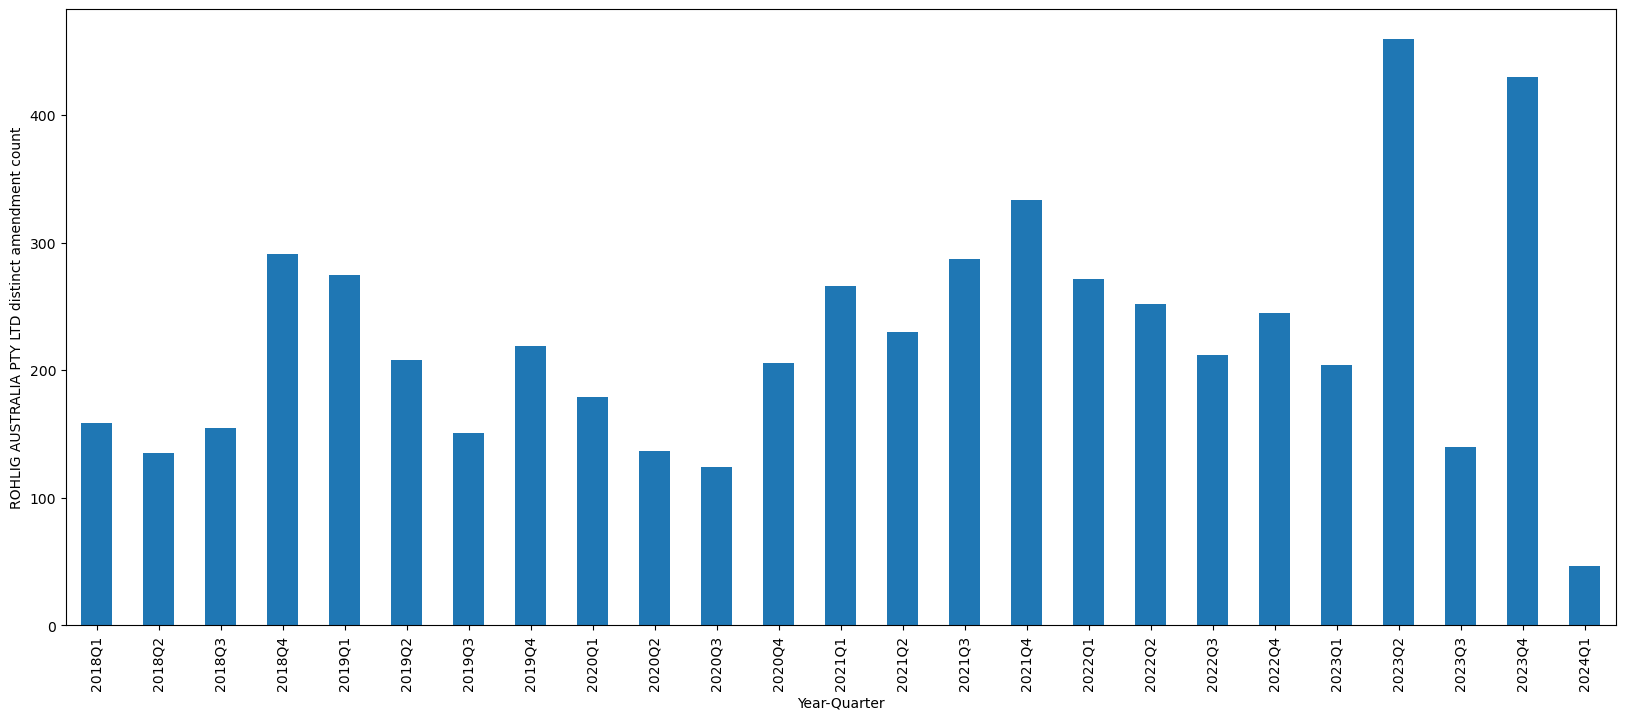

In [33]:
for b in ("PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST", "Kerry Logistics Oceania Pty Ltd", "COVENTRY CLEARANCES PTY. LTD.", "KUEHNE & NAGEL PTY LTD", "GEODIS AUSTRALIA PTY LTD",
          "DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD",  "PWC COMPLIANCE SERVICES AUSTRALIA PTY LTD", "DSV AIR & SEA PTY LTD", "ROHLIG AUSTRALIA PTY LTD"):
    df_Br = df_ba.query('Broker == @b').query('Reduced_amended_field in @top_katz')
    df_Br['Reduced_amended_field'] = df_Br['Reduced_amended_field'].astype("object")
    df_Br.drop_duplicates(['Entry_ID', 'Amendment_date', 'Summary_amended_field']).\
    groupby(['Reduced_amended_field', pd.to_datetime(df_Br['Amendment_date']).dt.to_period('Q')])['Entry_ID'].count().unstack().fillna(0).astype("int").T.plot(kind="bar", figsize=(20, 8), stacked=True, colormap='tab20')
    plt.ylabel("field amendment count")
    plt.xlabel("YearQuarter")
    plt.title(b)
    plt.show()
    df_Br = df_ba.query('Broker == @b').drop_duplicates(['Entry_ID', 'Amendment_date'])
    df_Br.groupby(pd.to_datetime(df_Br['Amendment_date']).dt.to_period('Q'))['Entry_ID'].count().fillna(0).astype("int").T.plot(kind="bar", figsize=(20, 8))
    plt.ylabel(f"{b} distinct amendment count")
    plt.xlabel("Year-Quarter")
    plt.show()
    print("\n\n")

As we previously stated, there is a group of half a dozen Brokers who make very extensive amendments, manifested by the vary large *"Avg_updates_per_EntryID"* values.
It may be instructive to compare the *extent* of the amendments, as reflected through the volume of updates made by each Broker over time.
We select the first five Brokers above and we also add "MAINFREIGHT AIR & OCEAN PTY LTD", which seems to operate on a similar import volume scale, for comparison:

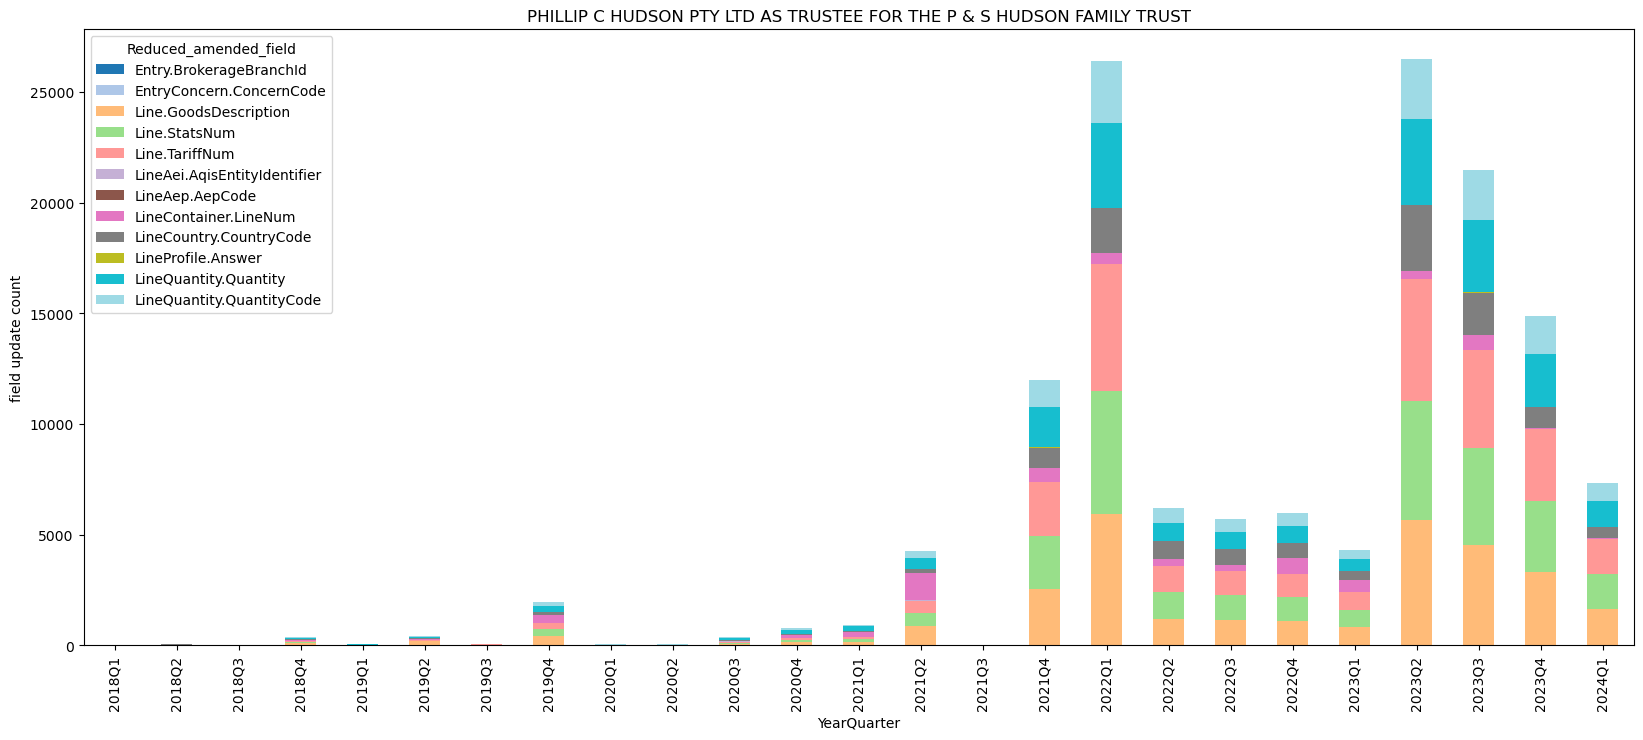

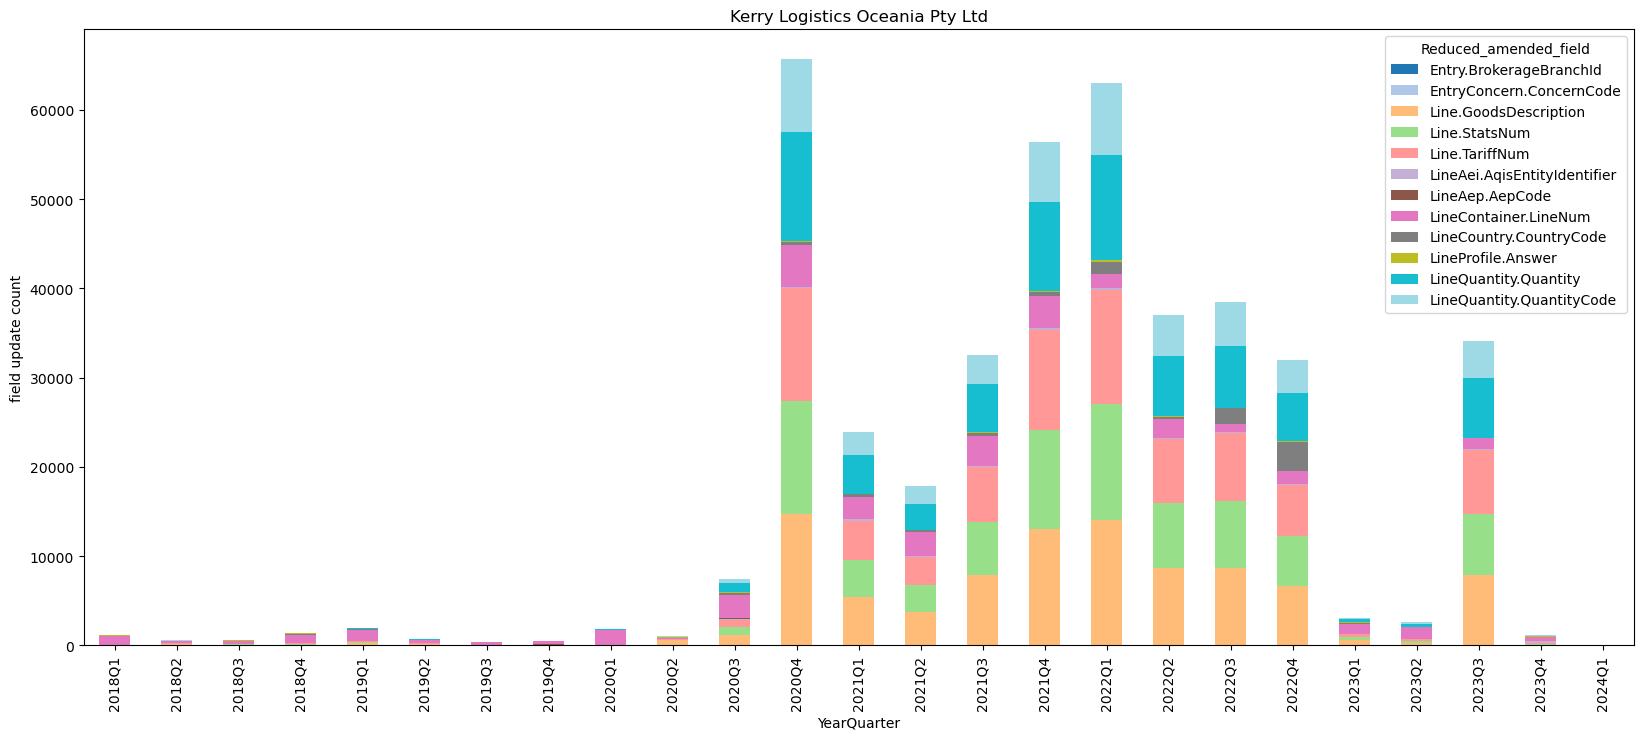

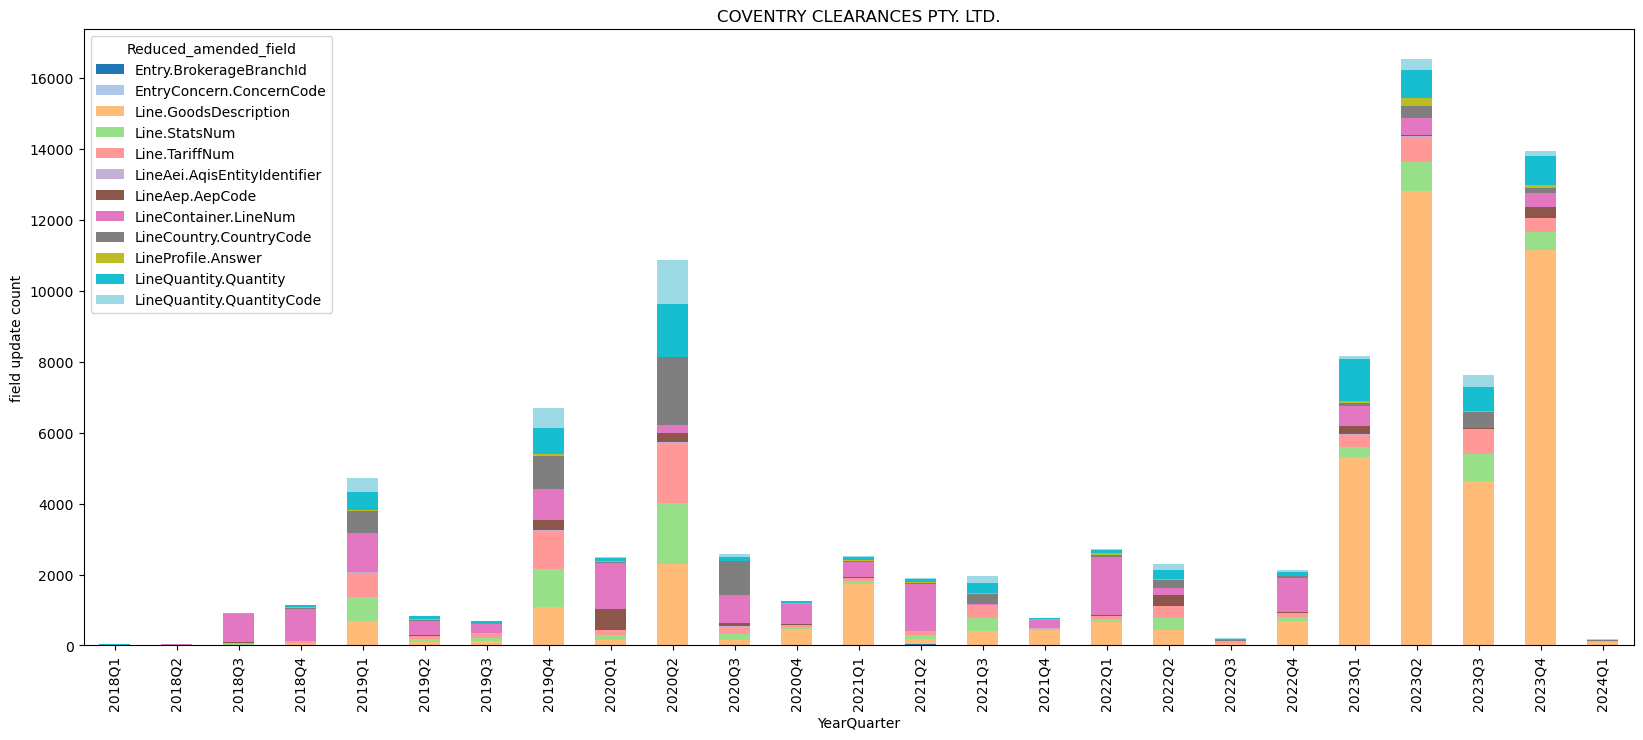

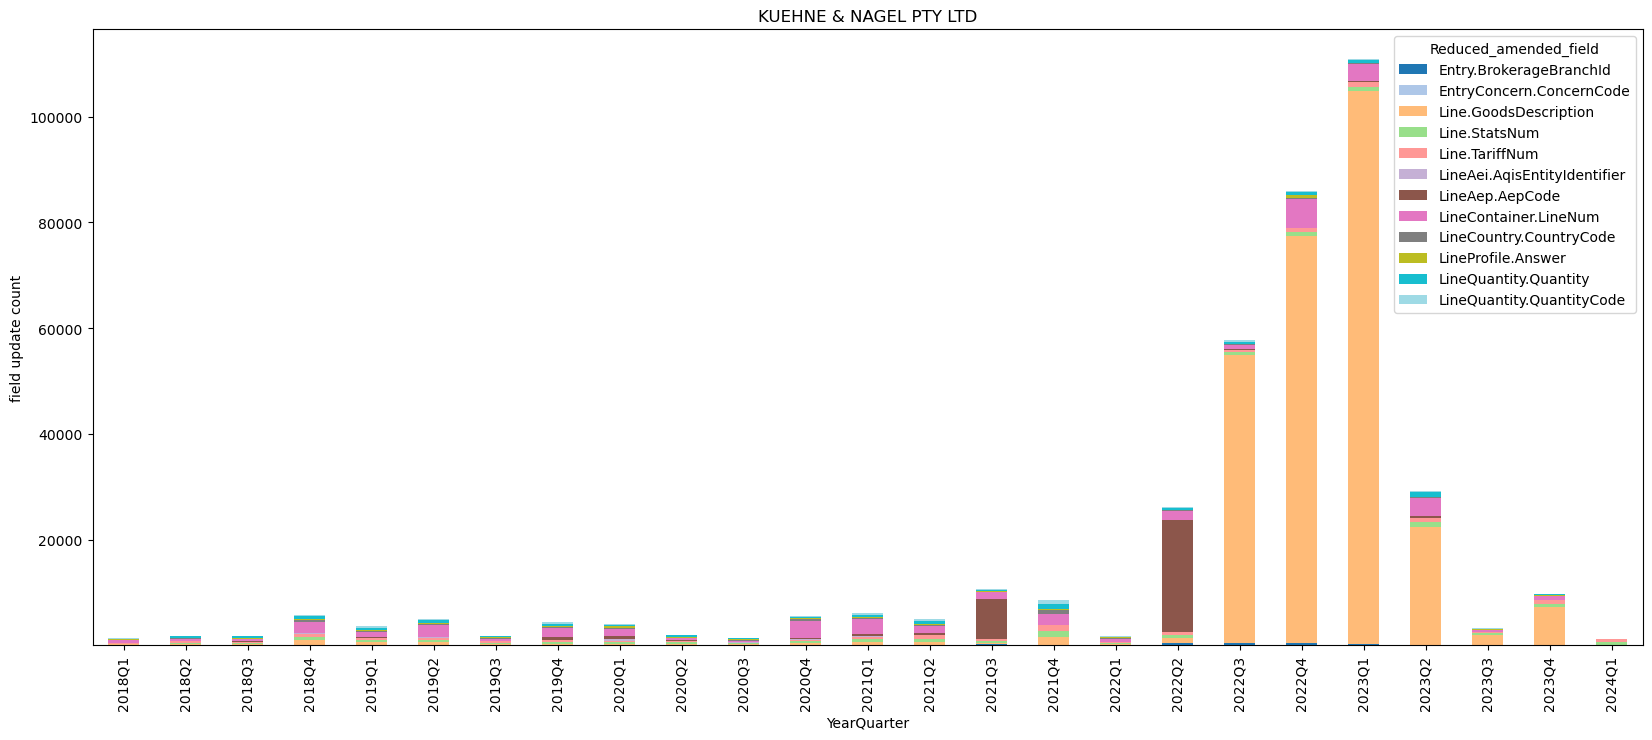

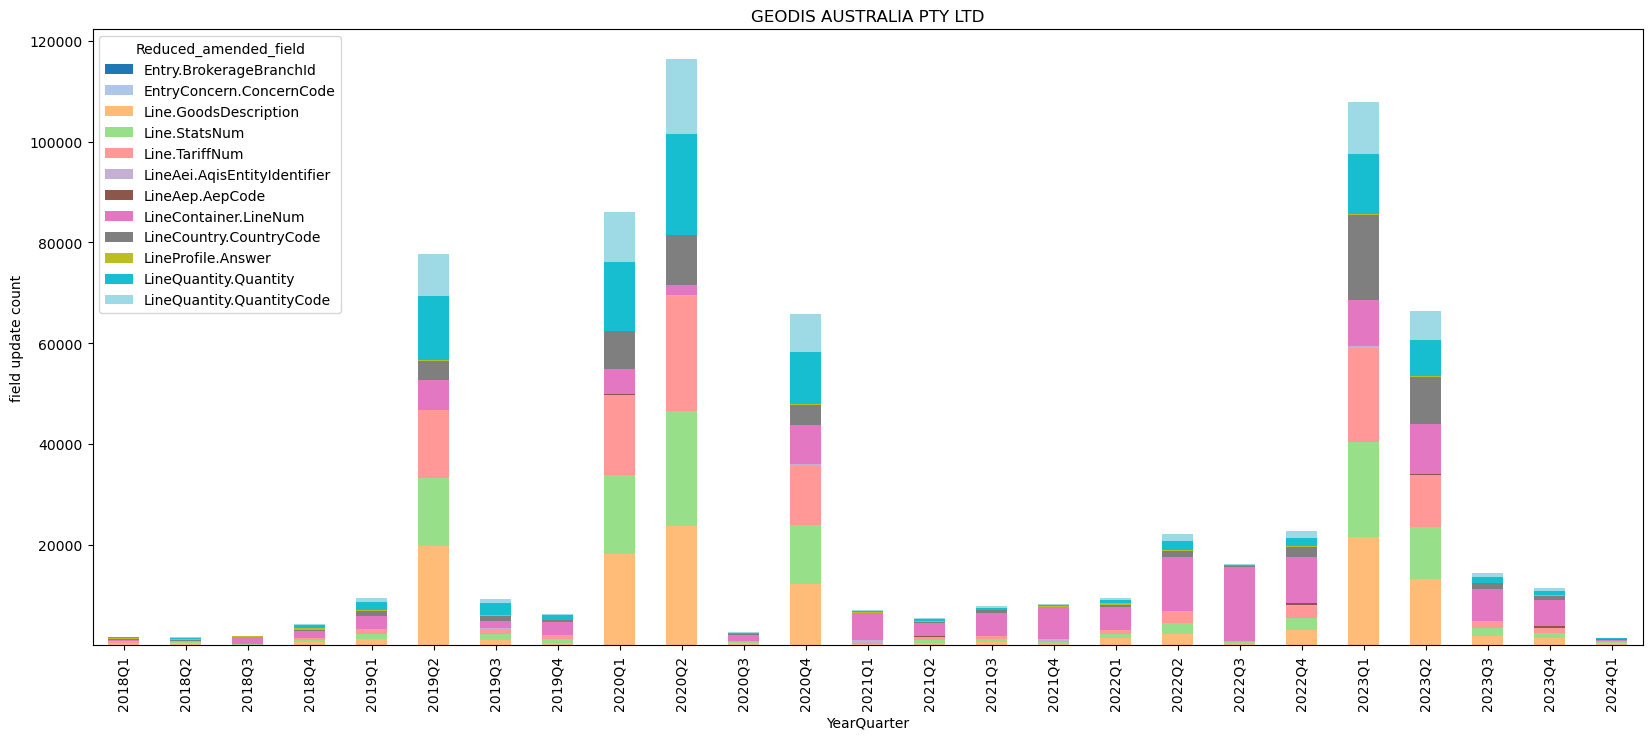

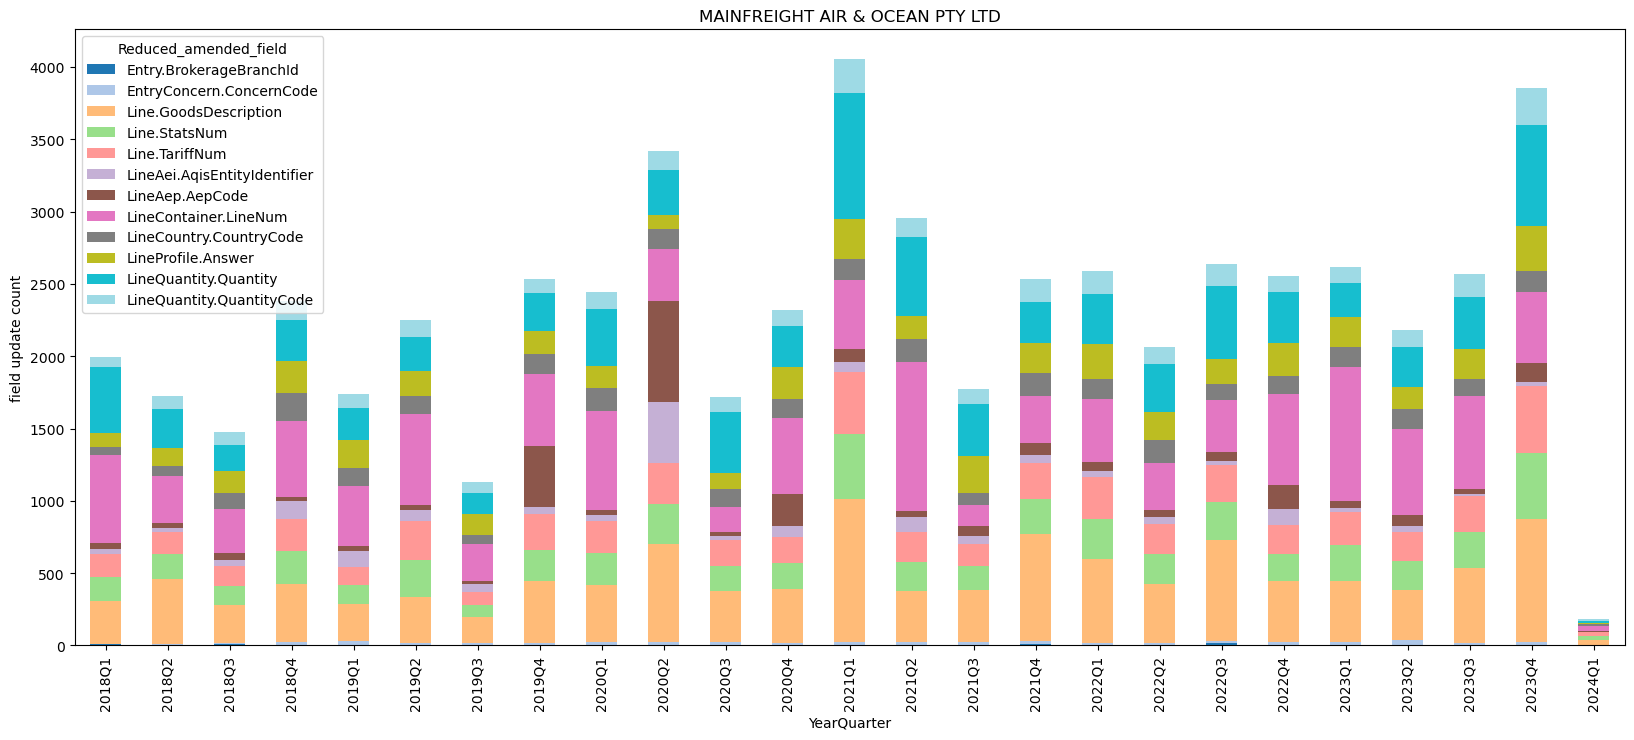

In [34]:
for b in ("PHILLIP C HUDSON PTY LTD AS TRUSTEE FOR THE P & S HUDSON FAMILY TRUST", "Kerry Logistics Oceania Pty Ltd", "COVENTRY CLEARANCES PTY. LTD.", "KUEHNE & NAGEL PTY LTD", "GEODIS AUSTRALIA PTY LTD",
          "MAINFREIGHT AIR & OCEAN PTY LTD"):
    df_Br = df_ba.query('Broker == @b').query('Reduced_amended_field in @top_katz')
    df_Br['Reduced_amended_field'] = df_Br['Reduced_amended_field'].astype("object")
    df_Br.groupby(['Reduced_amended_field', pd.to_datetime(df_Br['Amendment_date']).dt.to_period('Q')])['Entry_ID'].count().unstack().fillna(0).astype("int").T.plot(kind="bar", figsize=(20, 8), stacked=True, colormap='tab20')
    plt.ylabel("field update count")
    plt.xlabel("YearQuarter")
    plt.title(b)
    plt.show()
    print("\n\n")

Evident from the charts above, the __"PHILLIP C HUDSON PTY LTD"__, __"Kerry Logistics Oceania Pty Ltd"__, __"COVENTRY CLEARANCES PTY. LTD."__, __"KUEHNE & NAGEL PTY LTD"__, and __"GEODIS AUSTRALIA PTY LTD"__ have all engaged in in a large scale updating at certain times, which appears inconsistent with their overall behaviour. Most notable are the changes in the "GoodsDescription" by "Coventry Clearances" and "Kuehne & Nagel". These do not appear to be accompanied by the changes in the "TarrifCode" and "StatsCode", unlike those of the other Brokers. Even more so, the top four Brokers' activity is at odds with the updating activity of the "MAINFREIGHT AIR & OCEAN PTY LTD", which does not show any unusual changes over time. 

### Before vs After amendment

Before we consider any other contigency table it is instructive to consider the relationship between the "Before amendment" and "After amendment" columns across the 37 (reduced from 78) separate "Reduced_amended_field" categories.

Perhaps it would get more obvious what the most changes are by combining the two values from two columns into a simgle column names *"Before_After"* (with a separator "#vs#" here) and observing its most commong value across the categories:

In [35]:
df_ba = df_ba.assign(Before_After=df_ba['Before_amendment'].str.cat(df_ba['After_amendment'], sep=' #vs# ', na_rep="NULL"))

The tables below show the frequencies of the Before-After values for each of the top (i.e., most commonly altered) categories:

In [36]:
for a in top_katz:
    print(f"Amended category: {a}")
    if a == "Container.ContainerNum":
        # add space to distinguish from "LineContainer.ContainerNum"
        a = " Container.ContainerNum"
    display(df_ba.loc[df_ba['Summary_amended_field'].str.contains(a, na=False), 'Before_After'].value_counts().to_frame())
    print()

Amended category: Line.GoodsDescription


,Before_After
OTHER #vs# OTHER MACHINERY PARTS NESI,2332
EARTH MOVING EQUIPMENT PARTS #vs# NULL,2143
NULL #vs# LCL Non-Commodity,2056
OTH ARTICLES OF IRON OR STEEL #vs# NULL,1598
PTS AND ACC FOR MOTOR VEHICLES 8701 TO 8705 #vs# NULL,1569
...,...
"DUNE 4WD 1000 LUMEN RECHARGE LANTERN #vs# BLAKE EYELET PR, STONE, 220-270X223",1
"REVERSIABLE SEQUIN IREDESCENT,BLUE,130CM #vs# CED COOLEMAN ZIP OFF PANT Y CHARCL 10",1
"BGLOVE HONOLUA LS SUIT W, AQUNVY, 2XL #vs# BG BORA PRINT K LEG HAT, FLORAL, OSFA",1
"BG BORA PRINT K LEG HAT, FLORAL, OSFA #vs# DORCY 3AAA 100 LUMEN HEADLAMP",1



Amended category: LineContainer.LineNum


,Before_After
NULL #vs# 1,39931
NULL #vs# 2,25985
NULL #vs# 3,19906
NULL #vs# 4,16735
NULL #vs# 5,14398
...,...
NULL #vs# 6117,1
NULL #vs# 6118,1
NULL #vs# 6119,1
NULL #vs# 6120,1



Amended category: LineQuantity.Quantity


...

,Before_After
RURL #vs# NULL,6509
NULL #vs# RURL,3463
PDIN #vs# NULL,1733
RUAA #vs# NULL,984
NULL #vs# BNCC,914
NULL #vs# PDIN,788
BCOM #vs# NULL,679
NULL #vs# BCOM,562
NULL #vs# RUAA,421
BNCC #vs# NULL,413



Amended category: LineProfile.Answer


,Before_After
NULL #vs# NULL,47730
N #vs# Y,40077
Y #vs# N,28582
NULL #vs# N,16545
N #vs# NULL,15007
NULL #vs# Y,6746
Y #vs# NULL,5900



Amended category: Entry.BrokerageBranchId


,Before_After
AA93TN #vs# AC36KN,3205
AA96WN #vs# AE99FH,2160
AA96WN #vs# AE67WM,921
AA64JG #vs# AE63YF,914
AA64GP #vs# AE46AW,884
...,...
AA63WJ #vs# AC46XE,1
AA69TL #vs# AF43YY,1
AA49AH #vs# AC66LK,1
_IMP_C #vs# AC97PC,1


The most common amendment across the categories seem involve either a missing value ("NULL") in the "Before amendment" column or in the "After amendment". 

The categories based on thea reduced "Reduced_amended_field" values can be grouped into 3 separate groups for further analysis:

(1) The categories where there are manageable (small) number of "Before_After" values (subcategories): LineProfile.Answer, Container.ContainerType

(2) The categories where the "Before amendment" value is missing, or "After amendment" value is missing

(3) The categories where neither Before nor After are missing values, but with a large number of "Before_After" values (e.g., Entry.ImporterCode). 

For the group (1) it should be easy to gain the "microscopic" insights into the nature of amendments.
The (2) and (3) can be grouped into 3 "super-categories" "Insert", "Delete" and "Update", respectively for the "mesoscopic" analysis.

#### GoodsDescription amendments

Due to the large number of values Before/After_amendment in the category we look at the "mesoscopic" breakdown.
The 2x2 contingency table shows a total of 44.8k "Updates", followed by 43.2k "Insertions" and 25.8k "Deletions" contributing to amendments.

The timeseries:

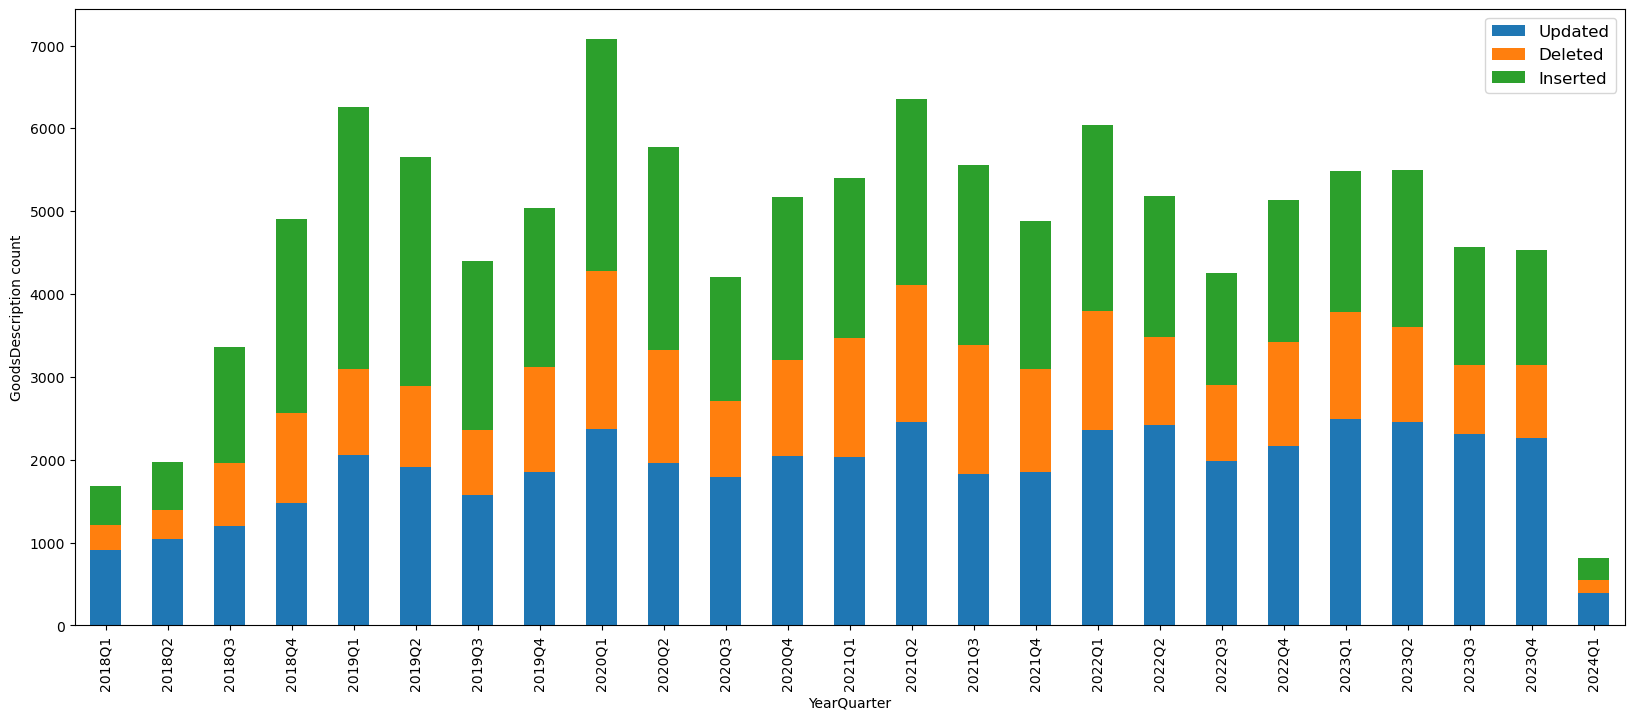

In [37]:
bram2ts(df_ba, "Line.GoodsDescription").T.plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("GoodsDescription count")
plt.xlabel("YearQuarter")
plt.legend(loc=None, labels=('Updated', 'Deleted', 'Inserted'), fontsize=12);

The contingency matrix breakdown by Broker/Importer:

In [38]:
bram2cmperbr(df_ba, "Line.GoodsDescription", True)

,Updated,Deleted,Inserted,None2None,Total
Broker,,,,,
"""K"" LINE LOGISTICS (AUSTRALIA) PTY LIMITED",22.0,19.0,20.0,NaN,61.0
20CUBE LOGISTICS PTY LTD,124.0,140.0,169.0,NaN,433.0
21ST ORDNANCE COMPANY (EOD WMD),1.0,NaN,NaN,NaN,1.0
24 CUSTOMS PTY. LTD.,4.0,2.0,2.0,NaN,8.0
3D LOGISTICS PTY LTD,178.0,119.0,171.0,NaN,468.0
...,...,...,...,...,...
WORLD WIDE SHIPPING SERVICES PTY LTD,1.0,NaN,NaN,NaN,1.0
WORLDWIDE CUSTOMS & FORWARDING AGENTS PTY LTD,15.0,12.0,13.0,NaN,40.0
YAFE PTY. LTD.,3.0,NaN,1.0,NaN,4.0


Showing the breakdown for the top 16 of these:

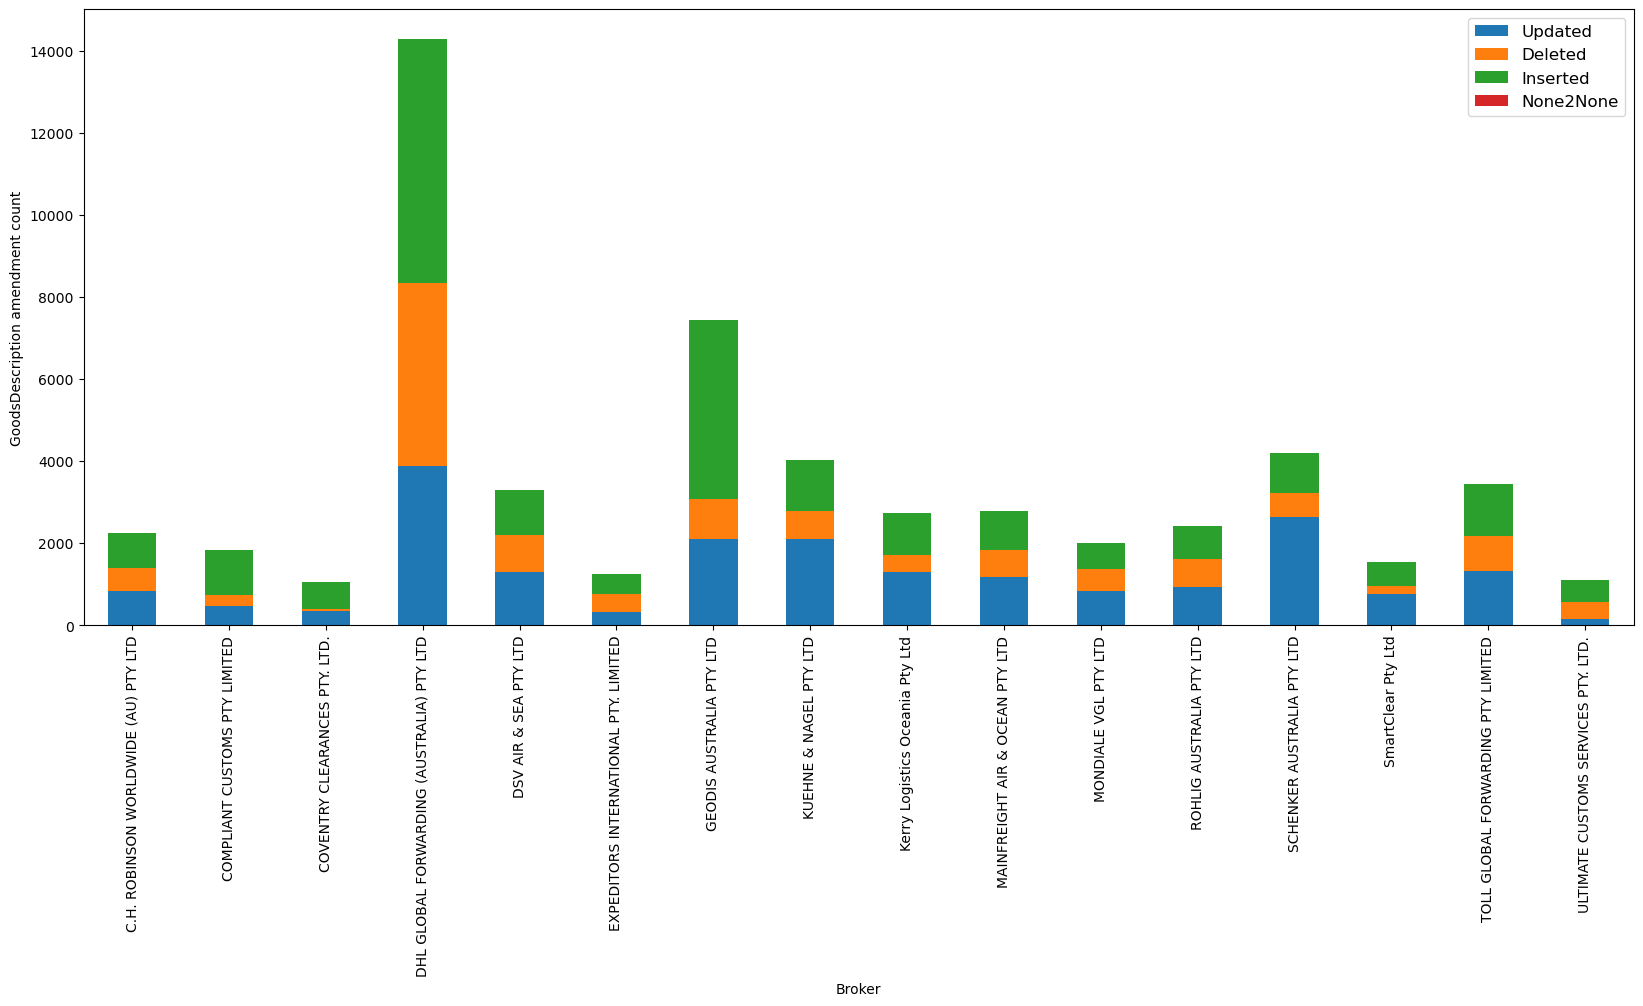

In [39]:
bram2cmperbr(df_ba, "Line.GoodsDescription", True).query('Total > 1_000').drop(columns='Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("GoodsDescription amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12);

#### Line.StatsNum amendments

Due to the large number of values Before/After_amendment in the category we first look at the "mesoscopic" breakdown.
The 2x2 contingency table shows 31.3k "Updates", followed by 43.2k "Insertions" and 25.8k "Deletions".

The timeseries:

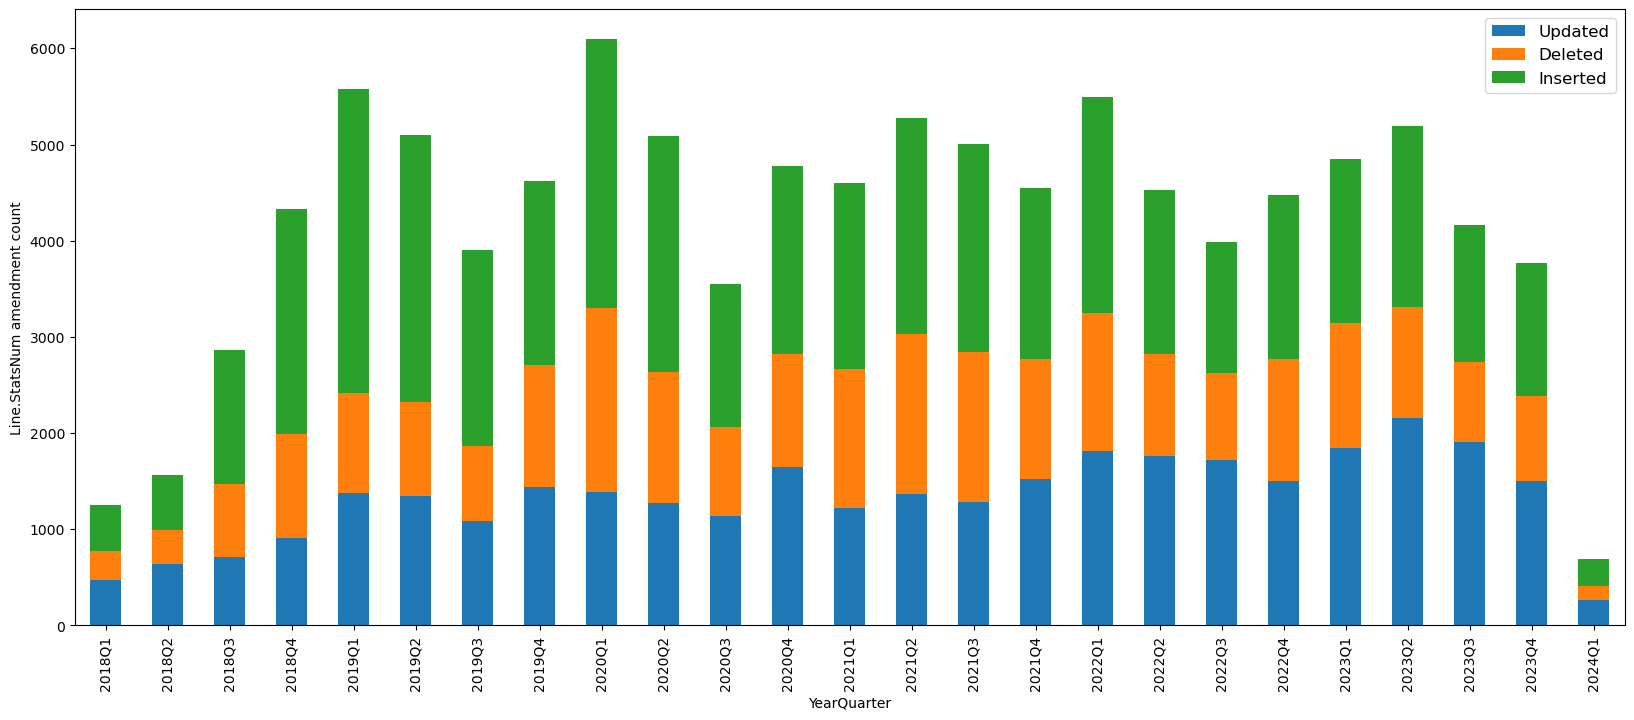

In [40]:
bram2ts(df_ba, "Line.StatsNum").T.plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("Line.StatsNum amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc=None, labels=('Updated', 'Deleted', 'Inserted'), fontsize=12);

The contigency table per Broker/Importer:

In [41]:
bram2cmperbr(df_ba, "Line.StatsNum", True)

,Updated,Deleted,Inserted,None2None,Total
Broker,,,,,
"""K"" LINE LOGISTICS (AUSTRALIA) PTY LIMITED",6.0,19.0,20.0,NaN,45.0
20CUBE LOGISTICS PTY LTD,95.0,140.0,169.0,NaN,404.0
24 CUSTOMS PTY. LTD.,4.0,2.0,2.0,NaN,8.0
3D LOGISTICS PTY LTD,142.0,119.0,171.0,NaN,432.0
3SIXTY5 FREIGHT AND CUSTOMS PTY LTD,8.0,7.0,5.0,NaN,20.0
...,...,...,...,...,...
WORLD CUSTOMS CONSULTANTS PTY LTD,28.0,13.0,8.0,NaN,49.0
WORLDWIDE CUSTOMS & FORWARDING AGENTS PTY LTD,5.0,12.0,13.0,NaN,30.0
YAFE PTY. LTD.,NaN,NaN,1.0,NaN,1.0


Showing the most prolific amenders in this category:

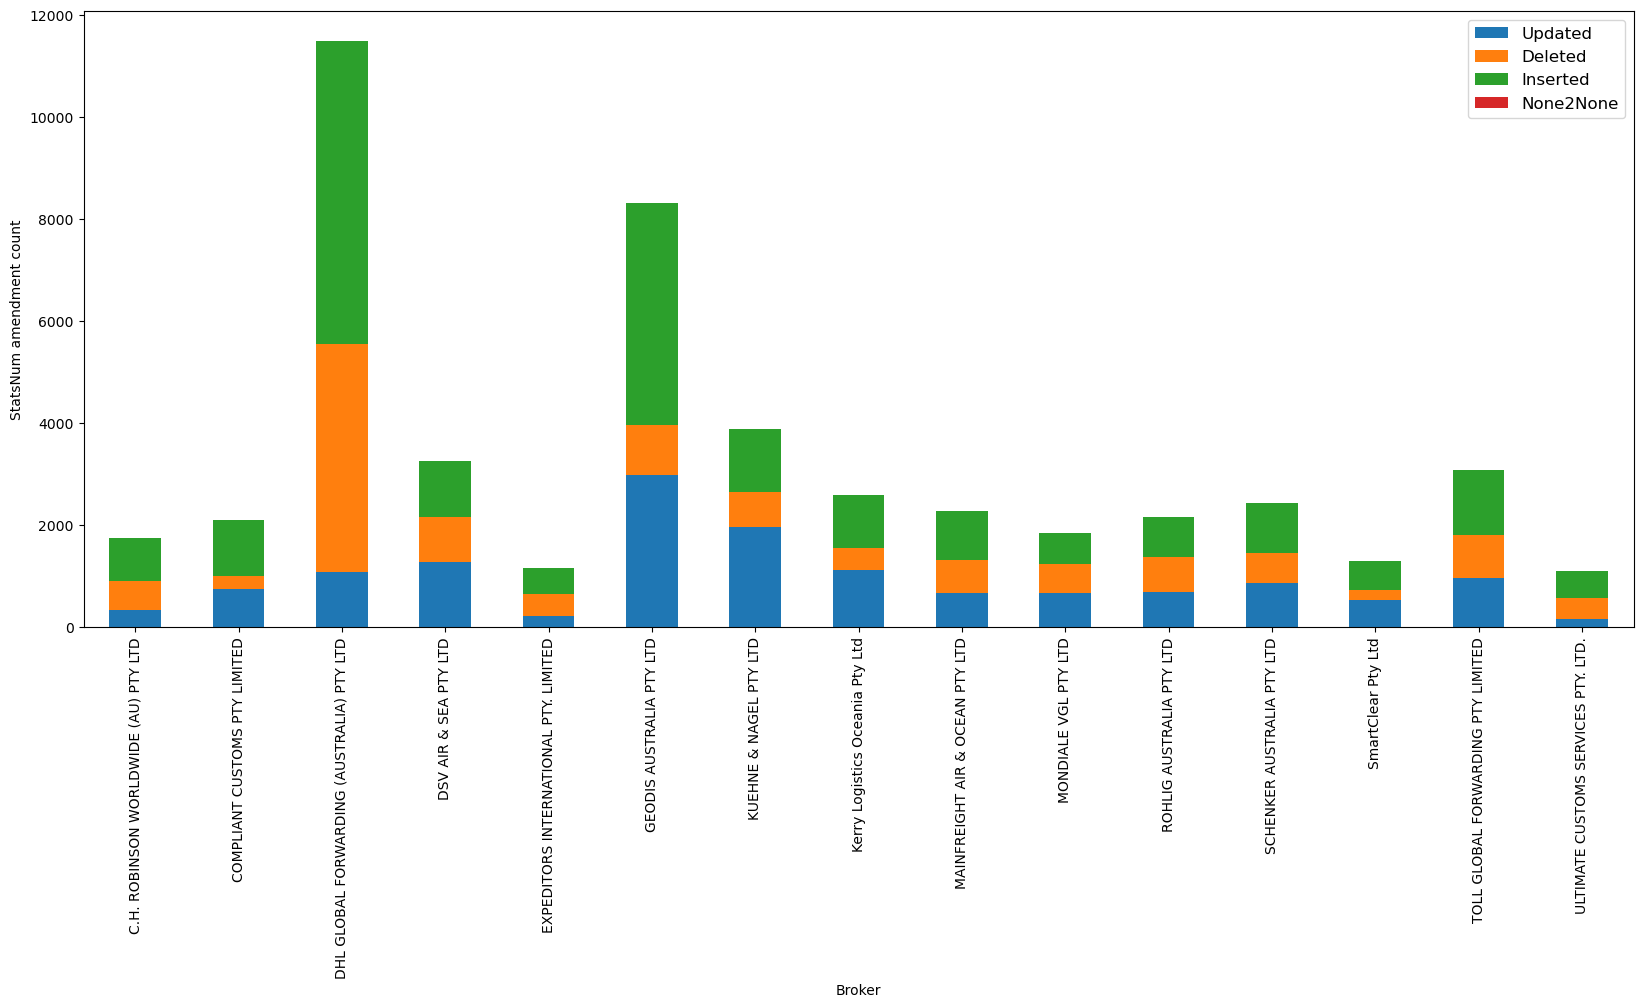

In [42]:
bram2cmperbr(df_ba, "Line.StatsNum", True).query('Total > 1_000').drop(columns='Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("StatsNum amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12);

Now attempting to take a "microscopic" view of StatsNum amendments:

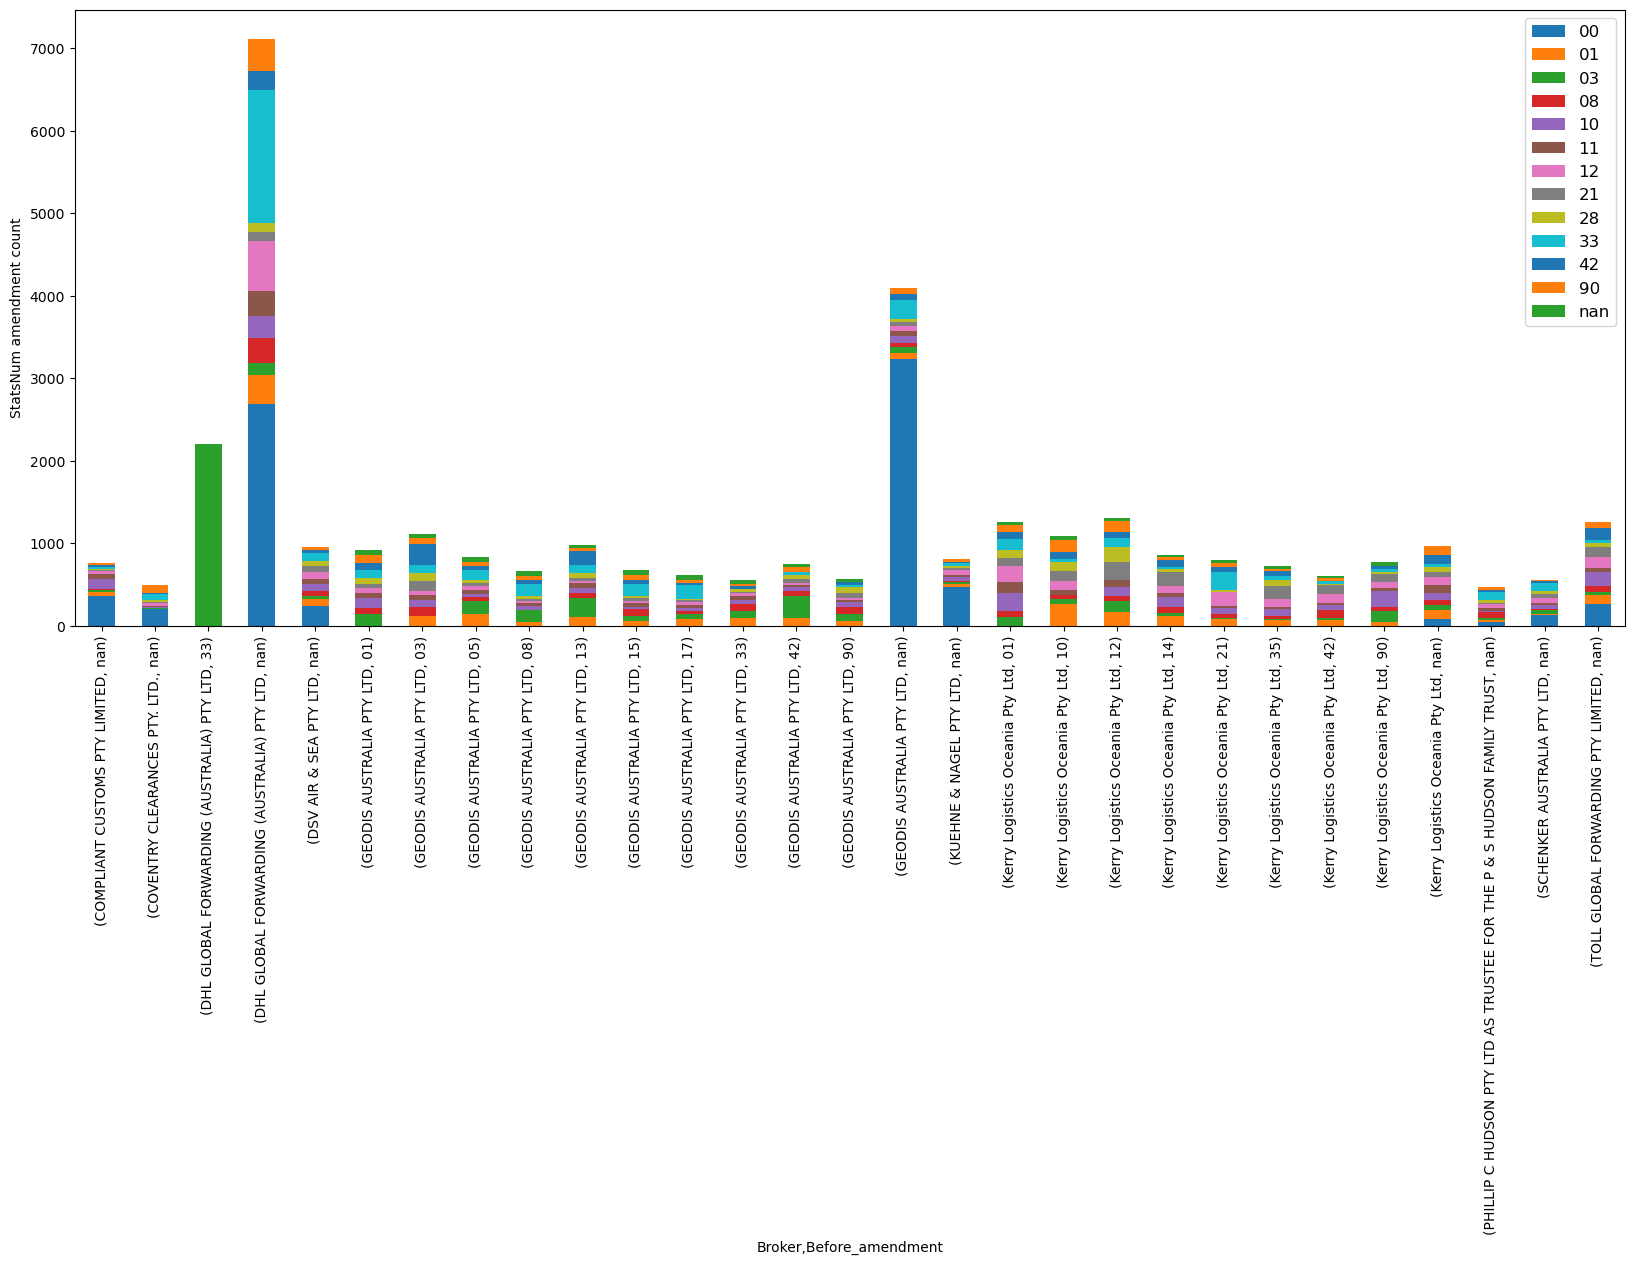

In [43]:
bram2fullcmpb(df_ba, "Line.StatsNum", 2_000, 7_000).drop(columns='After_am_Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("StatsNum amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12);

#### Line.TariffNum amendments

This category always appear like a mirror image of the StatsNum. However it is more granular (likely because the ABS aggregates different tariff numbers into a smaller set of Stats numbers).

Due to the large number of values Before/After_amendment in the category we first look at the "mesoscopic" breakdown.
The 2x2 contingency table shows 29.6k "Updates", followed by 43.2k "Insertions" and 25.8k "Deletions".

We see very similar patterns in the timeseries as in the StatsNum above:

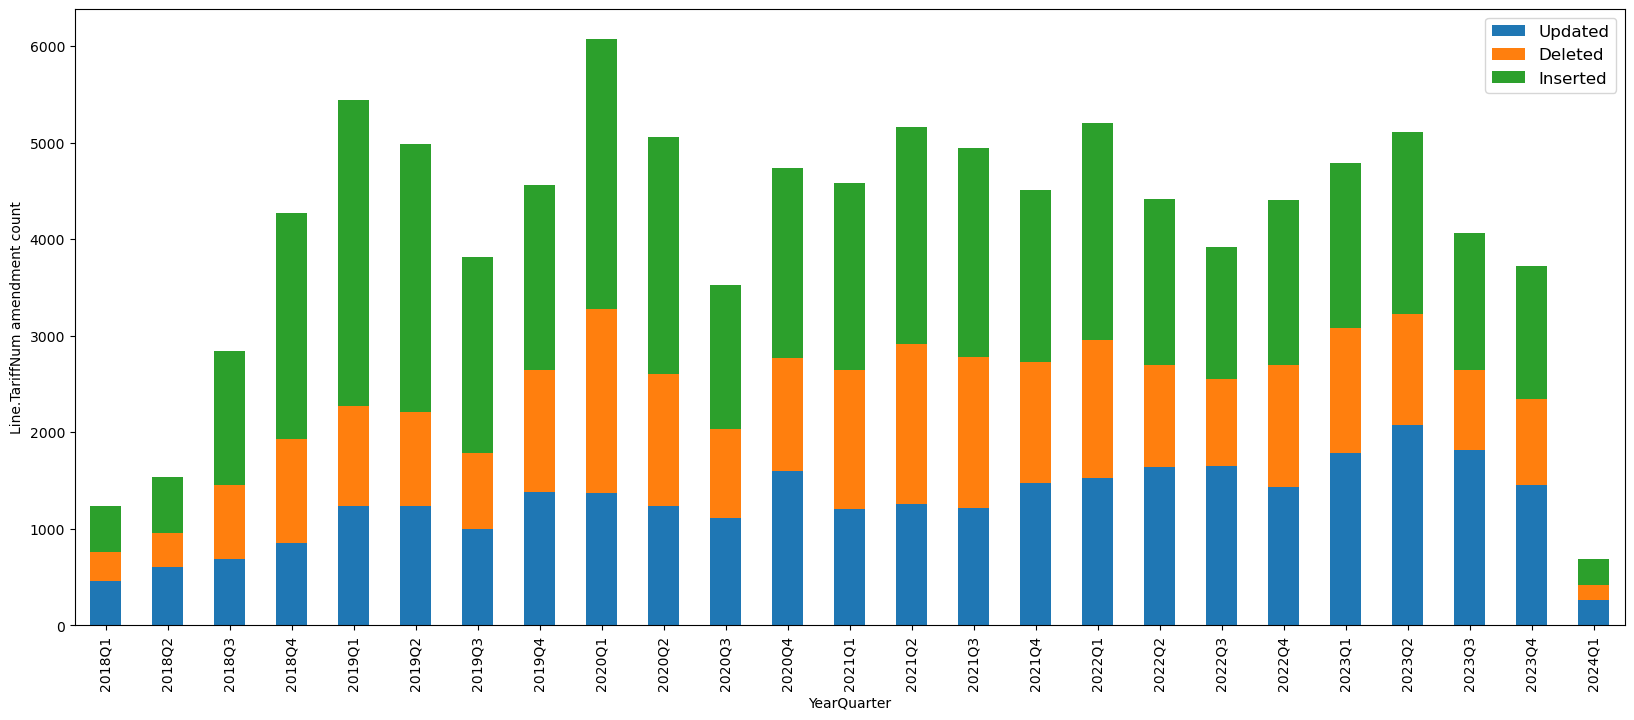

In [44]:
bram2ts(df_ba, "Line.TariffNum").T.plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("Line.TariffNum amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc=None, labels=('Updated', 'Deleted', 'Inserted'), fontsize=12);

Per Broker breakdown:

In [45]:
bram2cmperbr(df_ba, "Line.TariffNum", True)

,Updated,Deleted,Inserted,None2None,Total
Broker,,,,,
"""K"" LINE LOGISTICS (AUSTRALIA) PTY LIMITED",4.0,19.0,20.0,NaN,43.0
20CUBE LOGISTICS PTY LTD,94.0,140.0,169.0,NaN,403.0
24 CUSTOMS PTY. LTD.,4.0,2.0,2.0,NaN,8.0
3D LOGISTICS PTY LTD,138.0,119.0,171.0,NaN,428.0
3SIXTY5 FREIGHT AND CUSTOMS PTY LTD,7.0,7.0,5.0,NaN,19.0
...,...,...,...,...,...
WORLD CUSTOMS CONSULTANTS PTY LTD,28.0,13.0,8.0,NaN,49.0
WORLDWIDE CUSTOMS & FORWARDING AGENTS PTY LTD,5.0,12.0,13.0,NaN,30.0
YAFE PTY. LTD.,NaN,NaN,1.0,NaN,1.0


The top contributions:

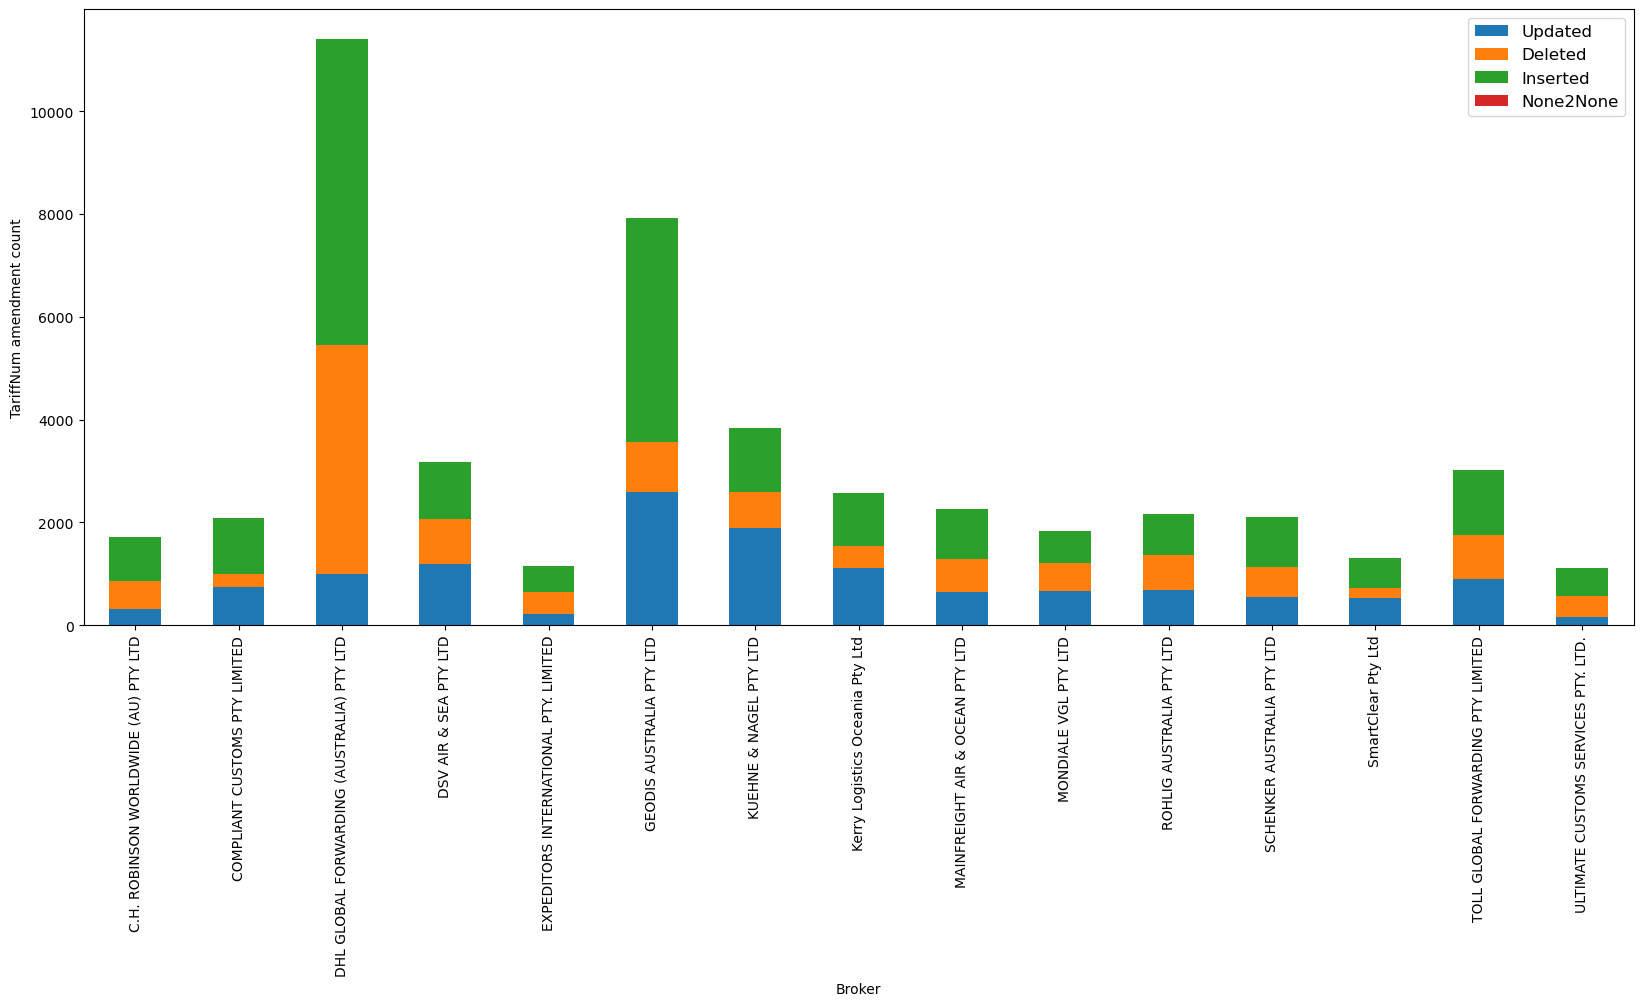

In [46]:
bram2cmperbr(df_ba, "Line.TariffNum", True).query('Total > 1_000').drop(columns='Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("TariffNum amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12);

Now attempting to take a "microscopic" view of TariffNum amendments:

In [48]:
top_TNA = bram2cmperbr(df_ba, "Line.TariffNum").query('(Before_amendment == False) & (After_am_False > 500)')
top_TNA.set_index('Broker')

,Before_amendment,After_am_False,After_am_True
Broker,,,
COMPLIANT CUSTOMS PTY LIMITED,False,740.0,264.0
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,False,990.0,4471.0
DSV AIR & SEA PTY LTD,False,1189.0,886.0
GEODIS AUSTRALIA PTY LTD,False,2591.0,976.0
KUEHNE & NAGEL PTY LTD,False,1899.0,688.0
Kerry Logistics Oceania Pty Ltd,False,1112.0,427.0
MAINFREIGHT AIR & OCEAN PTY LTD,False,641.0,654.0
MONDIALE VGL PTY LTD,False,662.0,554.0
ROHLIG AUSTRALIA PTY LTD,False,684.0,686.0


Due to the large number of values in TariffNum categories we must restrict the Brokers to the top dozen in the set shown above.

In [49]:
topTNABr = top_TNA.query('After_am_False > 500')['Broker'].to_list()

row_ser = bram2contab(df_ba, "Line.TariffNum", True).sum(axis=0) > 1000
col_ser = bram2contab(df_ba, "Line.TariffNum", True).sum(axis=1) > 1000

top_tariffs = set(row_ser.index[row_ser]).intersection(set(col_ser.index[col_ser]))
top_tariffs.add(np.nan)

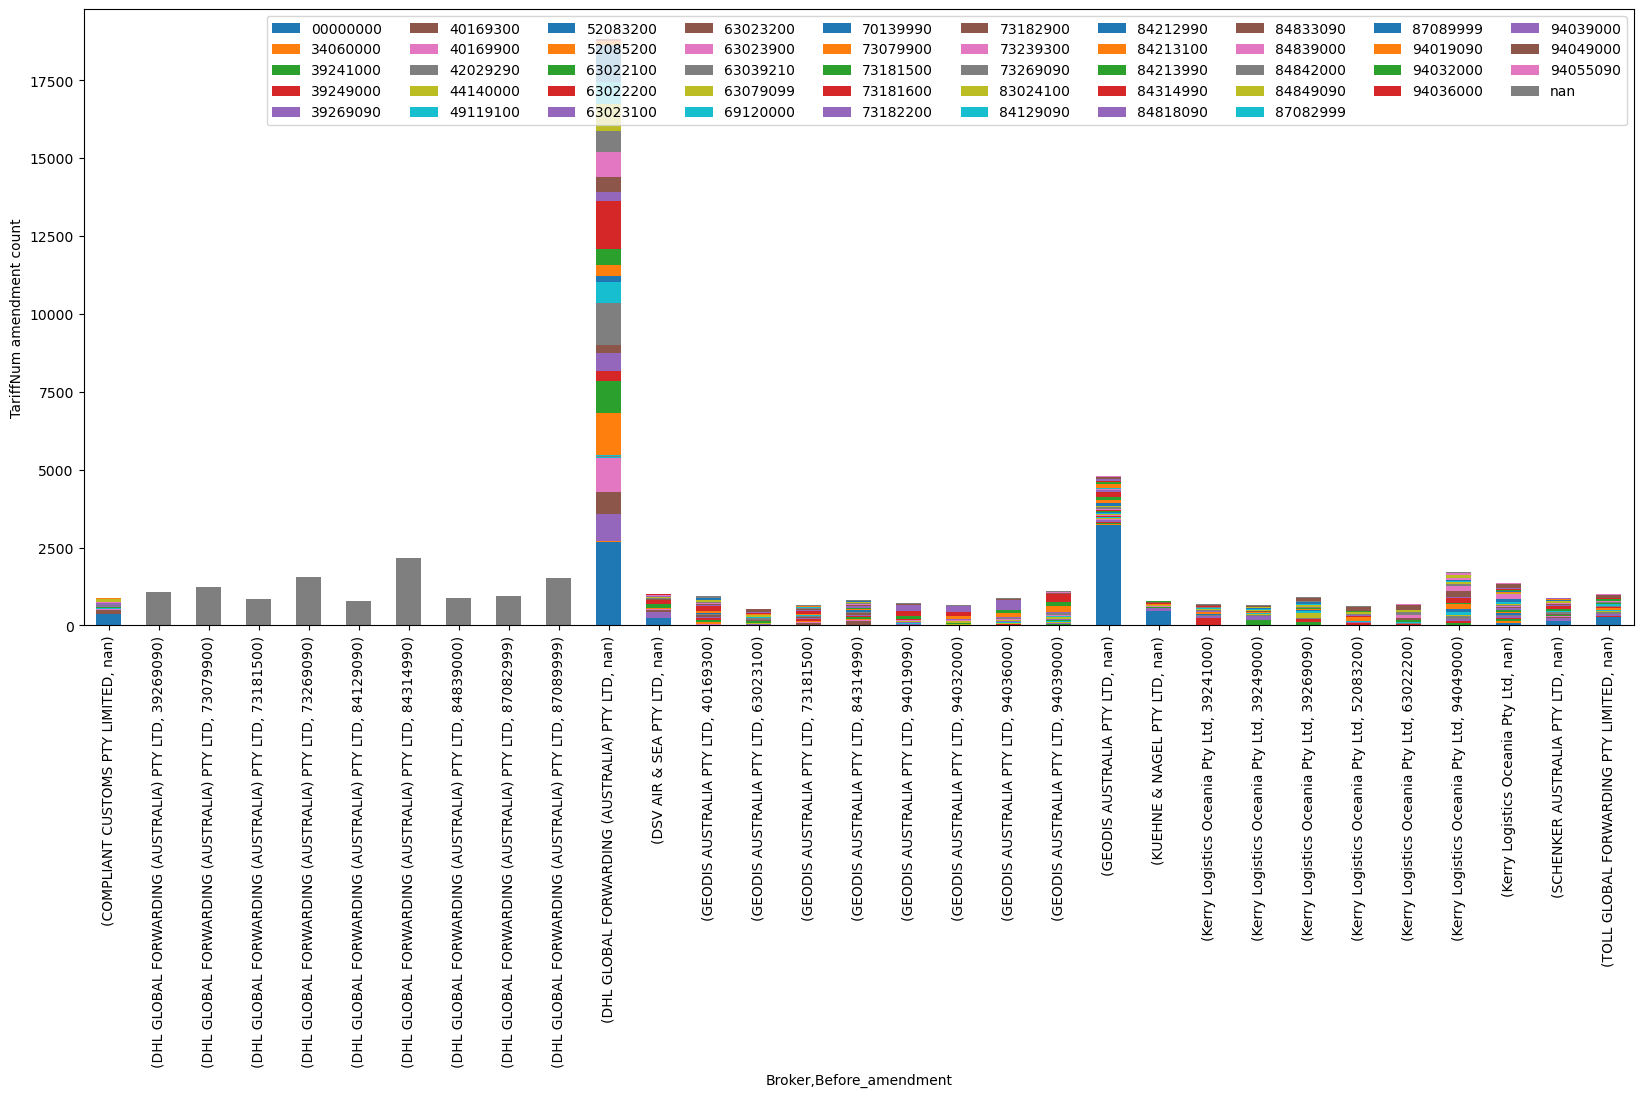

In [50]:
bram2fullcmpb(df_ba.query("(Broker in @topTNABr) & (Before_amendment in @top_tariffs) & (After_amendment in @top_tariffs)"), "Line.TariffNum", 750, 750)\
    .drop(columns='After_am_Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("TariffNum amendment count")
plt.xticks(rotation = 90);
plt.legend(loc="upper right", fontsize=10, ncol=10);

#### CountryCode amendments

Due to the large number of values Before/After_amendment in the category we first look at the "mesoscopic" breakdown.
The 2x2 contingency table shows 13.4k "Updates", 43.2k "Insertions" and 25.8k "Deletions".

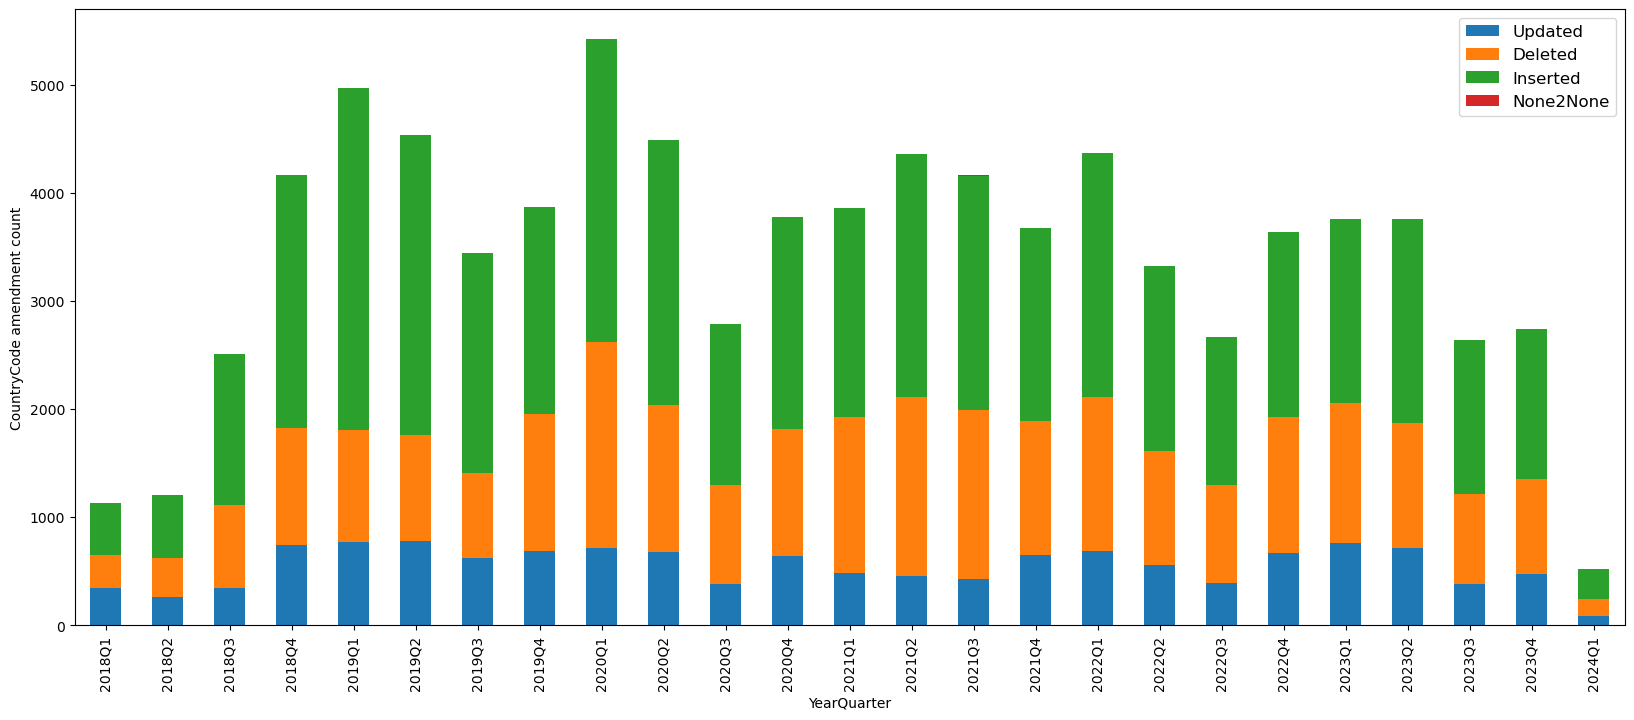

In [51]:
bram2ts(df_ba, "LineCountry.CountryCode").T.plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("CountryCode amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc=None, labels=('Updated', 'Deleted', 'Inserted', "None2None"), fontsize=12);

Per Broker breakdown:

In [52]:
bram2cmperbr(df_ba, "LineCountry.CountryCode", True)

,Updated,Deleted,Inserted,None2None,Total
Broker,,,,,
"""K"" LINE LOGISTICS (AUSTRALIA) PTY LIMITED",14.0,19.0,20.0,NaN,53.0
20CUBE LOGISTICS PTY LTD,48.0,140.0,169.0,NaN,357.0
24 CUSTOMS PTY. LTD.,NaN,2.0,2.0,NaN,4.0
3D LOGISTICS PTY LTD,58.0,119.0,171.0,NaN,348.0
3SIXTY5 FREIGHT AND CUSTOMS PTY LTD,1.0,7.0,5.0,NaN,13.0
...,...,...,...,...,...
WORLD CUSTOMS CONSULTANTS PTY LTD,1.0,13.0,8.0,NaN,22.0
WORLDWIDE CUSTOMS & FORWARDING AGENTS PTY LTD,1.0,12.0,13.0,NaN,26.0
YAFE PTY. LTD.,1.0,NaN,1.0,NaN,2.0


Showing the top contributors:

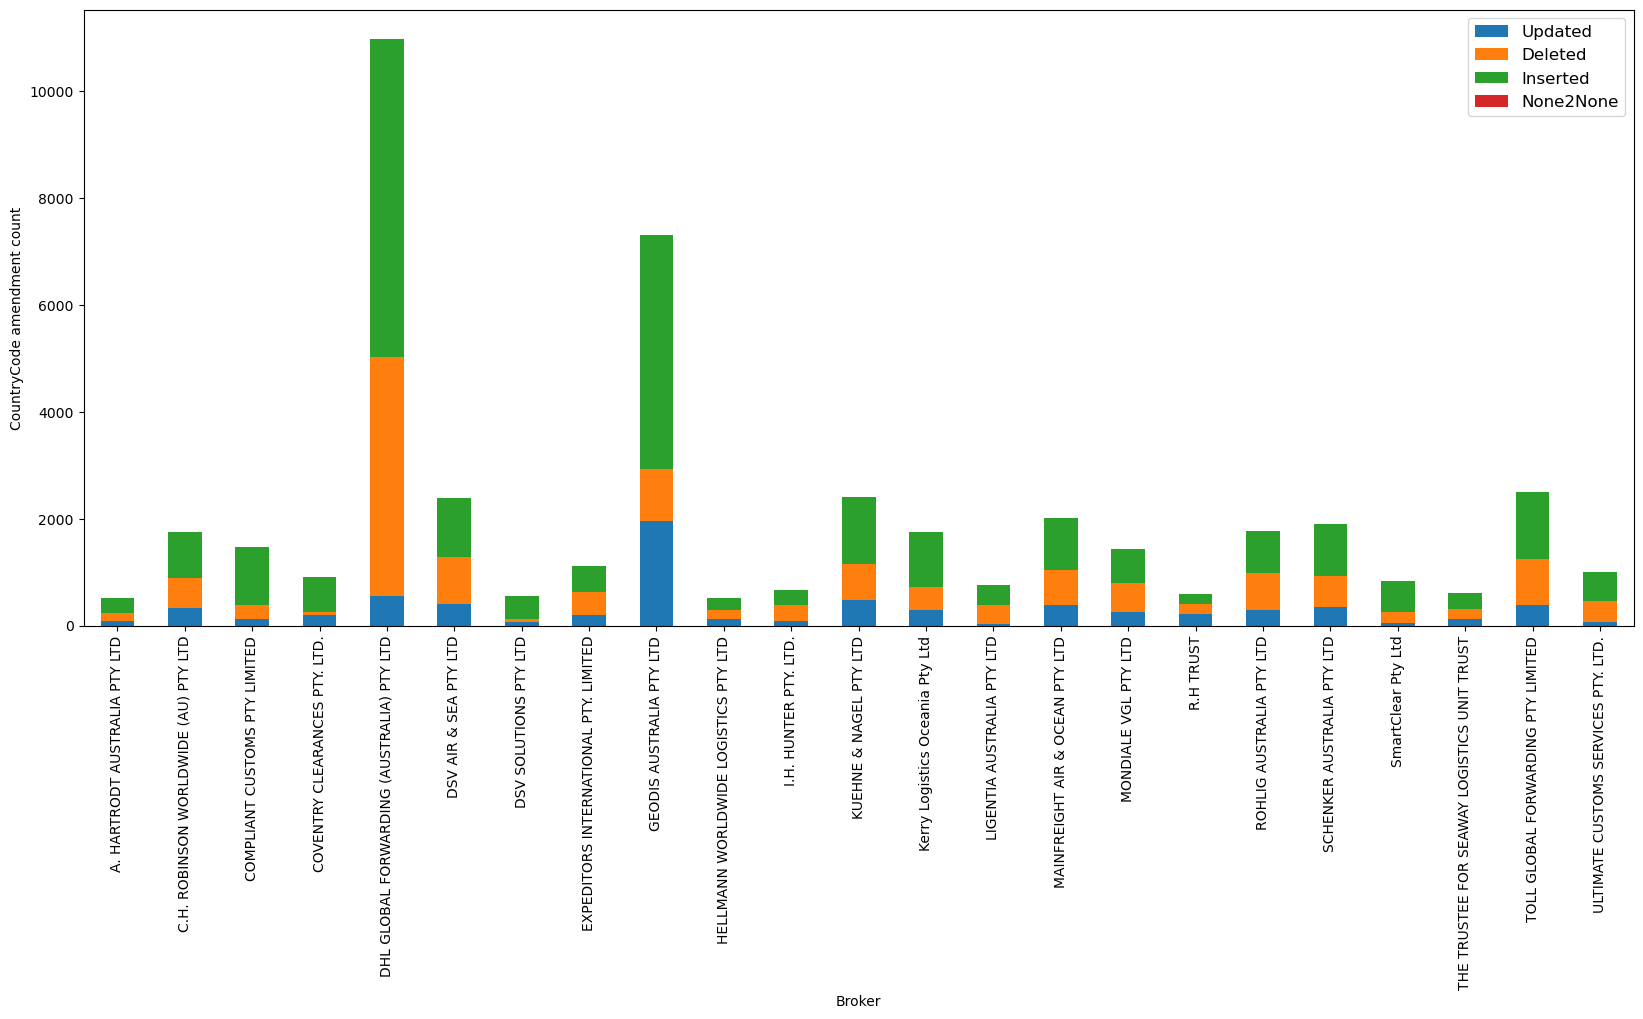

In [53]:
bram2cmperbr(df_ba, "LineCountry.CountryCode", True).query('Total > 500').drop(columns='Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("CountryCode amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12);

In [55]:
topCCA = bram2fullcmpb(df_ba, "LineCountry.CountryCode", 1_000, 1_000)
with pd.option_context('display.max_columns', None): 
    display(topCCA)

BE    CA  \
Broker                                    Before_amendment                
C.H. ROBINSON WORLDWIDE (AU) PTY LTD      NaN                24.0  31.0   
COMPLIANT CUSTOMS PTY LIMITED             NaN                71.0   5.0   
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD CN                  2.0   1.0   
                                          MX                  NaN   1.0   
                                          US                  NaN   8.0   
                                          NaN               100.0  76.0   
DSV AIR & SEA PTY LTD                     NaN                29.0  35.0   
GEODIS AUSTRALIA PTY LTD                  CN                 11.0   6.0   
                                          CZ                 10.0   5.0   
                                          DE                 35.0  26.0   
                                          FR                  4.0  11.0   
                                          GB                 17.0   6.0   
                                          IN                  9.0   3.0   
                                          IT                 22.0  14.0   
                                          PL                 11.0   7.0   
                                          RO                  4.0   1.0   
                                          SE                 29.0  21.0   
                                          SK                  3.0   2.0   
                                          TH                  2.0   NaN   
                                          TR                  3.0   1.0   
                                          TW                  9.0   7.0   
                                          US                  9.0  34.0   
                                          VN                  1.0   NaN   
                                          NaN                61.0  17.0   
KUEHNE & NAGEL PTY LTD                    NaN                28.0   6.0   
Kerry Logistics Oceania Pty Ltd           NaN                 7.0   2.0   
MAINFREIGHT AIR & OCEAN PTY LTD           NaN                33.0  18.0   
ROHLIG AUSTRALIA PTY LTD                  NaN                13.0   8.0   
SCHENKER AUSTRALIA PTY LTD                NaN                21.0   8.0   
TOLL GLOBAL FORWARDING PTY LIMITED        NaN                 5.0  26.0   

                                                                CN     CZ  \
Broker                                    Before_amendment                  
C.H. ROBINSON WORLDWIDE (AU) PTY LTD      NaN                102.0    6.0   
COMPLIANT CUSTOMS PTY LIMITED             NaN                160.0    4.0   
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD CN                   NaN    3.0   
                                          MX                   4.0    NaN   
                                          US                  40.0    NaN   
                                          NaN               1670.0   29.0   
DSV AIR & SEA PTY LTD                     NaN                191.0    5.0   
GEODIS AUSTRALIA PTY LTD                  CN                   NaN   96.0   
                                          CZ                  75.0    NaN   
                                          DE                 193.0  158.0   
                                          FR                  55.0   30.0   
                                          GB                  76.0   88.0   
                                          IN                  46.0   39.0   
                                          IT                 177.0  138.0   
                                          PL                 124.0  138.0   
                                          RO                  54.0   32.0   
                                          SE                 173.0  157.0   
                                          SK                  46.0   49.0   
                                          TH                  30.0   34.0   
                                          TR 

Now we attempt to take a more "microscopic" view of the CountryCode updates by looking at the most common value (i.e., country to country) changes.

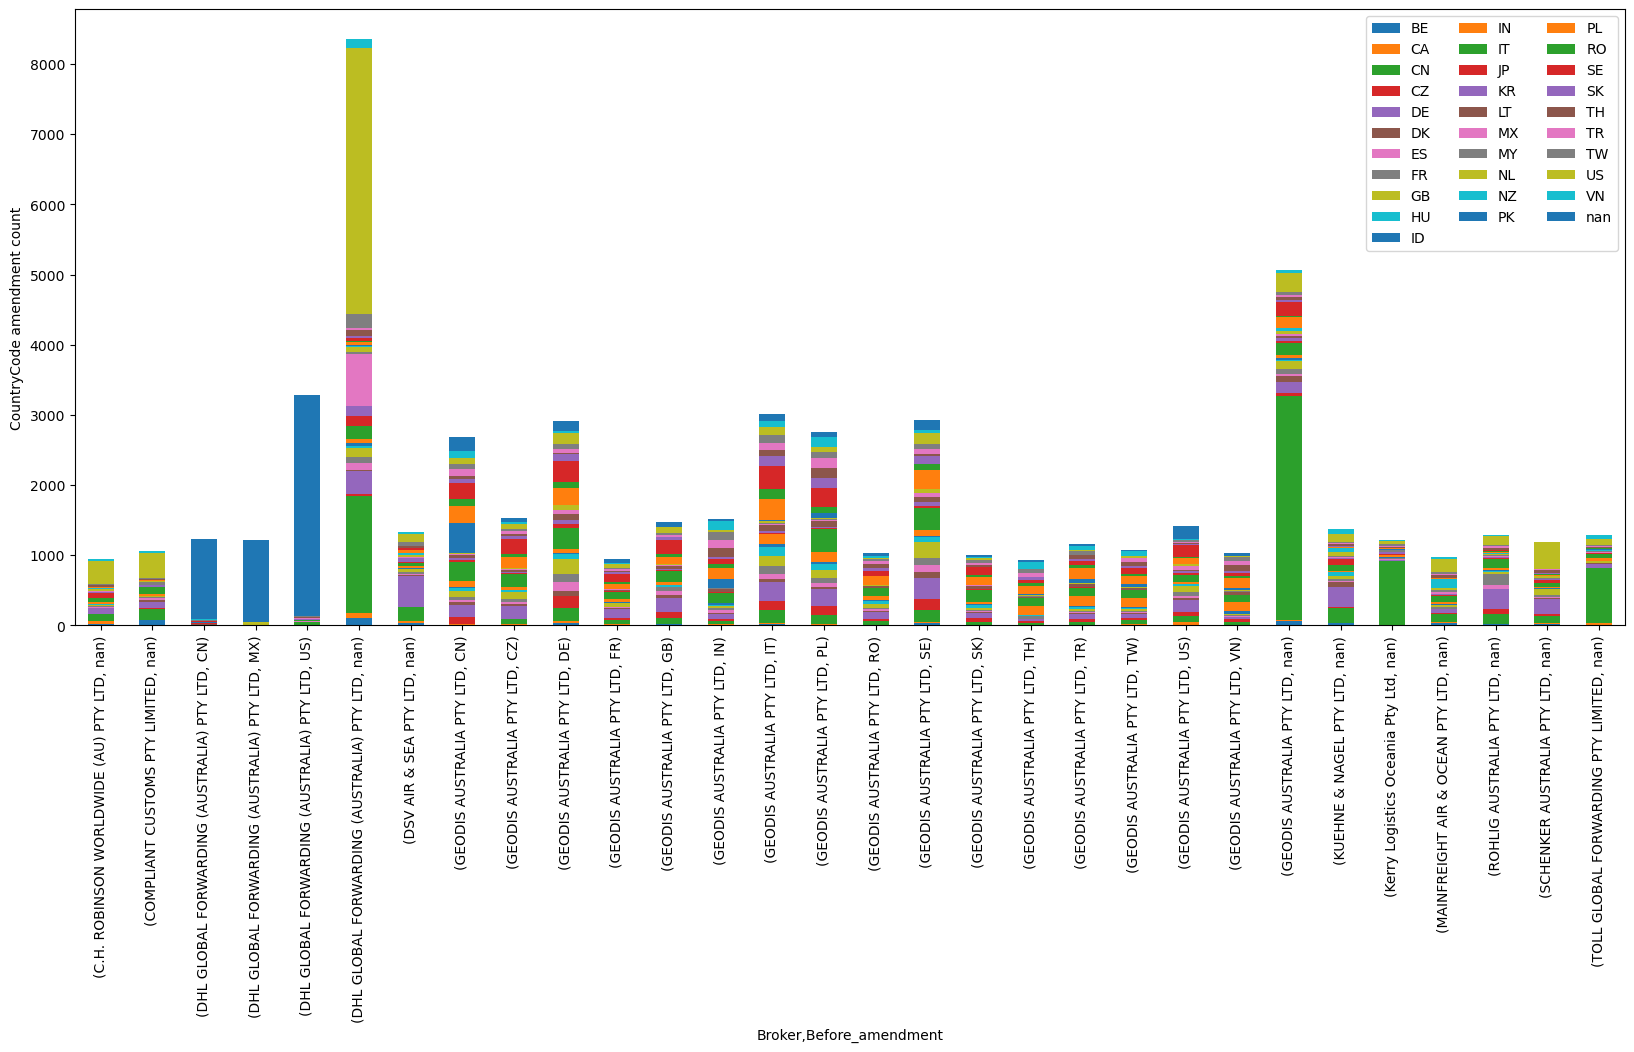

In [56]:
topCCA.drop(columns='After_am_Total').plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("CountryCode amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=10, ncol=3);

#### LineAep.AepCode amendments

In this category "Insertions" are most common, followed by Deletions, Updates and None2None, respectively.

The following contingency table provides a more detailed insight into changes:

In [58]:
bram2contab(df_ba, "LineAep.AepCode", True)

After_amendment,BMSBFUM,BMSBHT,BMSBINS,BMSBMB,BMSBREL,BMSBSF,D,FUM,INS,ND,...,RPNTXDA,RPT,RPTD,VFP,VFPA,VFPAD,XD,XD2,XDA,NaN
Before_amendment,,,,,,,,,,,,,,,,,,,,,
BMSBFUM,0,1,5,214,39,0,0,25,3,0,...,0,0,0,0,0,0,0,0,0,1574
BMSBHT,0,0,0,107,6,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,11
BMSBINS,11,0,0,46,4,0,0,2,16,0,...,0,0,0,0,0,0,0,0,0,65
BMSBMB,0,33,36,0,184,19,0,55,20,0,...,0,0,0,0,0,0,0,0,0,3425
BMSBREL,23,1,13,70,0,0,0,2,36,0,...,0,0,0,0,0,0,0,0,0,969
BMSBSF,0,0,0,11,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,27
D,0,0,0,0,0,0,0,0,0,4,...,0,10,8,0,0,0,0,0,0,351
FUM,14,0,0,90,4,0,0,0,54,0,...,0,0,0,0,0,0,0,0,0,689
INS,6,0,14,11,8,1,0,41,0,0,...,0,0,0,0,0,0,0,0,0,1827


The timeseries:

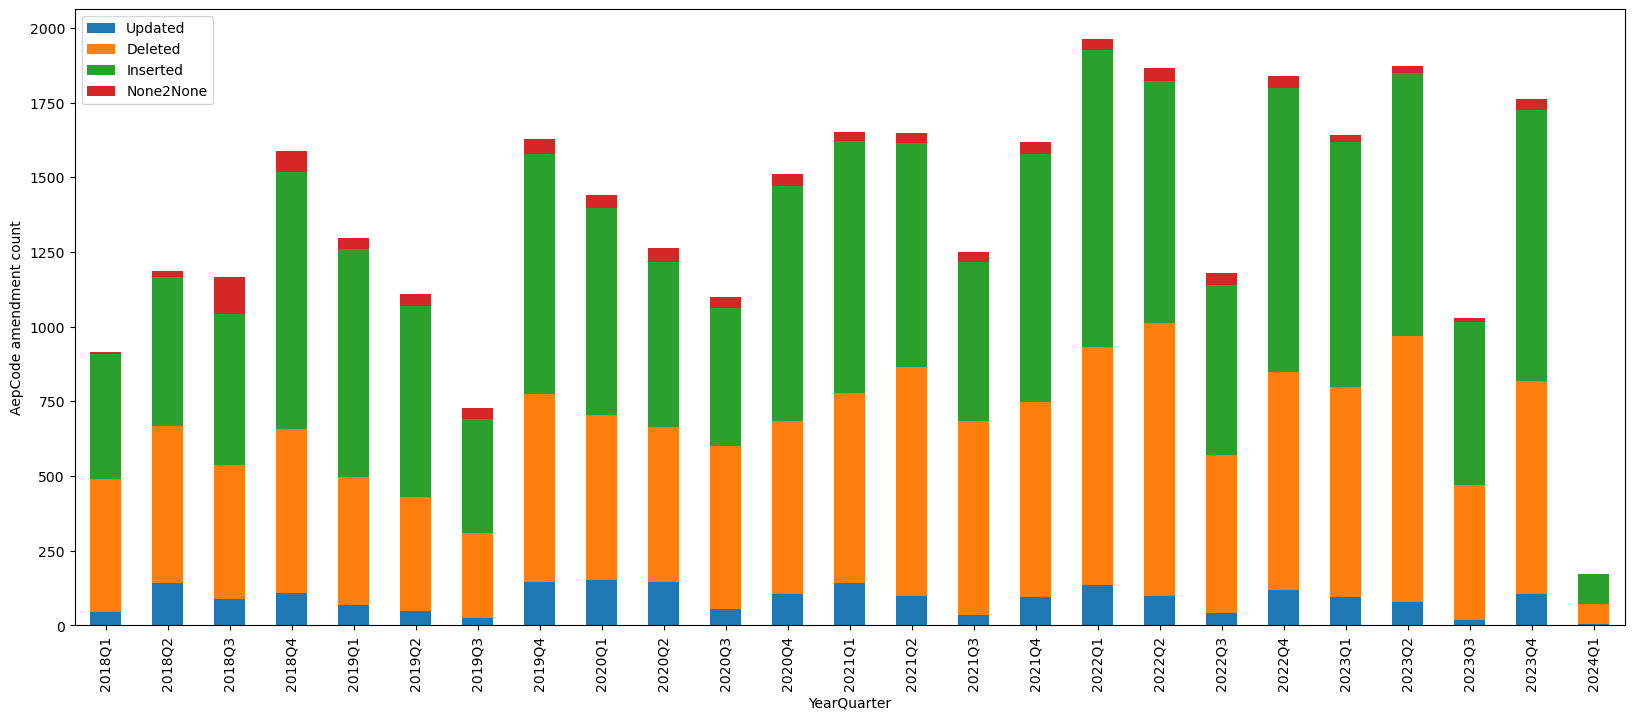

In [59]:
bram2ts(df_ba, "LineAep.AepCode", "Q").T.plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("AepCode amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc='upper left', labels=('Updated', 'Deleted', 'Inserted', "None2None"), fontsize=10, ncol=1);

A "microscopic" insight into the top amenders:

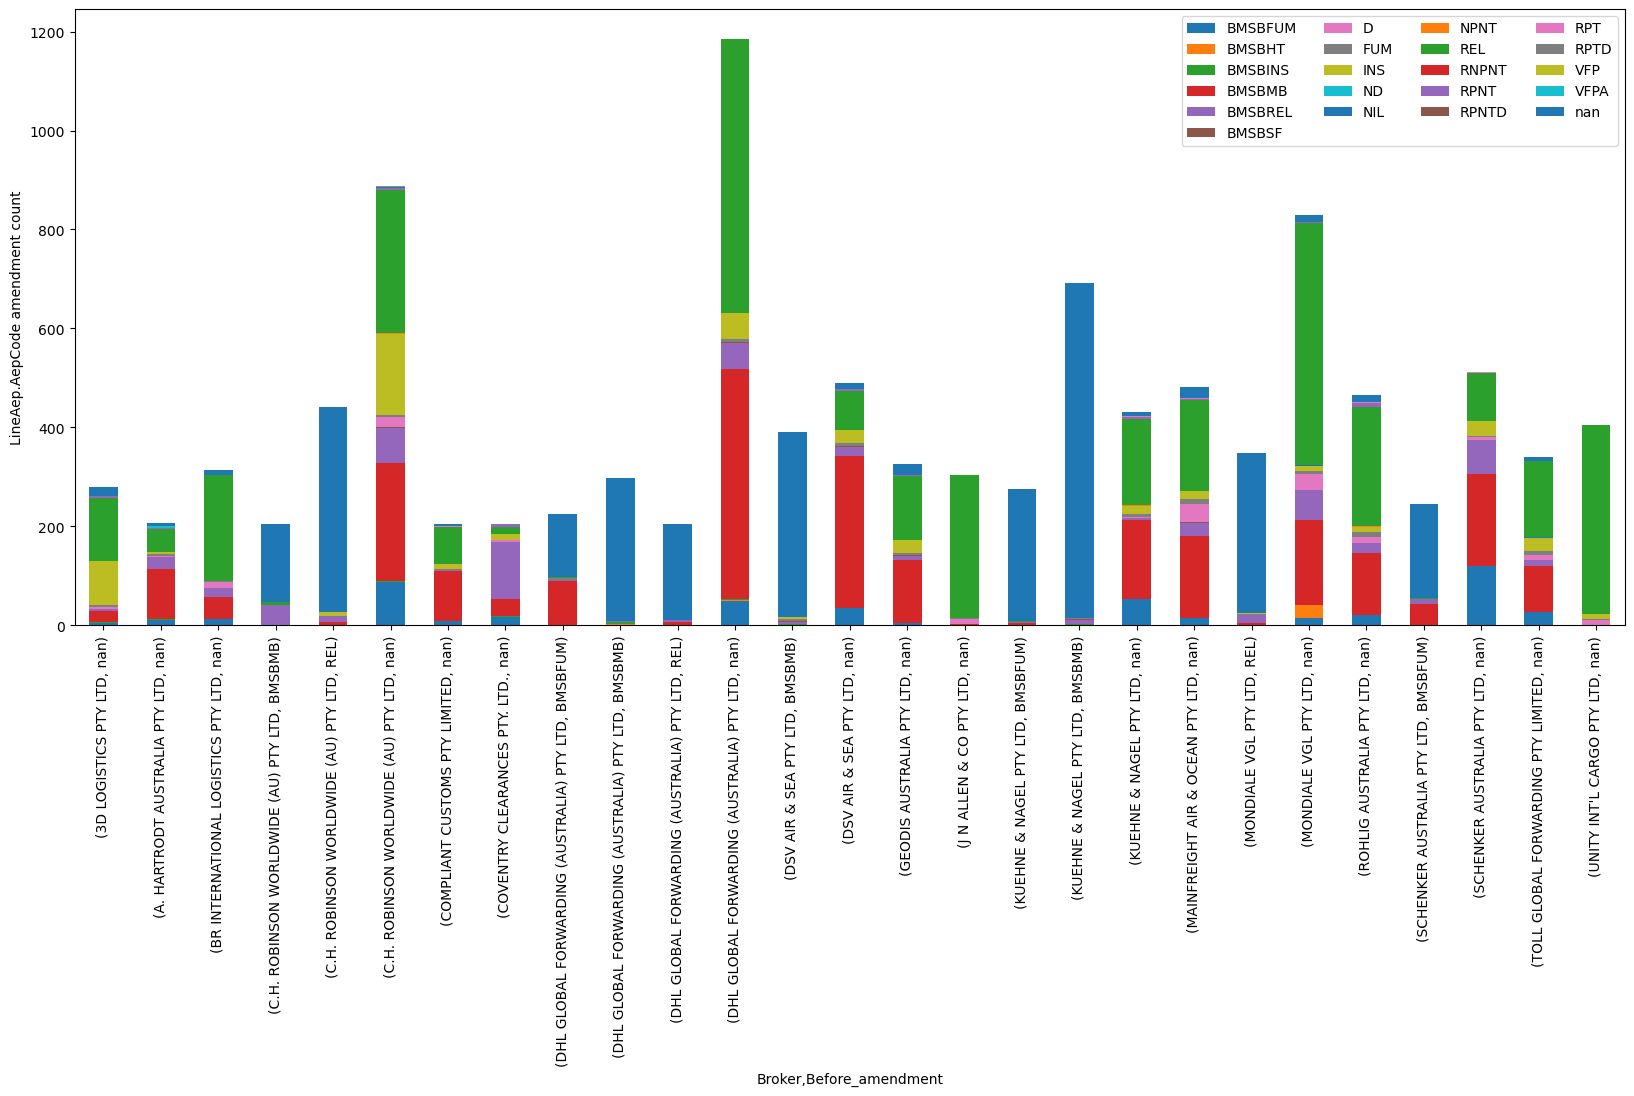

In [60]:
bram2fullcmpb(df_ba, "LineAep.AepCode", 200, 5).drop(columns='After_am_Total').plot(kind="bar", stacked=True, figsize=(20, 8), log=False)
plt.ylabel("LineAep.AepCode amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=10, ncol=4);

Note the logarithmic scale which makes the contributions at the bottom end appear more significant than they are.

#### LineCommodity.AqisCommodityCode amendments

The following contingency table provides a detailed insight into changes, the vast majority of which is found either in the last row/column (i.e., either Insertion or Deletion):

In [61]:
bram2contab(df_ba, "LineCommodity.AqisCommodityCode", True)

After_amendment,ANIM,AUST,BLUE,COCO,CORN,DATE,DWWA,FRPR,FTR1,FTR2,...,PARB,PEAT,PHNX,PMTD,POWD,PREP,TRUF,USCH,USSF,NaN
Before_amendment,,,,,,,,,,,,,,,,,,,,,
ANIM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,67
DATE,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,5
DWWA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
FTR1,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,3
FTR2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
IMMA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
LEMO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
LSTD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
MUSH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10


The timeseries:

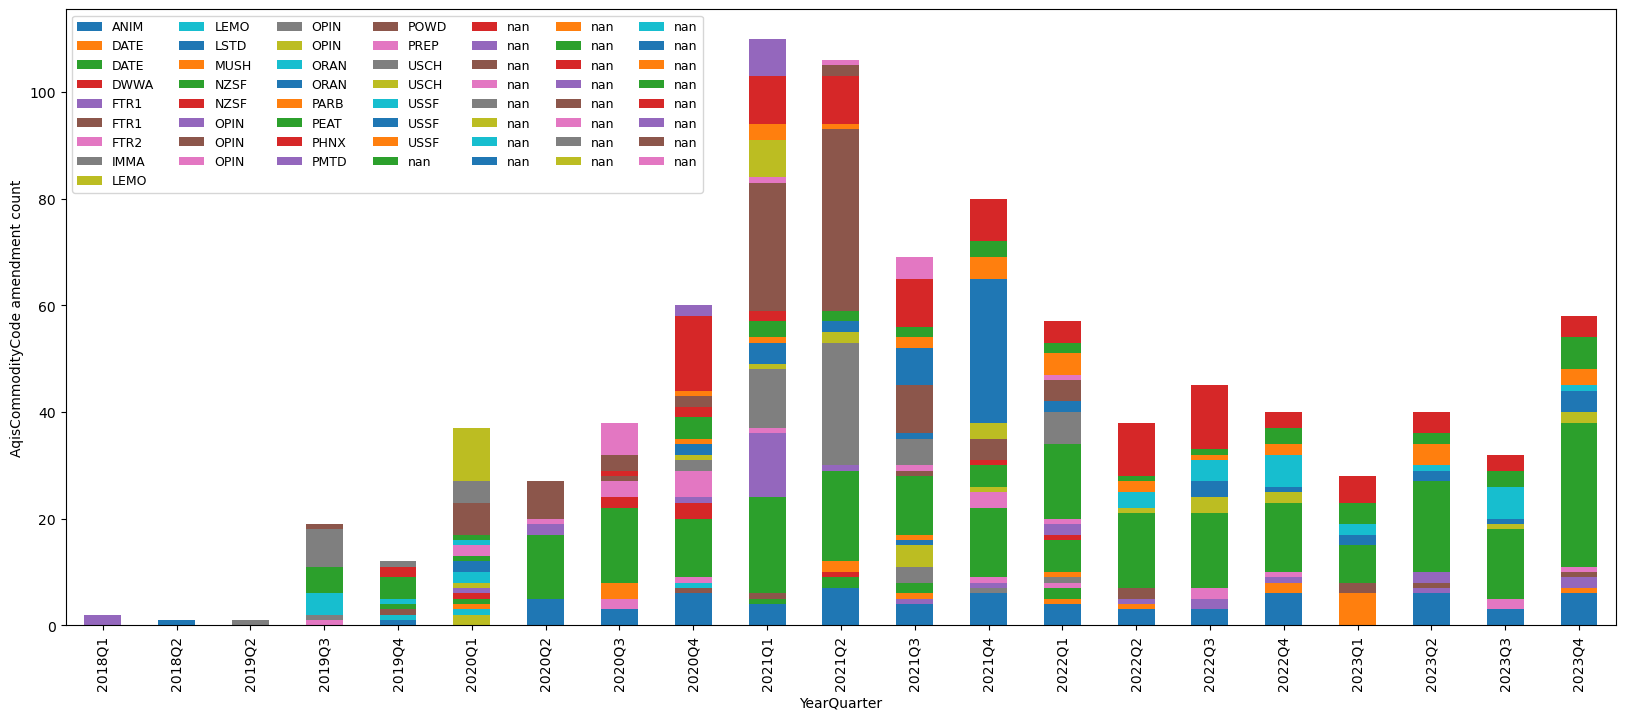

In [62]:
bram2ts(df_ba, "LineCommodity.AqisCommodityCode", "Q", True).droplevel('After_amendment').T.plot(kind="bar", stacked=True, figsize=(20, 8), log=False)
plt.ylabel("AqisCommodityCode amendment count")
plt.xlabel("YearQuarter")
plt.legend(loc='upper left', fontsize=9, ncol=7);

Discerning the stacks with highest amplitudes:

Year/quarter: 2020Q4
the RED peak amendment: (nan, 'PREP')

Year/quarter: 2021Q2
the BROWN peak amendment: (nan, 'MUSH')

Year/quarter: 2021Q4
the BLUE peak amendment: (nan, 'PEAT')

Year/quarter: 2023Q4
the GREEN peak amendment: (nan, 'ANIM')

A "microscopic" insight into the top contributors:

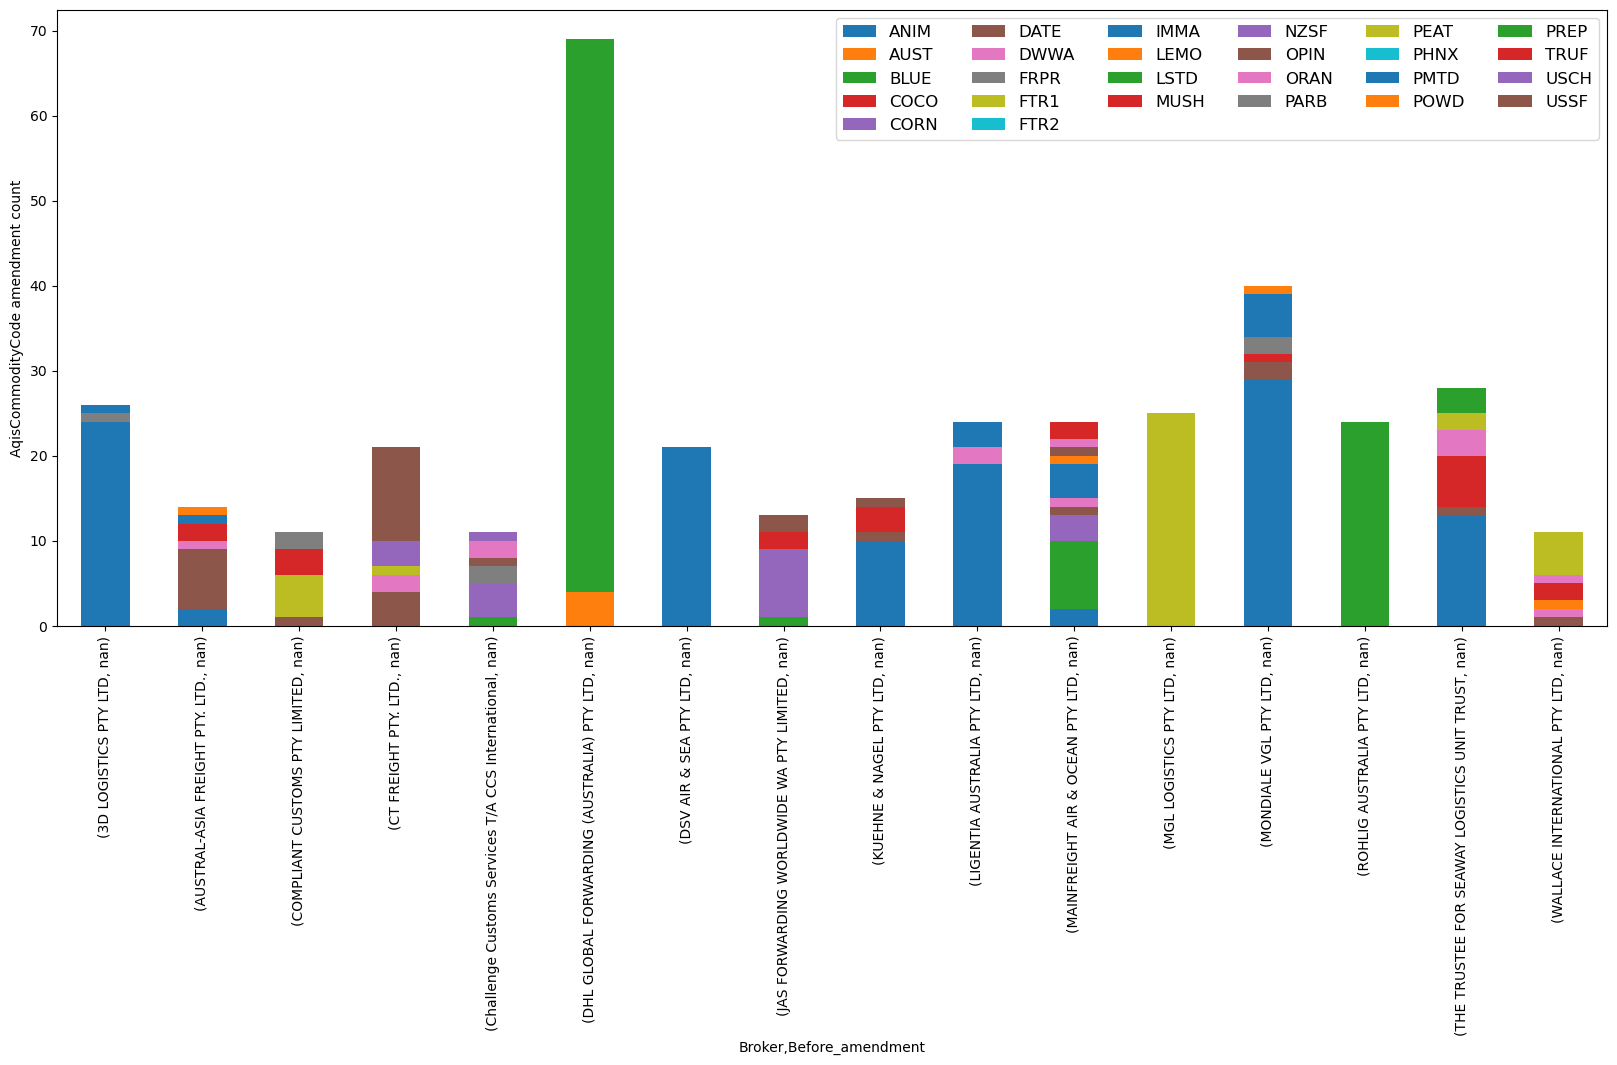

In [63]:
bram2fullcmpb(df_ba, "LineCommodity.AqisCommodityCode", 10, 0).drop(columns=['After_am_Total', np.nan]).plot(kind="bar", stacked=True, figsize=(20, 8))
plt.ylabel("AqisCommodityCode amendment count")
plt.xticks(rotation = 90);
plt.legend(loc=None, fontsize=12, ncol=6);

### Broker vs EntryID vs Amended fields

Here we explore the descriptive relationships between Brokers and the number of amended Entries and the most commonly amended categories.

About a dozen of the Brokers/Imoprters had multiple thousands of amended Entries each, while many had only a single or couple:

In [64]:
df_BrEID = df_ba.pivot_table(index='Broker', values='Entry_ID', aggfunc=pd.Series.nunique)
df_BrEID.sort_values(by='Entry_ID', ascending=False)

,Entry_ID
Broker,
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,13588
GEODIS AUSTRALIA PTY LTD,11692
KUEHNE & NAGEL PTY LTD,8477
MAINFREIGHT AIR & OCEAN PTY LTD,7049
C.H. ROBINSON WORLDWIDE (AU) PTY LTD,6666
...,...
KY PROVISIONS PTY LTD,1
SPARTAN PARKS PTY LTD,1
KADOSH PTY LTD,1


The vast majority (80%) of the 799 Brokers contributed with only 1-400 amended Entries each, while only a minority of a couple of dozen Brokers contributed to multiple thousands each:

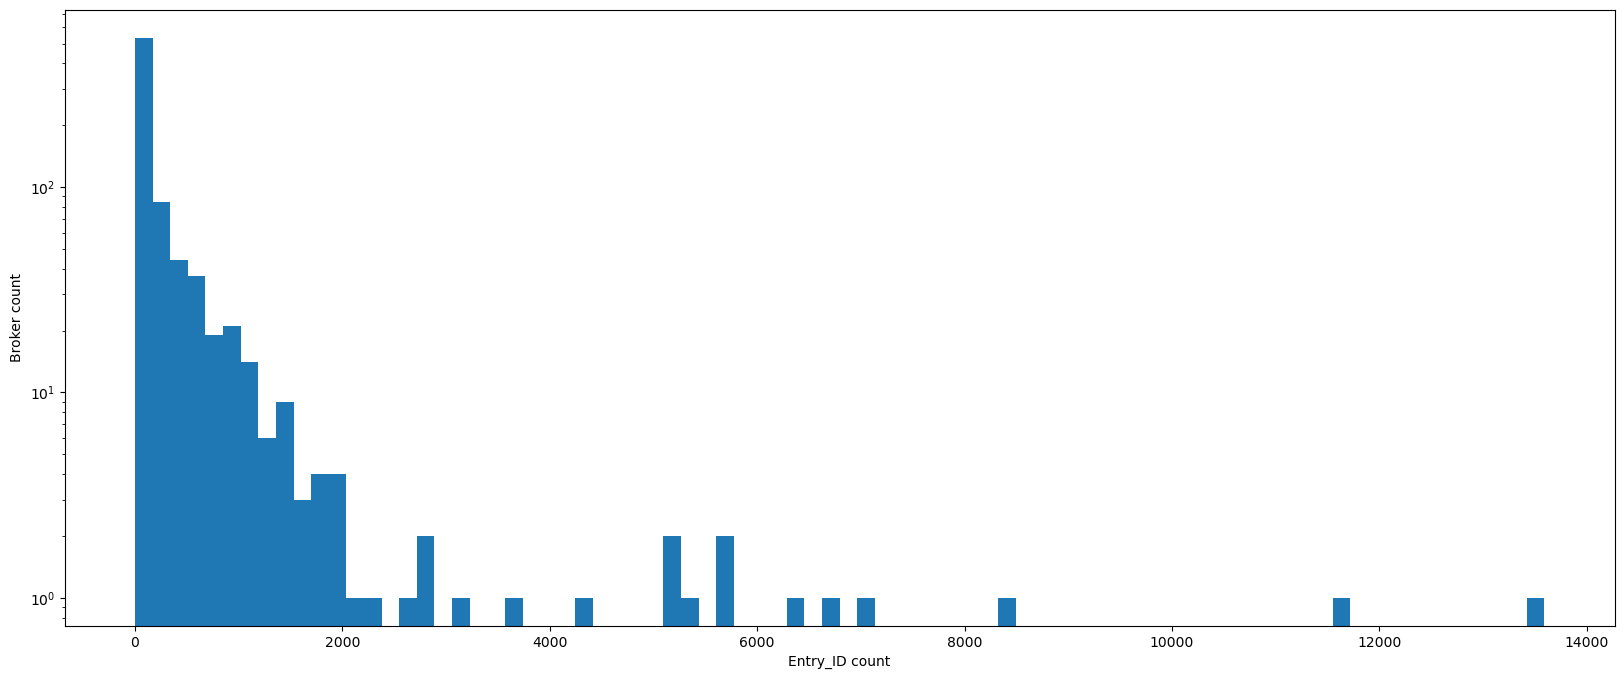

In [65]:
plt.figure(figsize=(20, 8))
plt.hist(df_BrEID['Entry_ID'], bins=80, log=True)
plt.xlabel("Entry_ID count")
plt.ylabel("Broker count");

The majority of the Entries had only a single field amended, but some of the Entrys also had multiple (up to two dozen) fields amended:

In [66]:
df_EIDAf = df_ba.pivot_table(index='Entry_ID', values='Reduced_amended_field', aggfunc=pd.Series.nunique).rename(columns={'Reduced_amended_field': 'Amended_field_count'})
df_EIDAf.sort_values(by='Amended_field_count', ascending=False)

,Amended_field_count
Entry_ID,
AEPJH4YP4,23
AEN76CHYJ,22
AETYKC9RK,21
AERATC7WF,21
AEK63M3NY,21
...,...
AEGH34TXG,1
AEGH347M9,1
AEGGYXYFJ,1


The actual distribution graphics:

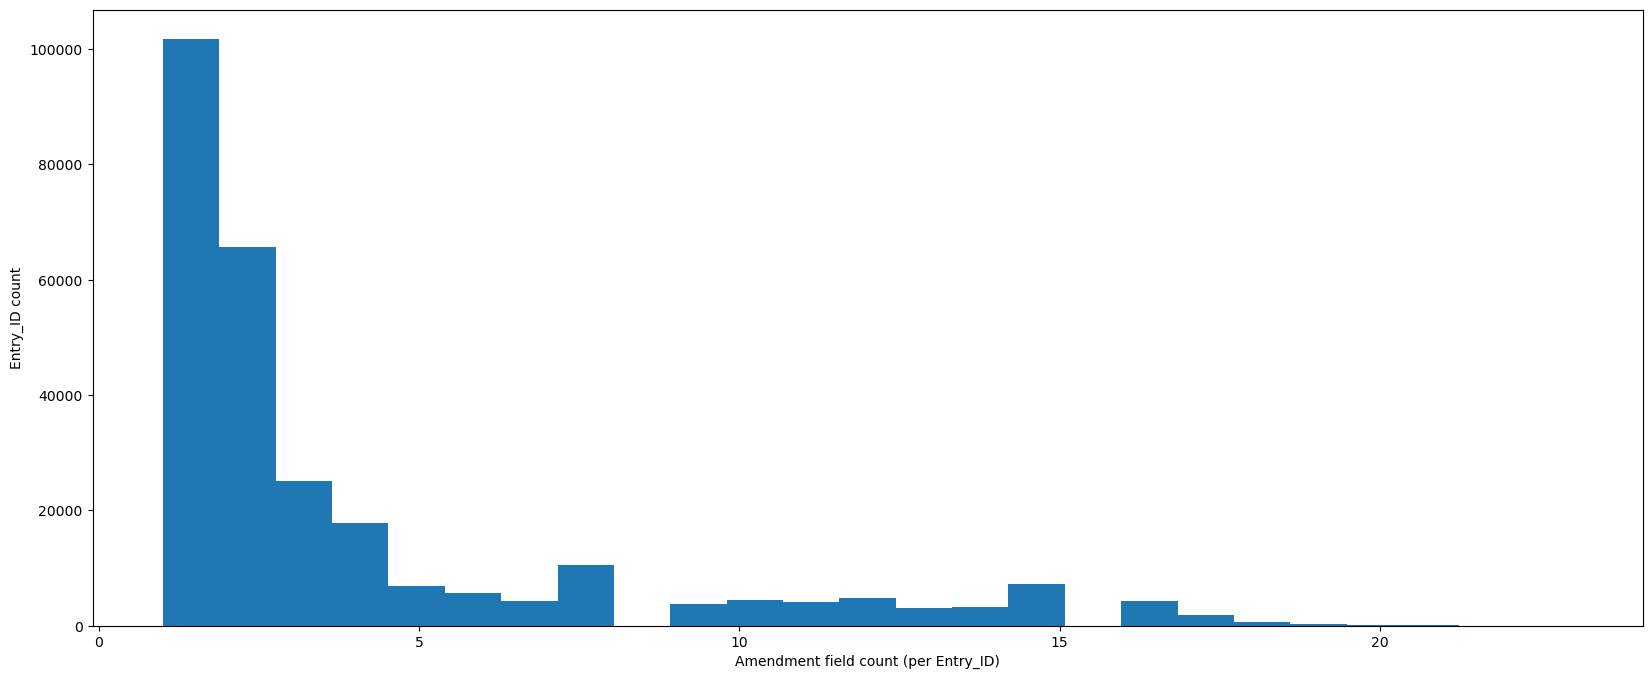

In [67]:
plt.figure(figsize=(20, 8))
plt.hist(df_EIDAf['Amended_field_count'], bins=25, log=False)
plt.xlabel("Amendment field count (per Entry_ID)")
plt.ylabel("Entry_ID count");

The Brokers with multifield-amended Entries:

In [69]:
df_EIDAf = df_EIDAf.reset_index().merge(df_ba.drop_duplicates('Entry_ID')[['Entry_ID', 'Broker']], how="inner", on='Entry_ID')
df_EIDAf.query('Amended_field_count > 20').sort_values(by='Amended_field_count', ascending=False)

,Entry_ID,Amended_field_count,Broker
217536,AEPJH4YP4,23,SCHENKER AUSTRALIA PTY LTD
200011,AEN76CHYJ,22,CUSTOMS CLEARANCE WORLD PTY LTD
41402,AC7JXNLGR,21,GIBSON FREIGHT (AUSTRALIA) PTY LIMITED
266735,AEYF9YKP7,21,BLUE WATER SHIPPING PTY LTD
262927,AEXXKPX3S,21,ROHLIG AUSTRALIA PTY LTD
246284,AEWFGEWT3,21,SADLEIRS TRANSPORT CO (W.A.) PTY LTD
242239,AEW37FMH9,21,MAINFREIGHT AIR & OCEAN PTY LTD
241928,AETYKC9RK,21,CARGOX PTY LTD
225531,AERATCH33,21,HENNING HARDERS (AUSTRALIA) PTY LTD
225530,AERATC7WF,21,HENNING HARDERS (AUSTRALIA) PTY LTD


As expected, the Brokers with a large volume of amended EntryIDs are also the common Brokers with the multifield amended EntryIDs:

In [70]:
multifield_amended = df_EIDAf.loc[df_EIDAf['Amended_field_count'] > 5, 'Broker']
multifield_amended.value_counts(ascending=False).to_frame().head(15)

,Broker
DHL GLOBAL FORWARDING (AUSTRALIA) PTY LTD,6857
GEODIS AUSTRALIA PTY LTD,5018
KUEHNE & NAGEL PTY LTD,2210
TOLL GLOBAL FORWARDING PTY LIMITED,1710
DSV AIR & SEA PTY LTD,1681
MAINFREIGHT AIR & OCEAN PTY LTD,1442
COMPLIANT CUSTOMS PTY LIMITED,1368
SCHENKER AUSTRALIA PTY LTD,1309
Kerry Logistics Oceania Pty Ltd,1270
ROHLIG AUSTRALIA PTY LTD,1210


An interesting insight is obtained by looking at the maximum number of days between the last and first amendment for each Entry_ID:

In [71]:
df_ba.groupby('Entry_ID')['Amendment_date'].agg(lambda x: (x.max() - x.min()).days).sort_values(ascending=False).to_frame().\
rename(columns={"Amendment_date": 'Max_days_between_amends'})

,Max_days_between_amends
Entry_ID,
AC6Y4HEEN,1939
AC6Y6JWCP,1902
AC6YENEPM,1897
AC7RP3GMG,1890
AC63EEY6J,1885
...,...
AEC6AK39X,0
AEC6AKRW3,0
AEC6AKY3X,0


Hence, 5-6 years between amendments is not entirely unusual.

We can also look at the relationship between the Entry_ID amendment count and this amendment day span:

In [72]:
df_AcDr = df_ba.groupby('Entry_ID', as_index=False)\
    .agg(Amendment_count=('Amendment_date', pd.Series.nunique), Max_days_between_amends=('Amendment_date', lambda x: (x.max() - x.min()).days))\
    .sort_values(by=['Amendment_count', 'Max_days_between_amends'], ascending=False)

df_AcDr

,Entry_ID,Amendment_count,Max_days_between_amends
131474,AEFWME97G,14,965
39863,AC7GXLTM6,12,1254
112688,AEEKAP3YR,11,1418
44370,AC7NAKHJM,11,1328
15828,AC4MNRY6L,11,1207
...,...,...,...
275017,PE0023221,1,0
275018,PE0023223,1,0
275019,PE0023224,1,0
275020,PE0023243,1,0


Naively, one would believe that *"Amendment_count"* and *"Max_days_between_amends"* are highly correlated, but it doesn't appear so.
Very often it took years between only a couple of amendments.

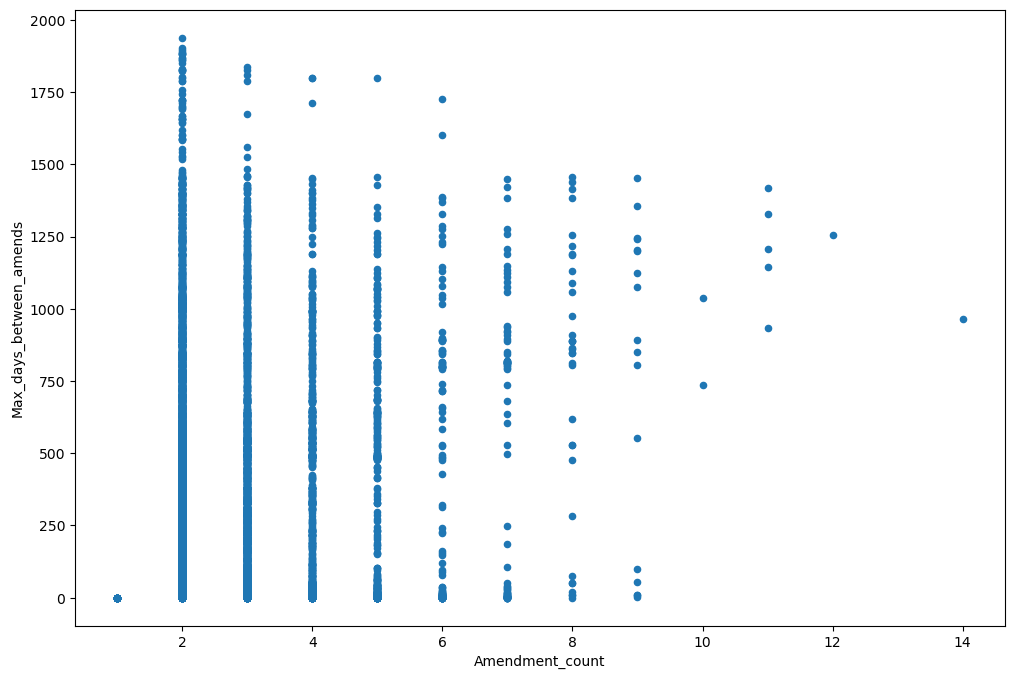

In [73]:
df_AcDr.plot(x='Amendment_count', y='Max_days_between_amends', kind="scatter", figsize=(12, 8));

## Import Inustry Advice Notices 01/01/2018-30/04/2024
### (scraped from https://www.agriculture.gov.au/biosecurity-trade/import/industry-advice)

Now we return to the question with regard to announcements about new countries of origin being subject to additional biosecurity measures.

The data has been exported as CSV file named All_years.csv.
We read it into a pandas dataframe and take a small random sample of rows to inpsect:

In [74]:
iian_df = pd.read_csv("C:/Users/AB0175/OneDrive - Agriculture/PYTHON/DAFF/X_BRANO/All_years.csv", parse_dates=['Date'])

iian_df['Date'] = pd.to_datetime(iian_df['Date'], format="%d %B %Y")
with pd.option_context('display.max_rows', None, 'max_colwidth', 500):
    display(iian_df.sample(10))

,Date,Number,Description,full_text
590,2022-02-24,28‑2022,Decommissioning AQIS Commodity Codes (ACC) on seventeen plant pathways to improve the Compliance-Based Intervention Scheme (CBIS) lodgement experience,"28-2022: Decommissioning AQIS Commodity Codes (ACC) on seventeen plant pathways to improve the Compliance-Based Intervention Scheme (CBIS) lodgement experience. - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change..."
85,2023-11-30,255-2023,Offshore Brown Marmorated Stink Bug (BMSB) Treatment Providers Scheme: treatment provider suspended – National Fumigation (Charleston) (AEI: US4024SB),"255-2023: Offshore Brown Marmorated Stink Bug (BMSB) Treatment Providers Scheme: treatment provider suspended – National Fumigation (Charleston) (AEI: US4024SB) - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change..."
680,2021-09-01,189-2021,Unplanned Outage: Wednesday 1 September 2021 - DAWE Network,"189-2021: Unplanned Outage: Wednesday 1 September 2021 - DAWE Network - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought Fisheries Forestry Plant health Drought, disaste..."
443,2022-09-23,177-2022,Unplanned Service Disruption: Friday 23 September 2022 – Biosecurity Portal,"177-2022: Unplanned Service Disruption: Friday 23 September 2022 – Biosecurity Portal - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought Fisheries Forestry Plant health ..."
668,2021-09-20,201-2021,"Scheduled Outage: Thursday 23 September to Friday 24 September 2021 – COLS, MARS, OPS, PEBS","201-2021: Scheduled Outage: Thursday 23 September to Friday 24 September 2021 – COLS, MARS, OPS, PEBS - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought Fisheries Forest..."
796,2021-04-21,73-2021,"Scheduled Outage: Saturday 24 to Sunday 25 April 2021 – COLS, MARS, OPS, PEBS, Treatment Certificate Portal","73-2021: Scheduled Outage: Saturday 24 to Sunday 25 April 2021 – COLS, MARS, OPS, PEBS, Treatment Certificate Portal - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought F..."
971,2020-08-31,135-2020,eCert exchange for New Zealand now paperless,"135-2020 - eCert exchange for New Zealand now paperless - DAFF Skip to main content Skip to main nav

The majority of these are rather irrelevant (namely those related to service disruption, outages, restoration etc).
The rest of the Notices are often too specific (e.g., concerning specific goods, such as uncooked prawns, and/or minor trading partners,
such as import of salmonid products from Estonia/Lithuania) and would not make a statistically significant change in overall Broker/Importer amendment activity.
Finally, there is a smaller group of Notices which could cause a statistically significant change. For example, the following records concern our biggest trading partner, the PRC:

In [75]:
with pd.option_context('display.max_rows', None, 'max_colwidth', 500):
    display(iian_df.query('Description.str.contains("China")'))

,Date,Number,Description,full_text
277,2023-03-17,63-2023,Update: Increased intervention on imported bulk mined and chemical fertilisers from the People’s Republic of China,"63-2023: Update: Increased intervention on imported bulk mined and chemical fertilisers from the People’s Republic of China - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and dr..."
306,2023-02-17,34-2023,Increased intervention on imported bulk mined and chemical fertilisers from the People’s Republic of China,"34-2023: Increased intervention on imported bulk mined and chemical fertilisers from the People’s Republic of China - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought Fi..."
335,2023-01-11,05‑2023,Cessation to Temporary Brown Marmorated Stink bug (BMSB) measures for Roll-on Roll-off (RoRo) vessels from China,"05-2023: Cessation to Temporary Brown Marmorated Stink bug (BMSB) measures for Roll-on Roll-off (RoRo) vessels from China - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drou..."
404,2022-11-02,216-2022,Management of vessels during the Brown Marmorated Stink Bug (BMSB) risk season: Temporary measures for Roll-on Roll-off (RoRo) vessels from China,"216-2022: Management of vessels during the Brown Marmorated Stink Bug (BMSB) risk season: Temporary measures for Roll-on Roll-off (RoRo) vessels from China - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and ..."
598,2022-02-14,20‑2022,Addition of China to the BMSB Emerging Risk Country List,"20-2022: Addition of China to the BMSB Emerging Risk Country List - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate change and agriculture Farming, food and drought Fisheries Forestry Plant health Drought, disaster an..."
1069,2020-03-06,36-2020,"Maritime Arrivals Reporting System (MARS) Pre-Arrival Report (PAR) Offline Forms Updated to include mainland China, Iran, the Republic of Korea and Italy","36-2020 - Maritime Arrivals Reporting System (MARS) Pre-Arrival Report (PAR) Offline Forms Updated to include mainland China, Iran, the Republic of Korea and Italy - DAFF Skip to main content Skip to main navigation Skip to search Top navigation main News & media Jobs Minister Contact us Search keyword Search Main menu AWE Main Agriculture and land Toggle menu Agriculture and land Building stronger and more sustainable agriculture, fisheries, forestry and land care. Animal health Climate cha..."
1335,2018-12-17,190-2018,Additions to the Compliance-based inspection scheme: peas from China and mandarins from Israel

Let's explore the effect of the Notice Nr. 20-2022.

#### Gauging the response to the addition of China to BMSB emerging risk on the 2022-02-14 and hypothesis testing:

Overall 9.39% of the CountryCode updates involves changing "CN" to something else:

In [76]:
round((df_ba.query('Reduced_amended_field.str.contains("Country")')['Before_amendment'] =="CN").mean() * 100, 2)

9.39

Looking at the Entry_ID updates in the year before and after the policy announcement, there were about a million in each year. Out of these ~million only about +30k involved the CountryCode change:

In [77]:
df_ba.query('"2021-02-14"< Amendment_date <= "2022-02-14"').query('Reduced_amended_field.str.contains("CountryCode")').shape[0], \
df_ba.query('"2023-02-14" > Amendment_date > "2022-02-14"').query('Reduced_amended_field.str.contains("CountryCode")').shape[0]

(31351, 38911)

As a percentage, 9.94% and 9.87%, respectively, changed the "CN" CountryCode to something else in the year before/after the announcement:

In [78]:
round((df_ba.query('"2021-02-14"< Amendment_date <= "2022-02-14"').query('Reduced_amended_field.str.contains("CountryCode")')['Before_amendment'] =="CN").mean() * 100, 2),\
round((df_ba.query('"2023-02-14" > Amendment_date > "2022-02-14"').query('Reduced_amended_field.str.contains("CountryCode")')['Before_amendment'] =="CN").mean() * 100, 2)

(9.94, 9.87)

Both percentages are slightly elevated compared to the overall 9.39% average across all years, but very close to each other, thus suggesting no statistical difference.

However, we can restrict the the time range closer to the notice date, e.g. the *quarter* before and after the announcement.
This produces two subsets of 8-10k "CN" CountryCode changes:

In [79]:
before_quarter = df_ba.query('"2021-11-14"< Amendment_date <= "2022-02-14"').query('Reduced_amended_field.str.contains("Country")')['Before_amendment'] =="CN"
after_quarter = df_ba.query('"2022-05-14" > Amendment_date > "2022-02-14"').query('Reduced_amended_field.str.contains("Country")')['Before_amendment'] =="CN"
len(before_quarter), len(after_quarter)

(8021, 10892)

Interestingly, the associated percentages substantially deviate from the overall 9.39%.
In fact, in the quarter *BEFORE* the annoucement the percantage was unusually high at 12.69%, followed by a drop to 8.52% *AFTER* the annoncement: 

In [80]:
round((df_ba.query('"2021-11-14"< Amendment_date <= "2022-02-14"').query('Reduced_amended_field.str.contains("Country")')['Before_amendment'] =="CN").mean() * 100, 2),\
round((df_ba.query('"2022-05-14" > Amendment_date > "2022-02-14"').query('Reduced_amended_field.str.contains("Country")')['Before_amendment'] =="CN").mean() * 100, 2)

(12.69, 8.52)

Comparing the two populations via the statistics two-sample T-test:

In [81]:
pg.ttest(before_quarter, after_quarter, correction=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,9.109177,15431.154576,two-sided,9.301527e-20,"[0.03, 0.05]",0.137618,1.529e+16,1.0


The p-value of $9.3\times10^{-20}$ suggests that the differences could not have possibly occured by a chance.

Hence, it may appear that a group of Brokers/Importers was aware of the impending change to the BMSB risk rating of "CN" and rushed to change the documents.

The Cohen-D value, which shows that the two populations’ means differ by only 0.138 standard deviations, suggests a rather small effect, though.
In other words the two distributions are very broad, which makes the difference between their means somewhat insignificant.

Even more interesting is that the 6-month periods before and after the quarters surrounding the Policy announcement the update percentages exhibit almost reverse values
(this can be expected, though, since they have to revert to the mean of the given year).

The respective sample sizes are now bigger, ~15k:

In [82]:
before_quarter_9_3 = df_ba.query('"2021-05-14"< Amendment_date < "2021-11-14"').query('Reduced_amended_field.str.contains("CountryCode")')['Before_amendment'] =="CN"
after_quarter_3_9 = df_ba.query('"2022-11-14" > Amendment_date > "2022-05-14"').query('Reduced_amended_field.str.contains("CountryCode")')['Before_amendment'] =="CN"

before_quarter_9_3.shape[0],\
after_quarter_3_9.shape[0]

(15199, 14582)

The percentages 9-3 months before and 3-9 months after the announcement:

In [83]:
round(before_quarter_9_3.mean() * 100, 2),\
round(after_quarter_3_9.mean() * 100, 2)

(8.68, 11.64)

Again, the two-sample T-test:

In [84]:
pg.ttest(before_quarter_9_3, after_quarter_3_9, correction=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-8.429617,28940.17103,two-sided,3.626760e-17,"[-0.04, -0.02]",0.097977,3.316e+13,1.0


Hence, despite the p-value of $3.6\times10^{-17}$, which strongly suggests that this difference could not occur randomly, given the Cohen-D value of ~0.1 the effect size appears minimal.